# Binarization with WiSARD and MNIST

## What is MNIST?

**MNIST** (Modified National Institute of Standards and Technology) is the "hello world" of machine learning. It's a dataset of **70,000 handwritten digits** (0-9) collected from census workers and high school students in the US in the late 1980s.

Each sample is:
- A **28x28 pixel grayscale image** (= 784 pixels total)
- Each pixel is an integer from **0** (black/background) to **255** (white/ink)
- Labeled with the **digit it represents** (0-9)

The dataset comes **pre-split**:
- **60,000 training samples** — what the model learns from
- **10,000 test samples** — what we evaluate the model on (never seen during training)

This pre-split is a convention so that everyone benchmarking on MNIST uses the same split, making results comparable.

We'll load it via `scikit-learn`, which downloads it from OpenML (a public ML dataset repository).

## Why binarization matters for WiSARD

WiSARD operates on **binary inputs only**. MNIST pixels are integers 0-255, so we need to convert them. This is where **binarization** comes in — different techniques produce different binary representations, which directly affect model performance.

## Setup

In [1]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import pickle, tarfile, urllib.request, os, warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import wisardpkg as wp

print(f"wisardpkg version: {wp.__version__}")

wisardpkg version: 2.0.0a7


In [7]:
# === Utility Functions ===

def binarize_dataset(X, thermometer):
    """Binarize each sample using the given thermometer encoder."""
    result = []
    for i in range(len(X)):
        binary = thermometer.transform(X[i].tolist())
        result.append(binary.list())
    return result

def create_and_fit_thermometer(thermo_type, thermo_size, X_train, address_size=None, y_train=None, validation_size=0.2):
    """Create and fit a thermometer.
    Supervised methods need y_train. Stochastic additionally needs address_size."""
    if thermo_type == 'Linear':
        n_feat = X_train.shape[1]
        per_min = X_train.min(axis=0)
        per_max = X_train.max(axis=0)
        steps = (per_max - per_min) / (thermo_size + 1)
        adj_mins = (per_min + steps).tolist()
        adj_maxs = per_max.tolist()
        return wp.DynamicThermometer([thermo_size] * n_feat, adj_mins, adj_maxs)
    elif thermo_type == 'Gaussian':
        t = wp.GaussianThermometer(thermo_size)
        t.fit(X_train.tolist())
        return t
    elif thermo_type == 'Exponential':
        t = wp.ExponentialThermometer(thermo_size)
        t.fit(X_train.tolist())
        return t
    elif thermo_type == 'Distributive':
        t = wp.DistributiveThermometer(thermo_size)
        t.fit(X_train.tolist())
        return t
    elif thermo_type == 'ClassConditional':
        t = wp.SupervisedThermometer(thermo_size, 'class_conditional')
        t.fit(X_train.tolist(), y_train.tolist())
        return t
    elif thermo_type == 'MIAllocation':
        t = wp.SupervisedThermometer(thermo_size, 'mi_allocation')
        t.fit(X_train.tolist(), y_train.tolist())
        return t
    elif thermo_type == 'EntropyWeighted':
        t = wp.SupervisedThermometer(thermo_size, 'entropy_weighted')
        t.fit(X_train.tolist(), y_train.tolist())
        return t
    elif thermo_type == 'Stochastic':
        t = wp.StochasticThermometer(thermo_size)
        t.fit(X_train.tolist())
        t.optimize(X_train.tolist(), y_train.tolist(),
                   addressSize=address_size,
                   validationSize=validation_size,
                   rounds=STOCHASTIC_ROUNDS,
                   stepsPerThreshold=STOCHASTIC_STEPS_PER_THRESHOLD,
                   numThreads=STOCHASTIC_NUM_THREADS,
                   maxShiftRatio=STOCHASTIC_MAX_SHIFT_RATIO,
                   earlyStopWindow=STOCHASTIC_EARLY_STOP_WINDOW)
        return t

def _load_pickle(path):
    """Load pickle suppressing NumPy 2.4 VisibleDeprecationWarning from old CIFAR format."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with open(path, 'rb') as f:
            return pickle.load(f, encoding='bytes')

def load_cifar10(data_dir):
    cifar_dir = os.path.join(data_dir, 'cifar-10-batches-py')
    if not os.path.exists(cifar_dir):
        print("  Downloading CIFAR-10...")
        url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
        path = os.path.join(data_dir, 'cifar-10-python.tar.gz')
        urllib.request.urlretrieve(url, path)
        with tarfile.open(path, 'r:gz') as tar:
            tar.extractall(data_dir, filter='data')
        os.remove(path)
    X_list, y_list = [], []
    for i in range(1, 6):
        batch = _load_pickle(os.path.join(cifar_dir, f'data_batch_{i}'))
        X_list.append(batch[b'data']); y_list.extend(batch[b'labels'])
    batch = _load_pickle(os.path.join(cifar_dir, 'test_batch'))
    X_list.append(batch[b'data']); y_list.extend(batch[b'labels'])
    return np.concatenate(X_list).astype(float), np.array([str(v) for v in y_list])

def load_cifar100(data_dir):
    cifar_dir = os.path.join(data_dir, 'cifar-100-python')
    if not os.path.exists(cifar_dir):
        print("  Downloading CIFAR-100...")
        url = 'https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz'
        path = os.path.join(data_dir, 'cifar-100-python.tar.gz')
        urllib.request.urlretrieve(url, path)
        with tarfile.open(path, 'r:gz') as tar:
            tar.extractall(data_dir, filter='data')
        os.remove(path)
    train = _load_pickle(os.path.join(cifar_dir, 'train'))
    test = _load_pickle(os.path.join(cifar_dir, 'test'))
    X = np.concatenate([train[b'data'], test[b'data']]).astype(float)
    y = np.array([str(v) for v in train[b'fine_labels'] + test[b'fine_labels']])
    return X, y

def compute_accuracy(predictions, y_true):
    return sum(1 for p, t in zip(predictions, y_true) if p == t) / len(y_true)

# Section 17

from collections import Counter

# Ensemble address sizes: centered around the dataset's configured addressSize
# with spread from half to double
def get_ensemble_addresses(base_addr, n_models=5):
    """Generate n_models address sizes linearly spaced from base/2 to base*3/2."""
    min_addr = max(2, base_addr // 2)
    max_addr = min(64, base_addr)
    if n_models == 1:
        return [base_addr]
    step = (max_addr - min_addr) / (n_models - 1)
    return [int(min_addr + i * step) for i in range(n_models)]

def ensemble_classify(wisards, test_dataset):
    """Majority vote across multiple WiSARDs."""
    all_preds = [w.classify(test_dataset) for w in wisards]
    n_samples = len(all_preds[0])
    final = []
    for i in range(n_samples):
        votes = [preds[i] for preds in all_preds]
        final.append(Counter(votes).most_common(1)[0][0])
    return final

# Section 18

def compute_bit_mi(X_bin, y, target_class):
    """Compute MI between each input bit and a binary label (target_class vs rest)."""
    n_samples = len(y)
    n_bits = len(X_bin[0])
    binary_label = np.array([1 if label == target_class else 0 for label in y])
    p_class = binary_label.mean()
    p_not_class = 1.0 - p_class

    mi = np.zeros(n_bits)
    for j in range(n_bits):
        bit_vals = np.array([X_bin[i][j] for i in range(n_samples)])
        p_bit1 = bit_vals.mean()
        p_bit0 = 1.0 - p_bit1
        if p_bit0 == 0 or p_bit1 == 0:
            continue

        for bv in [0, 1]:
            for lv in [0, 1]:
                mask = (bit_vals == bv) & (binary_label == lv)
                p_joint = mask.mean()
                if p_joint == 0:
                    continue
                p_b = p_bit1 if bv == 1 else p_bit0
                p_l = p_class if lv == 1 else p_not_class
                mi[j] += p_joint * np.log2(p_joint / (p_b * p_l))
    return mi

def compute_supervised_mapping_v2(X_bin, y, address_size):
    """Round-robin MI distribution: each RAM gets an equal share of informative bits."""
    n_bits = len(X_bin[0])
    classes = sorted(set(y))

    mapping = {}
    for cls in classes:
        mi = compute_bit_mi(X_bin, y, cls)

        # Sort bit indices by MI descending
        sorted_bits = sorted(range(n_bits), key=lambda b: mi[b], reverse=True)

        # Determine number of RAMs
        n_rams = n_bits // address_size
        if n_bits % address_size != 0:
            n_rams += 1

        # Deal round-robin: bit 0 → RAM 0, bit 1 → RAM 1, ..., bit n_rams → RAM 0, ...
        ram_bits = [[] for _ in range(n_rams)]
        for i, bit_idx in enumerate(sorted_bits):
            ram_bits[i % n_rams].append(bit_idx)

        mapping[cls] = ram_bits

    return mapping

def boosted_wisard_train(X_bin, y, address_size, n_rounds=5):
    """Train a sequence of WiSARDs, each focusing on previous mistakes."""
    wisards = []
    current_X = list(X_bin)
    current_y = list(y)

    for round_num in range(n_rounds):
        ds = wp.DataSet(current_X, current_y)
        w = wp.Wisard(address_size)
        w.train(ds)
        wisards.append(w)

        if round_num < n_rounds - 1:
            # Find misclassified training samples
            preds = w.classify(ds)
            misclassified_X = []
            misclassified_y = []
            for i in range(len(current_X)):
                if preds[i] != current_y[i]:
                    misclassified_X.append(current_X[i])
                    misclassified_y.append(current_y[i])

            if len(misclassified_X) == 0:
                break  # Perfect on training data

            # Augment training data with misclassified samples
            current_X = list(X_bin) + misclassified_X
            current_y = list(y) + misclassified_y

    return wisards

def boosted_classify(wisards, test_dataset):
    """Weighted majority vote: later models get more weight."""
    all_preds = [w.classify(test_dataset) for w in wisards]
    n_samples = len(all_preds[0])
    final = []
    for i in range(n_samples):
        # Weight: model k gets weight k+1 (later = more focused = more weight)
        votes = {}
        for k, preds in enumerate(all_preds):
            weight = k + 1
            votes[preds[i]] = votes.get(preds[i], 0) + weight
        final.append(max(votes, key=votes.get))
    return final

In [3]:
# === Configuration ===
# Tweak these parameters and re-run the notebook to experiment.

# MNIST exploration (sections 1-10)
MNIST_ADDRESS_SIZE = 28
MNIST_THERMO_SIZE = 3       # for the binarization visualization
MNIST_THERMO_MIN = 64.0     # ranges(64, 256, 3) → thresholds [64, 128, 192]
MNIST_THERMO_MAX = 256.0


N_RUNS = 20
BASELINE_THERMO_TYPES = ['Linear', 'Gaussian', 'Exponential', 'Distributive']

SUPERVISED_THERMO_TYPES = ['Distributive', 'ClassConditional', 'MIAllocation', 'EntropyWeighted', 'Stochastic']
STOCHASTIC_ROUNDS = 2
STOCHASTIC_STEPS_PER_THRESHOLD = 8   # N/2 left, N/2 right
STOCHASTIC_NUM_THREADS = 0            # 0 = auto-detect CPU cores
STOCHASTIC_MAX_SHIFT_RATIO = 0.2      # search range: 0.2 = up to 20% of gap each direction
STOCHASTIC_EARLY_STOP_WINDOW = 5      # skip right scan if first N left candidates don't improve (0 = disabled)

ALL_THERMO_TYPES = [
    'Linear', 
    'Gaussian', 
    'Exponential', 
    'Distributive', 
    'ClassConditional', 
    'MIAllocation', 
    'EntropyWeighted', 
    'Stochastic'
]

DATASET_CONFIG = {
    # (address_size, thermo_size, validation_size) per dataset
    "Glass":            (8,  32, 0.25),
    "Ecoli":            (10, 32, 0.25),
    "Vehicle":          (14, 32, 0.25),
    "Cardiotocography": (20, 32, 0.25),
    "SatImage":         (24, 32, 0.25),
    "EEG Eye State":    (28, 32, 0.25),
    "Magic Gamma":      (28, 32, 0.25),
    # "Fashion MNIST":    (28, 8,  0.25),
    # "MNIST":            (28, 8,  0.25),
    # "CIFAR-10":       (28, 4,  0.2),
    # "CIFAR-100":      (28, 4,  0.2),
}

In [4]:
# === Load all datasets ===
datasets = {}

openml_datasets = [
    ("Glass",           41),
    ("Ecoli",           39),
    ("Vehicle",         54),
    ("Cardiotocography", 1466),
    ("SatImage",        182),
    ("EEG Eye State",   1471),
    ("Magic Gamma",     1120),
    # ("Fashion MNIST",   40996),
    # ("MNIST",           554),
]

for name, did in openml_datasets:
    try:
        d = fetch_openml(data_id=did, as_frame=False, parser='auto')
        X_d, y_d = d.data.astype(float), d.target.astype(str)
        datasets[name] = (X_d, y_d)
        print(f"  {name:20s}: {X_d.shape[0]:6d} samples, {X_d.shape[1]:4d} features, {len(set(y_d)):3d} classes")
    except Exception as e:
        print(f"  {name:20s}: FAILED - {str(e)[:60]}")

# CIFAR (direct download)
# data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
# os.makedirs(data_dir, exist_ok=True)

# for name, loader in [("CIFAR-10", load_cifar10), ("CIFAR-100", load_cifar100)]:
#     try:
#         X_d, y_d = loader(data_dir)
#         datasets[name] = (X_d, y_d)
#         print(f"  {name:20s}: {X_d.shape[0]:6d} samples, {X_d.shape[1]:4d} features, {len(set(y_d)):3d} classes")
#     except Exception as e:
#         print(f"  {name:20s}: SKIPPED - {str(e)[:60]}")

print(f"\nLoaded {len(datasets)} datasets")

  Glass               :    214 samples,    9 features,   6 classes
  Ecoli               :    336 samples,    7 features,   8 classes
  Vehicle             :    846 samples,   18 features,   4 classes
  Cardiotocography    :   2126 samples,   35 features,  10 classes
  SatImage            :   6430 samples,   36 features,   6 classes
  EEG Eye State       :  14980 samples,   14 features,   2 classes
  Magic Gamma         :  19020 samples,   10 features,   2 classes

Loaded 7 datasets


---
## Data

## 1. Loading MNIST

`fetch_openml` downloads the dataset from the internet the first time (cached afterwards). The result has:
- `data`: a DataFrame/array with 70,000 rows x 784 columns (each row = one flattened 28x28 image)
- `target`: the digit label for each row ("0" through "9")

In [18]:
# Load MNIST — this downloads ~50MB the first time, then it's cached
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data    # shape: (70000, 784) — pixel values 0-255
y = mnist.target  # shape: (70000,)     — digit labels as strings

print(f"Full dataset shape: {X.shape}")
print(f"Labels shape:       {y.shape}")
print(f"Pixel value range:  {X.min()} to {X.max()}")
print(f"Unique labels:      {sorted(set(y))}")
print(f"Label type:         {type(y[0])}")

Full dataset shape: (70000, 784)
Labels shape:       (70000,)
Pixel value range:  0 to 255
Unique labels:      ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Label type:         <class 'str'>


## 2. What does the data actually look like?

Each sample is a flat array of 784 numbers. We can reshape it back to 28x28 to see the image. Let's look at a few samples and also at the raw pixel values.

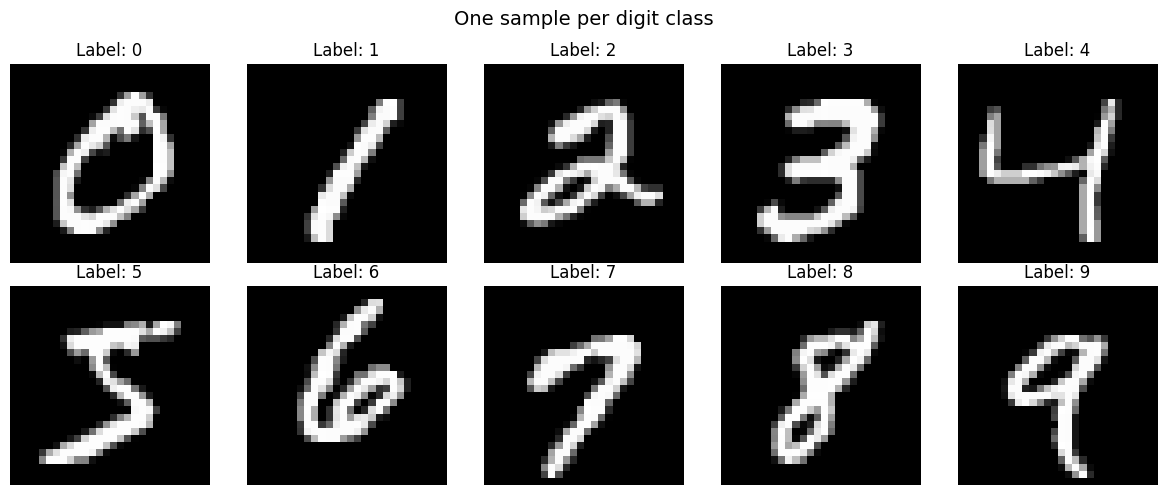

In [19]:
# Show 10 random samples — one of each digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y == str(digit))[0][0]  # first occurrence of this digit
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[idx]}")
    ax.axis('off')
plt.suptitle("One sample per digit class", fontsize=14)
plt.tight_layout()
plt.show()

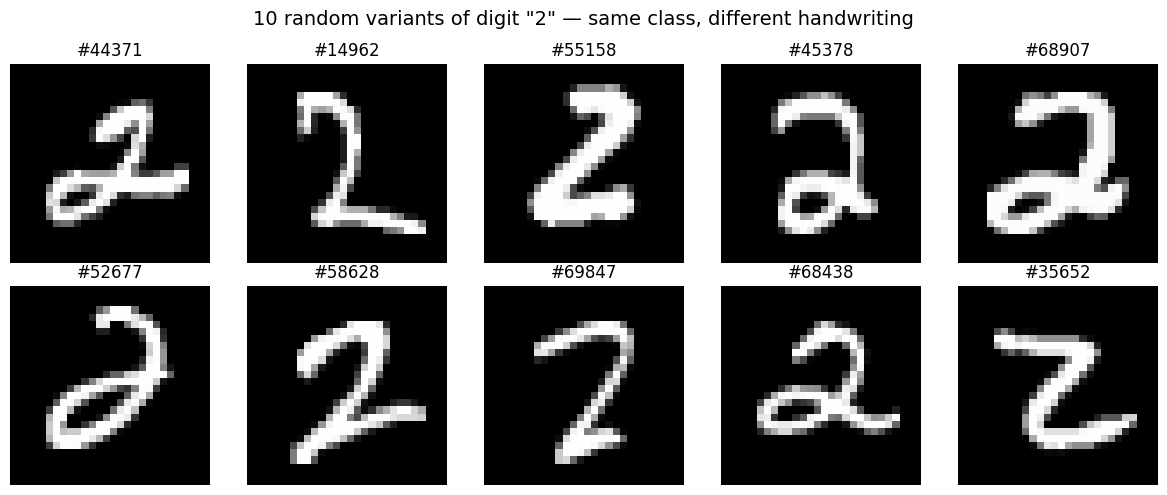

In [20]:
# Show 10 random variants of the same digit — highlights within-class variation
digit_to_show = str(np.random.randint(0, 10))
digit_indices = np.where(y == digit_to_show)[0]
chosen = np.random.choice(digit_indices, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[chosen[i]].reshape(28, 28), cmap='gray')
    ax.set_title(f"#{chosen[i]}")
    ax.axis('off')
plt.suptitle(f'10 random variants of digit "{digit_to_show}" — same class, different handwriting', fontsize=14)
plt.tight_layout()
plt.show()

Sample index: 25664  |  Label: 9
Shape (flat): (784,)
Pixel value distribution:
  Zero pixels (background): 573 / 784 (73.1%)
  Non-zero pixels (ink):    211 / 784 (26.9%)
  Max intensity pixels:     0 / 784


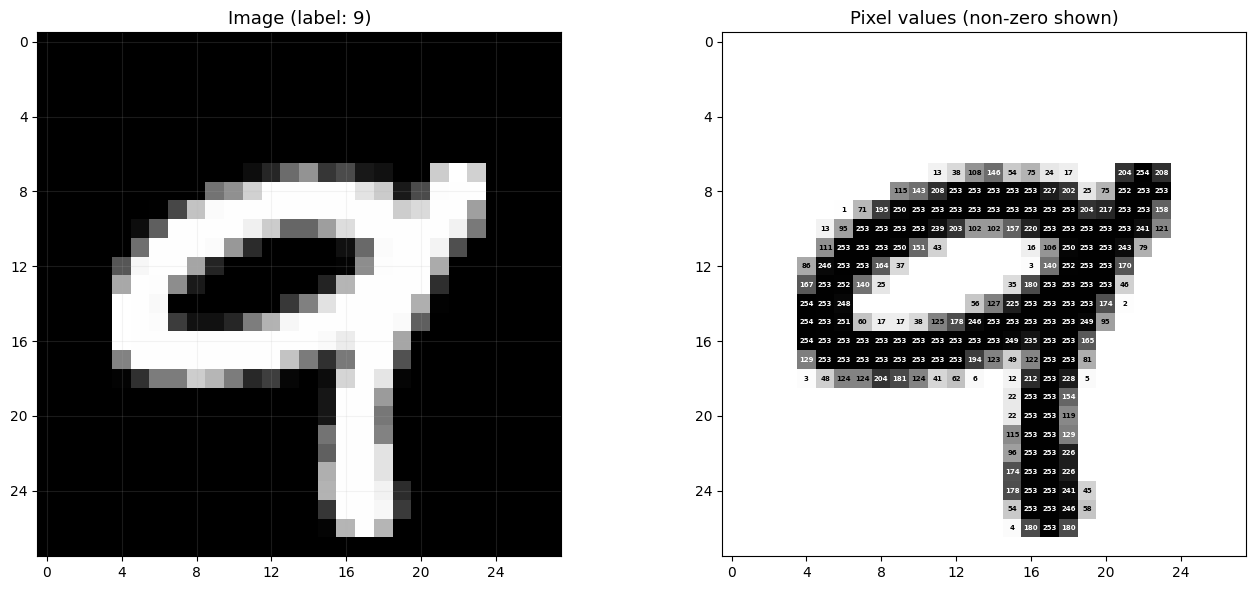

In [21]:
# Pick a random sample
rng = np.random.default_rng()
sample_idx = rng.integers(0, len(X))
sample = X[sample_idx]
sample_img = sample.reshape(28, 28).astype(int)

print(f"Sample index: {sample_idx}  |  Label: {y[sample_idx]}")
print(f"Shape (flat): {sample.shape}")
print(f"Pixel value distribution:")
print(f"  Zero pixels (background): {np.sum(sample == 0)} / 784 ({np.sum(sample == 0)/784*100:.1f}%)")
print(f"  Non-zero pixels (ink):    {np.sum(sample > 0)} / 784 ({np.sum(sample > 0)/784*100:.1f}%)")
print(f"  Max intensity pixels:     {np.sum(sample == 255)} / 784")

# Side by side: image + pixel values as annotated heatmap
fig, (ax_img, ax_vals) = plt.subplots(1, 2, figsize=(14, 6))

# Left: the actual image
ax_img.imshow(sample_img, cmap='gray')
ax_img.set_title(f"Image (label: {y[sample_idx]})", fontsize=13)
ax_img.set_xticks(range(0, 28, 4))
ax_img.set_yticks(range(0, 28, 4))
ax_img.grid(True, alpha=0.15)

# Right: heatmap with pixel values overlaid (only non-zero, to keep it readable)
ax_vals.imshow(sample_img, cmap='gray_r', vmin=0, vmax=255)
ax_vals.set_title("Pixel values (non-zero shown)", fontsize=13)
ax_vals.set_xticks(range(0, 28, 4))
ax_vals.set_yticks(range(0, 28, 4))
for row in range(28):
    for col in range(28):
        val = sample_img[row, col]
        if val > 0:
            color = 'white' if val > 128 else 'black'
            ax_vals.text(col, row, str(val), ha='center', va='center',
                        fontsize=5, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Train/Test Split

MNIST conventionally uses the first 60,000 samples for training and the last 10,000 for testing (roughly 86/14). We'll use `train_test_split` with the same proportion to keep results comparable with the literature, while still shuffling the data.

In [32]:
# Split: 60k training, 10k testing (same proportion as the standard MNIST split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10_000)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 60000 samples
Test set:     10000 samples


---
## Binarization

## 4. Binarization with SimpleThermometer

**SimpleThermometer** converts each pixel value into multiple binary bits by comparing against evenly-spaced thresholds. This preserves *magnitude* information that a simple threshold would lose.

**How thresholds are generated:** `SimpleThermometer(size, minimum, maximum)` generates `size` thresholds starting at `minimum` with step `(maximum - minimum) / size`. So to get thresholds at [64, 128, 192], we use `minimum=64, maximum=256` (step = 64).

The comparison is **strict `>`**: a pixel is 1 for a threshold only if its value is strictly greater than that threshold.

**Example** with `size=3`, `minimum=64`, `maximum=256` (thresholds: 64, 128, 192):
- Pixel = 200 → `[1, 1, 1]` (> 64, > 128, > 192)
- Pixel = 150 → `[1, 1, 0]` (> 64, > 128, not > 192)
- Pixel = 80 → `[1, 0, 0]` (> 64, not > 128)
- Pixel = 30 → `[0, 0, 0]` (not > 64)

This splits the 0-255 range into 4 regions:
| Region | Pixel range | Bits | Level |
|--------|-------------|------|-------|
| 0 | [0, 64] | [0, 0, 0] | 0 |
| 1 | (64, 128] | [1, 0, 0] | 1 |
| 2 | (128, 192] | [1, 1, 0] | 2 |
| 3 | (192, 255] | [1, 1, 1] | 3 |

Each pixel (1 value) becomes `size` bits, so a 784-pixel image becomes `784 * size` bits.

In [29]:
# Create a SimpleThermometer binarizer using config values
thermo = wp.SimpleThermometer(MNIST_THERMO_SIZE, minimum=MNIST_THERMO_MIN, maximum=MNIST_THERMO_MAX)

# Binarize the same sample shown in the pixel visualization above
sample_pixels = X[sample_idx].tolist()
sample_binary = thermo.transform(sample_pixels)

print(f"Sample index: {sample_idx}  |  Label: {y[sample_idx]}")
print(f"Original: {len(sample_pixels)} pixels (values 0-255)")
print(f"Binarized: {len(sample_binary)} bits (thermometer size={MNIST_THERMO_SIZE})")
print(f"Expansion factor: {len(sample_binary) / len(sample_pixels)}x")
print(f"Thresholds: [64, 128, 192]")

# Show a few non-zero pixels and their thermometer encoding
print(f"\nSample pixels and their thermometer encoding:")
shown = 0
for i in range(len(sample_pixels)):
    if shown >= 8:
        break
    pixel_val = int(sample_pixels[i])
    if pixel_val > 0:
        bits = [sample_binary[i * MNIST_THERMO_SIZE + j] for j in range(MNIST_THERMO_SIZE)]
        level = sum(bits)
        print(f"  Pixel {i:3d} (row {i//28:2d}, col {i%28:2d}): value={pixel_val:3d} -> bits={bits} (level {level})")
        shown += 1

Sample index: 25664  |  Label: 9
Original: 784 pixels (values 0-255)
Binarized: 2352 bits (thermometer size=3)
Expansion factor: 3.0x
Thresholds: [64, 128, 192]

Sample pixels and their thermometer encoding:
  Pixel 207 (row  7, col 11): value= 13 -> bits=[0, 0, 0] (level 0)
  Pixel 208 (row  7, col 12): value= 38 -> bits=[0, 0, 0] (level 0)
  Pixel 209 (row  7, col 13): value=108 -> bits=[1, 0, 0] (level 1)
  Pixel 210 (row  7, col 14): value=146 -> bits=[1, 1, 0] (level 2)
  Pixel 211 (row  7, col 15): value= 54 -> bits=[0, 0, 0] (level 0)
  Pixel 212 (row  7, col 16): value= 75 -> bits=[1, 0, 0] (level 1)
  Pixel 213 (row  7, col 17): value= 24 -> bits=[0, 0, 0] (level 0)
  Pixel 214 (row  7, col 18): value= 17 -> bits=[0, 0, 0] (level 0)


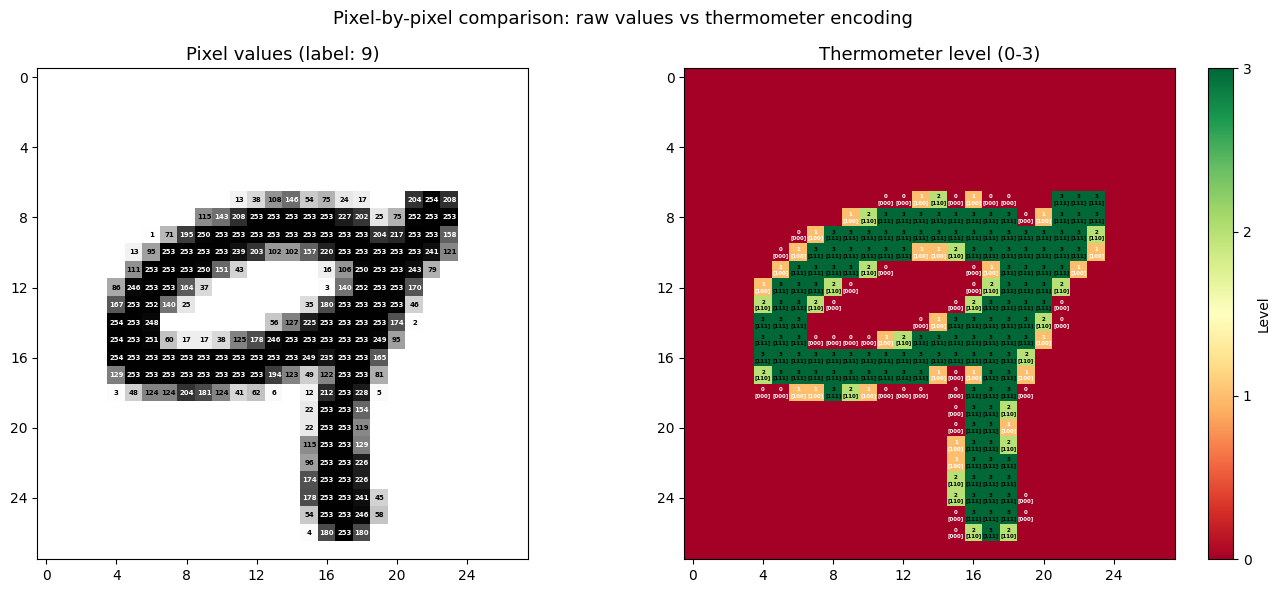

In [30]:
# Heatmap comparison: pixel values vs thermometer encoding level
sample_img = np.array(sample_pixels).reshape(28, 28).astype(int)
binary_list = sample_binary.list()
binary_array = np.array(binary_list).reshape(784, MNIST_THERMO_SIZE)
level_img = binary_array.sum(axis=1).reshape(28, 28)

fig, (ax_pix, ax_enc) = plt.subplots(1, 2, figsize=(14, 6))

ax_pix.imshow(sample_img, cmap='gray_r', vmin=0, vmax=255)
ax_pix.set_title(f"Pixel values (label: {y[sample_idx]})", fontsize=13)
ax_pix.set_xticks(range(0, 28, 4))
ax_pix.set_yticks(range(0, 28, 4))
for row in range(28):
    for col in range(28):
        val = sample_img[row, col]
        if val > 0:
            color = 'white' if val > 128 else 'black'
            ax_pix.text(col, row, str(val), ha='center', va='center',
                       fontsize=5, color=color, fontweight='bold')

im = ax_enc.imshow(level_img, cmap='RdYlGn', vmin=0, vmax=MNIST_THERMO_SIZE)
ax_enc.set_title(f"Thermometer level (0-{MNIST_THERMO_SIZE})", fontsize=13)
ax_enc.set_xticks(range(0, 28, 4))
ax_enc.set_yticks(range(0, 28, 4))
level_labels = {i: f"{i}\n[{'1'*i + '0'*(MNIST_THERMO_SIZE-i)}]" for i in range(MNIST_THERMO_SIZE+1)}
for row in range(28):
    for col in range(28):
        lvl = level_img[row, col]
        val = sample_img[row, col]
        if val > 0:
            color = 'white' if lvl <= MNIST_THERMO_SIZE // 2 else 'black'
            ax_enc.text(col, row, level_labels[lvl], ha='center', va='center',
                       fontsize=4, color=color, fontweight='bold')

plt.colorbar(im, ax=ax_enc, ticks=range(MNIST_THERMO_SIZE+1), label='Level')
plt.suptitle("Pixel-by-pixel comparison: raw values vs thermometer encoding", fontsize=13)
plt.tight_layout()
plt.show()

---
## MNIST Model (Train + Classify)

In [33]:
print(f"Binarizing {len(X_train)} training samples...")
t0 = time.time()
X_train_bin = binarize_dataset(X_train, thermo)
t1 = time.time()
print(f"  Done in {t1-t0:.1f}s")

print(f"Binarizing {len(X_test)} test samples...")
X_test_bin = binarize_dataset(X_test, thermo)
t2 = time.time()
print(f"  Done in {t2-t1:.1f}s")

print(f"\nBinary input size per sample: {len(X_train_bin[0])} bits")

Binarizing 60000 training samples...
  Done in 1.9s
Binarizing 10000 test samples...
  Done in 0.3s

Binary input size per sample: 2352 bits


In [34]:
wisard = wp.Wisard(MNIST_ADDRESS_SIZE, bleachingActivated=True)
train_ds = wp.DataSet(X_train_bin, y_train.tolist())

print(f"Training WiSARD (addressSize={MNIST_ADDRESS_SIZE})...")
t0 = time.time()
wisard.train(train_ds)
print(f"  Training time: {time.time()-t0:.2f}s")

Training WiSARD (addressSize=28)...
  Training time: 0.35s


In [35]:
test_ds = wp.DataSet(X_test_bin)

print(f"Classifying {len(X_test_bin)} test samples...")
t0 = time.time()
predictions = wisard.classify(test_ds)
print(f"  Classification time: {time.time()-t0:.2f}s")

accuracy = compute_accuracy(predictions, y_test)
print(f"\nAccuracy: {accuracy:.4f} ({int(accuracy*len(y_test))}/{len(y_test)})")

Classifying 10000 test samples...
  Classification time: 0.99s

Accuracy: 0.9409 (9409/10000)


---
## Analysis

## 8. Per-digit accuracy (Confusion Analysis)

Let's see which digits are easy vs hard for the model.

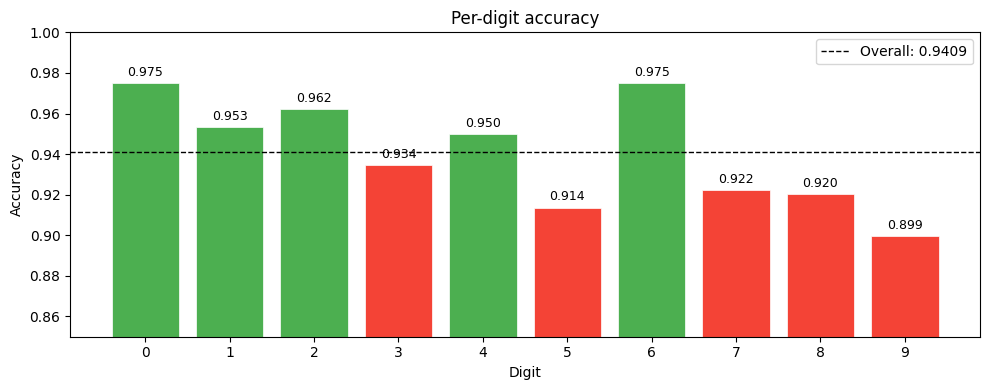

In [36]:
# Per-digit accuracy as a bar chart
digits = sorted(set(y_test))
digit_accs = []
for digit in digits:
    mask = y_test == digit
    digit_correct = sum(1 for p, t in zip(predictions, y_test) if t == digit and p == t)
    digit_accs.append(digit_correct / sum(mask))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#4CAF50' if a >= accuracy else '#F44336' for a in digit_accs]
bars = ax.bar(digits, digit_accs, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=accuracy, color='black', linestyle='--', linewidth=1, label=f'Overall: {accuracy:.4f}')
ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy')
ax.set_title('Per-digit accuracy')
ax.set_ylim(0.85, 1.0)
ax.legend()
for bar, acc in zip(bars, digit_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Misclassified samples

For each digit, let's find one sample the model got wrong and look at **why** — not just the image, but the raw classification scores across all 10 digit classes. This reveals whether it was a close call or a confident mistake.

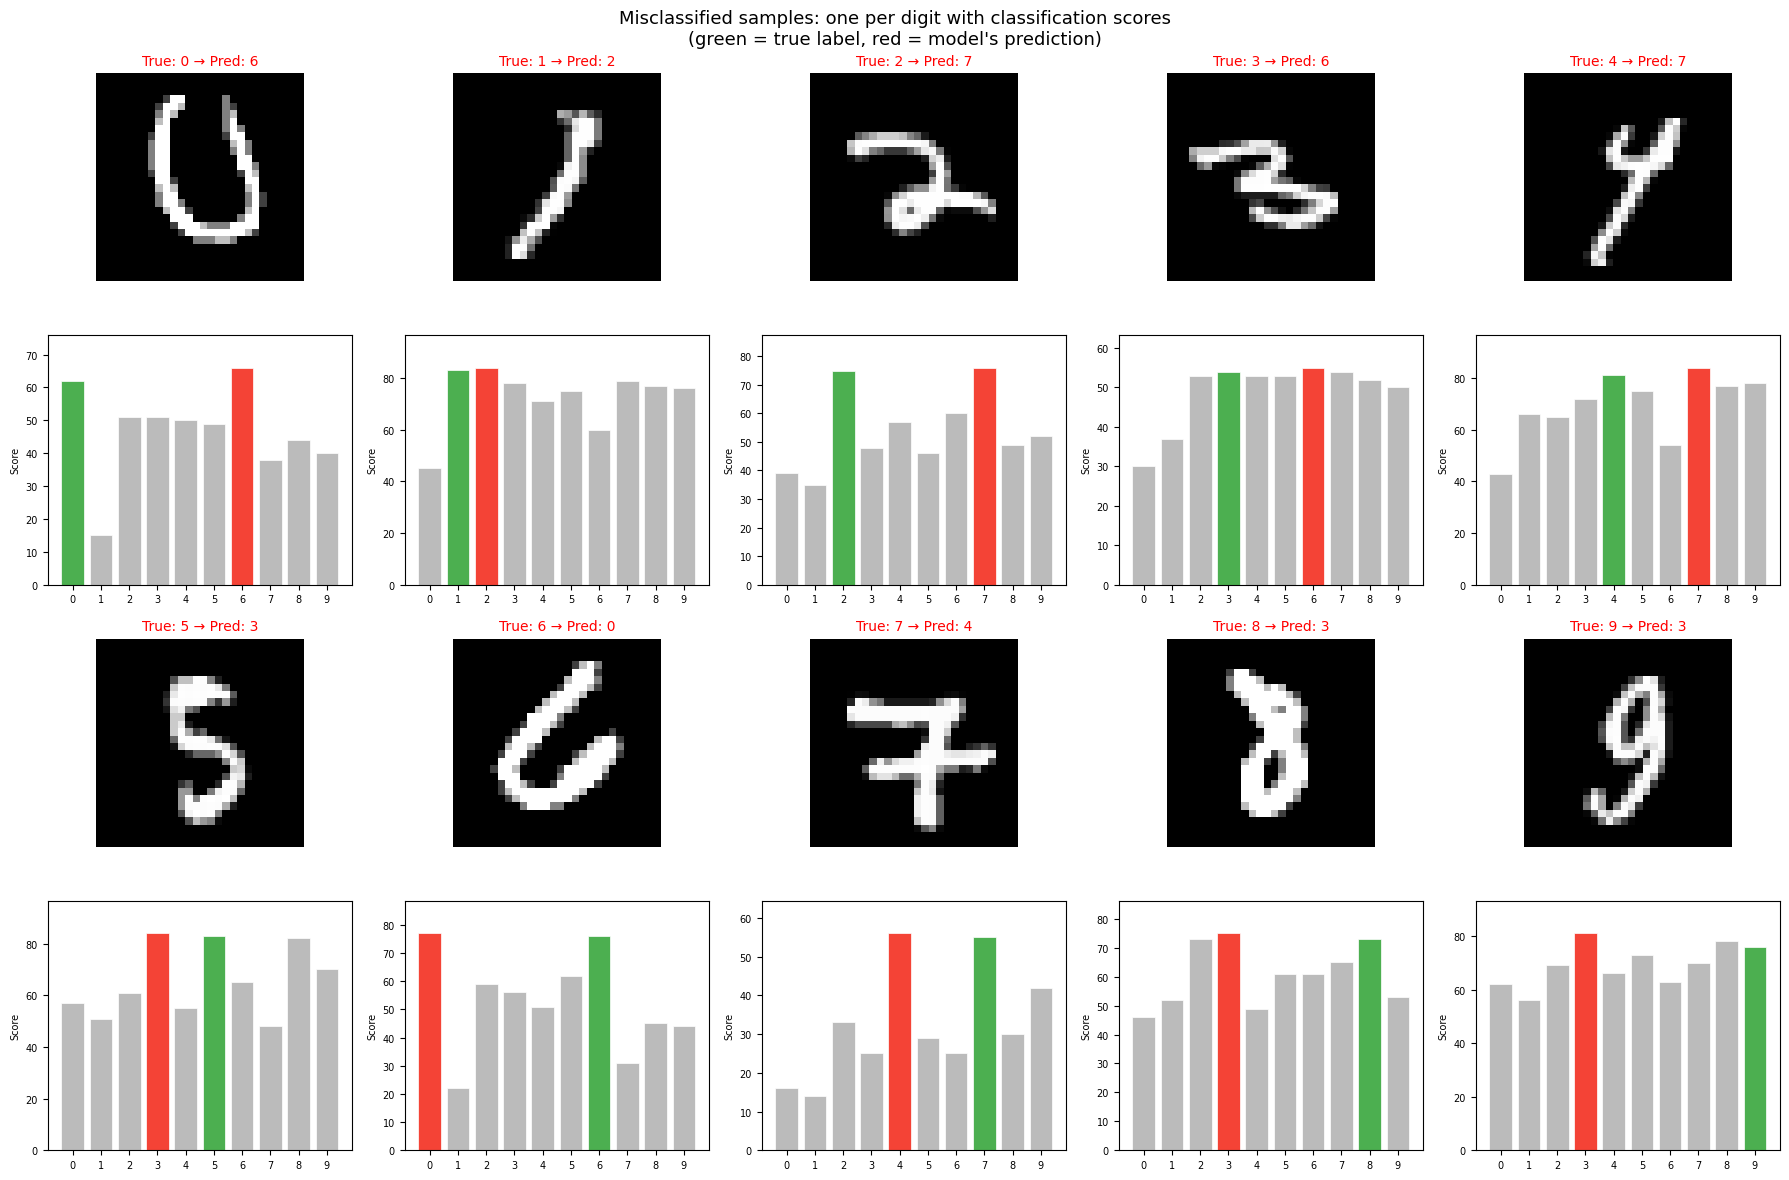

Total misclassified: 591 / 10000


In [37]:
# Find one misclassified sample per true digit
misclassified = {}
for i, (pred, true) in enumerate(zip(predictions, y_test)):
    if pred != true and true not in misclassified:
        misclassified[true] = i
    if len(misclassified) == 10:
        break

# Grid: 4 rows x 5 cols — [image, bar chart] pairs for digits 0-4 then 5-9
fig, axes = plt.subplots(4, 5, figsize=(18, 12),
                         gridspec_kw={'height_ratios': [1, 1.2, 1, 1.2]})

for pos, digit in enumerate(sorted(misclassified.keys())):
    idx = misclassified[digit]
    col = pos % 5
    row_img = 0 if pos < 5 else 2
    row_bar = row_img + 1

    ax_img = axes[row_img, col]
    ax_bar = axes[row_bar, col]

    # Image
    ax_img.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax_img.set_title(f"True: {y_test[idx]} → Pred: {predictions[idx]}", color='red', fontsize=10)
    ax_img.axis('off')

    # Rank scores (classification confidence per digit class)
    ranks = wisard.rank(wp.BinInput(X_test_bin[idx]))
    classes = sorted(ranks.keys())
    scores = [ranks[c] for c in classes]

    bar_colors = []
    for c in classes:
        if c == y_test[idx]:
            bar_colors.append('#4CAF50')   # green = true label
        elif c == predictions[idx]:
            bar_colors.append('#F44336')   # red = predicted (wrong)
        else:
            bar_colors.append('#BBBBBB')   # gray = others

    ax_bar.bar(classes, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax_bar.set_ylabel('Score', fontsize=7)
    ax_bar.tick_params(axis='both', labelsize=7)
    ax_bar.set_ylim(0, max(scores) * 1.15)

plt.suptitle("Misclassified samples: one per digit with classification scores\n"
             "(green = true label, red = model's prediction)", fontsize=13)
plt.tight_layout()
plt.show()

wrong_total = sum(1 for p, t in zip(predictions, y_test) if p != t)
print(f"Total misclassified: {wrong_total} / {len(y_test)}")

## 10. Correctly classified samples

Same analysis but for samples the model got right — one per digit. The bar charts show whether the model was confidently correct or if it was a close call between the true class and a runner-up.

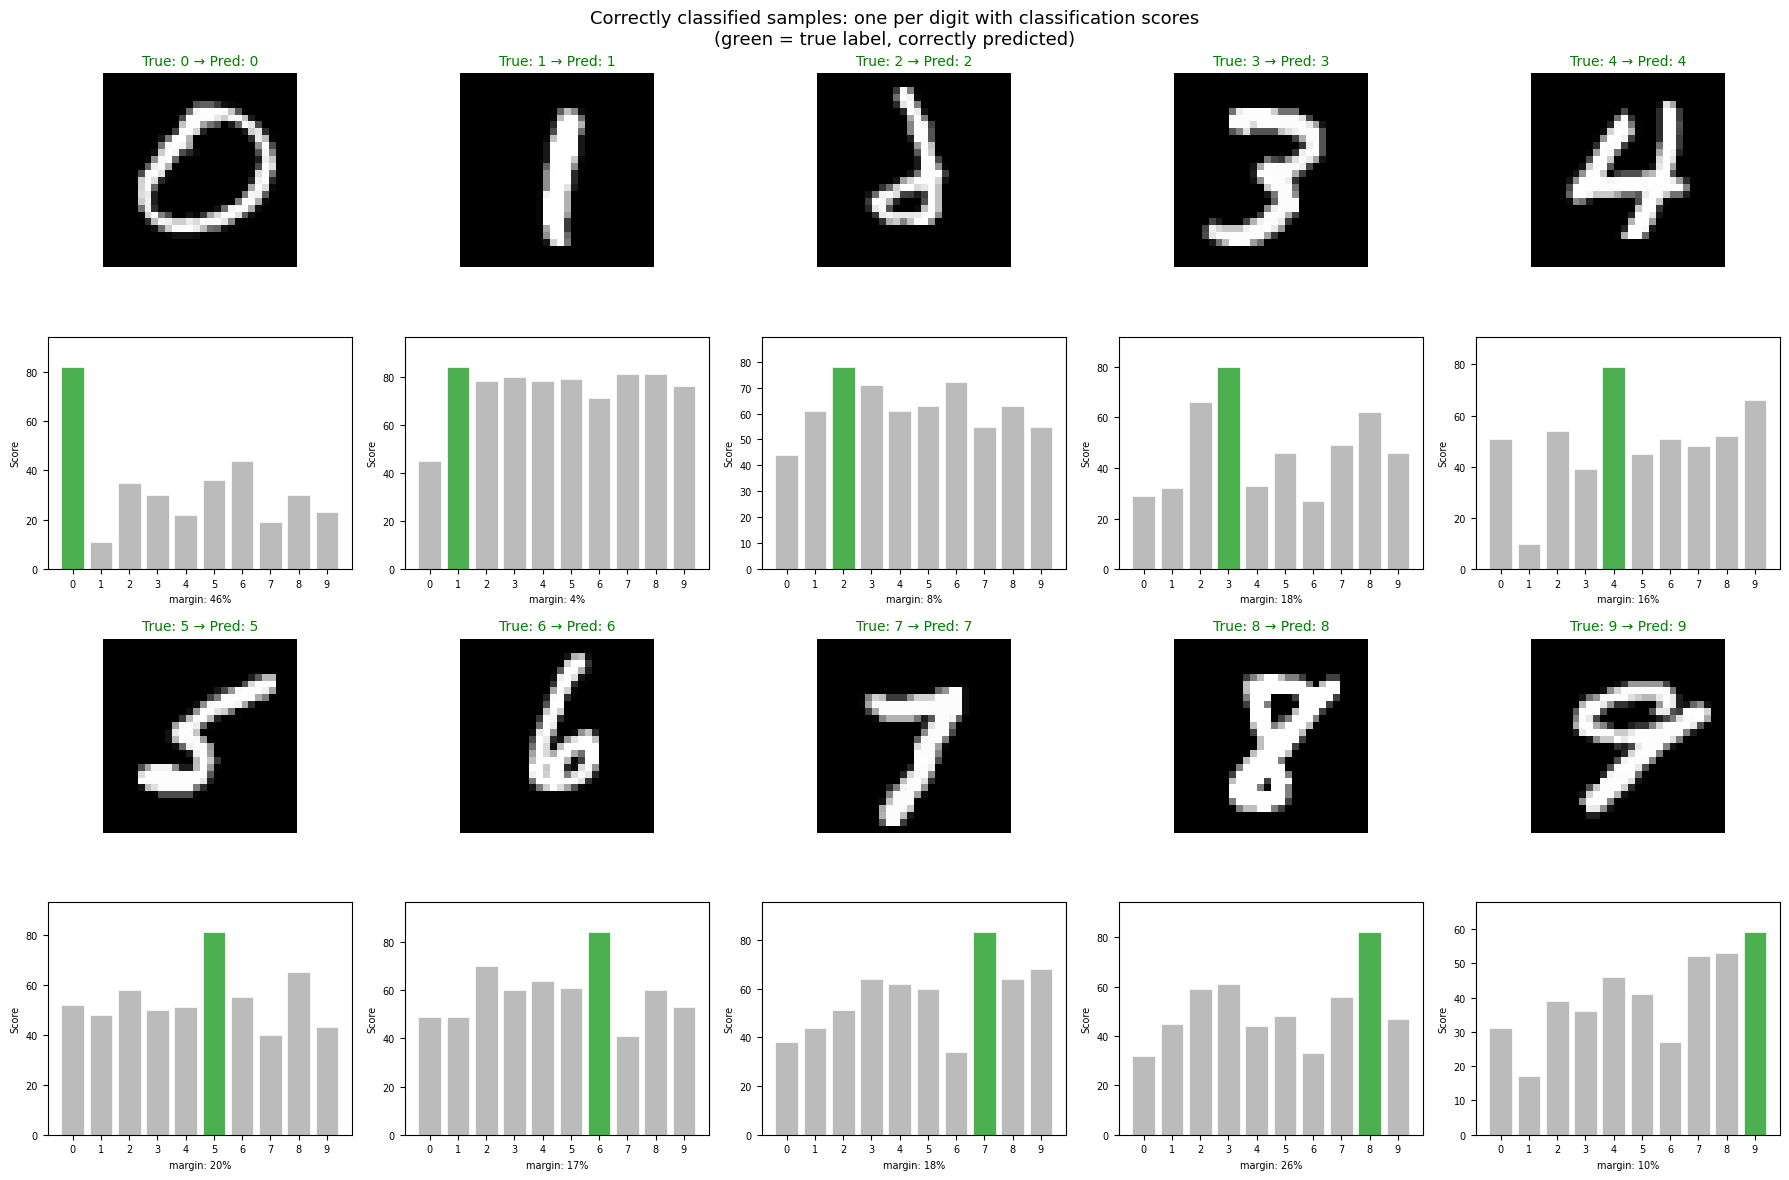

In [38]:
# Find one correctly classified sample per digit
correct_samples = {}
for i, (pred, true) in enumerate(zip(predictions, y_test)):
    if pred == true and true not in correct_samples:
        correct_samples[true] = i
    if len(correct_samples) == 10:
        break

fig, axes = plt.subplots(4, 5, figsize=(18, 12),
                         gridspec_kw={'height_ratios': [1, 1.2, 1, 1.2]})

for pos, digit in enumerate(sorted(correct_samples.keys())):
    idx = correct_samples[digit]
    col = pos % 5
    row_img = 0 if pos < 5 else 2
    row_bar = row_img + 1

    ax_img = axes[row_img, col]
    ax_bar = axes[row_bar, col]

    # Image
    ax_img.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax_img.set_title(f"True: {y_test[idx]} → Pred: {predictions[idx]}", color='green', fontsize=10)
    ax_img.axis('off')

    # Rank scores
    ranks = wisard.rank(wp.BinInput(X_test_bin[idx]))
    classes = sorted(ranks.keys())
    scores = [ranks[c] for c in classes]

    bar_colors = ['#4CAF50' if c == y_test[idx] else '#BBBBBB' for c in classes]
    ax_bar.bar(classes, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax_bar.set_ylabel('Score', fontsize=7)
    ax_bar.tick_params(axis='both', labelsize=7)
    ax_bar.set_ylim(0, max(scores) * 1.15)

    # Annotate the runner-up score for context
    sorted_scores = sorted(zip(classes, scores), key=lambda x: x[1], reverse=True)
    winner_score = sorted_scores[0][1]
    runner_up_class, runner_up_score = sorted_scores[1]
    if winner_score > 0:
        margin = (winner_score - runner_up_score) / winner_score * 100
        ax_bar.set_xlabel(f'margin: {margin:.0f}%', fontsize=7)

plt.suptitle("Correctly classified samples: one per digit with classification scores\n"
             "(green = true label, correctly predicted)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Experiments

## 11. Experimenting: addressSize vs thermometer size

Both parameters affect accuracy but in different ways:
- **thermoSize** — bits per feature (value resolution)
- **addressSize** — how many bits each RAM reads (pattern specificity)

Let's sweep both on the EEG Eye State dataset and plot a heatmap. We binarize once per thermometer size (the expensive step), then train+classify for each address size (fast).

In [39]:
# === addressSize × thermoSize heatmap on EEG Eye State ===
HEATMAP_THERMO_SIZES = [pow(2, i) for i in range(9)]
HEATMAP_ADDRESS_SIZES = [8*i for i in range(1,7)]

heatmap_data = fetch_openml(data_id=1471, as_frame=False, parser='auto')
X_hm, y_hm = heatmap_data.data.astype(float), heatmap_data.target.astype(str)
X_hm_train, X_hm_test, y_hm_train, y_hm_test = train_test_split(X_hm, y_hm, test_size=0.25)
n_hm_feat = X_hm.shape[1]

acc_matrix_std = np.zeros((len(HEATMAP_ADDRESS_SIZES), len(HEATMAP_THERMO_SIZES)))
acc_matrix_mr = np.zeros((len(HEATMAP_ADDRESS_SIZES), len(HEATMAP_THERMO_SIZES)))

total_start = time.time()
for j, ts in enumerate(HEATMAP_THERMO_SIZES):
    t0 = time.time()
    th = wp.DistributiveThermometer(ts)
    th.fit(X_hm_train.tolist())

    Xtr = binarize_dataset(X_hm_train, th)
    Xte = binarize_dataset(X_hm_test, th)
    t_bin = time.time() - t0
    print(f"thermo={ts} (binary: {n_hm_feat*ts} bits, binarized in {t_bin:.1f}s)")

    for i, addr in enumerate(HEATMAP_ADDRESS_SIZES):
        t0 = time.time()
        # Standard
        w_std = wp.Wisard(addr)
        w_std.train(wp.DataSet(Xtr, y_hm_train.tolist()))
        preds_std = w_std.classify(wp.DataSet(Xte))
        acc_matrix_std[i, j] = compute_accuracy(preds_std, y_hm_test)

        # Multi-resolution
        w_mr = wp.Wisard(addr, multiResolution=True)
        w_mr.train(wp.DataSet(Xtr, y_hm_train.tolist()))
        preds_mr = w_mr.classify(wp.DataSet(Xte))
        acc_matrix_mr[i, j] = compute_accuracy(preds_mr, y_hm_test)

        elapsed = time.time() - t0
        print(f"  addr={addr:2d} -> std={acc_matrix_std[i,j]:.4f}  mr={acc_matrix_mr[i,j]:.4f} ({elapsed:.2f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")

thermo=1 (binary: 14 bits, binarized in 0.0s)
  addr= 8 -> std=0.6419  mr=0.6587 (0.02s)
  addr=16 -> std=0.5789  mr=0.6198 (0.02s)
  addr=24 -> std=0.5789  mr=0.6676 (0.02s)
  addr=32 -> std=0.5789  mr=0.6587 (0.02s)
  addr=40 -> std=0.5789  mr=0.6660 (0.02s)
  addr=48 -> std=0.5789  mr=0.6563 (0.02s)
thermo=2 (binary: 28 bits, binarized in 0.0s)
  addr= 8 -> std=0.6478  mr=0.6497 (0.03s)
  addr=16 -> std=0.7218  mr=0.6510 (0.03s)
  addr=24 -> std=0.6921  mr=0.6240 (0.03s)
  addr=32 -> std=0.5880  mr=0.6190 (0.03s)
  addr=40 -> std=0.5880  mr=0.6315 (0.03s)
  addr=48 -> std=0.5880  mr=0.6235 (0.03s)
thermo=4 (binary: 56 bits, binarized in 0.7s)
  addr= 8 -> std=0.6537  mr=0.6481 (0.05s)
  addr=16 -> std=0.7271  mr=0.7367 (0.05s)
  addr=24 -> std=0.7391  mr=0.7004 (0.05s)
  addr=32 -> std=0.7044  mr=0.5607 (0.05s)
  addr=40 -> std=0.6387  mr=0.5210 (0.05s)
  addr=48 -> std=0.6184  mr=0.5258 (0.05s)
thermo=8 (binary: 112 bits, binarized in 0.0s)
  addr= 8 -> std=0.6769  mr=0.6798 (0.09s

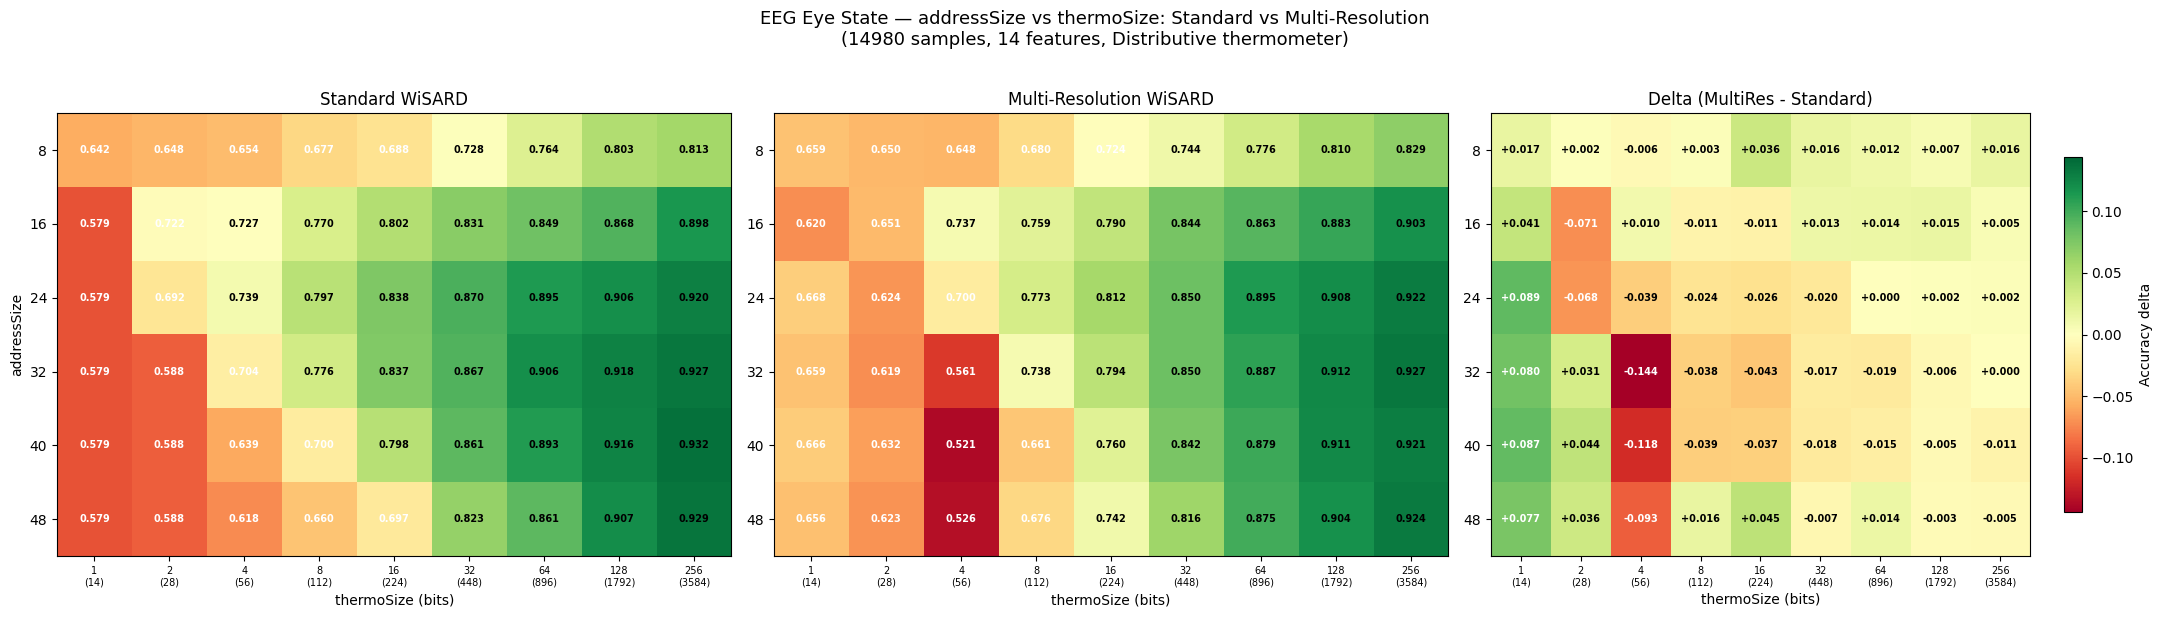

Best Standard:  addr=40, thermo=256 -> 0.9316
Best MultiRes:  addr=32, thermo=256 -> 0.9268


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
x_labels = [f'{ts}\n({n_hm_feat*ts})' for ts in HEATMAP_THERMO_SIZES]
y_labels = [str(a) for a in HEATMAP_ADDRESS_SIZES]

# Standard heatmap
ax = axes[0]
vmin = min(acc_matrix_std.min(), acc_matrix_mr.min()) - 0.01
vmax = max(acc_matrix_std.max(), acc_matrix_mr.max()) + 0.01
im = ax.imshow(acc_matrix_std, cmap='RdYlGn', aspect='auto', vmin=vmin, vmax=vmax)
for i in range(len(HEATMAP_ADDRESS_SIZES)):
    for j in range(len(HEATMAP_THERMO_SIZES)):
        val = acc_matrix_std[i, j]
        color = 'white' if val < (vmin + vmax) / 2 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=color, fontweight='bold')
ax.set_xticks(range(len(HEATMAP_THERMO_SIZES))); ax.set_xticklabels(x_labels, fontsize=7)
ax.set_yticks(range(len(HEATMAP_ADDRESS_SIZES))); ax.set_yticklabels(y_labels)
ax.set_xlabel('thermoSize (bits)'); ax.set_ylabel('addressSize')
ax.set_title('Standard WiSARD')

# Multi-resolution heatmap
ax = axes[1]
im2 = ax.imshow(acc_matrix_mr, cmap='RdYlGn', aspect='auto', vmin=vmin, vmax=vmax)
for i in range(len(HEATMAP_ADDRESS_SIZES)):
    for j in range(len(HEATMAP_THERMO_SIZES)):
        val = acc_matrix_mr[i, j]
        color = 'white' if val < (vmin + vmax) / 2 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=color, fontweight='bold')
ax.set_xticks(range(len(HEATMAP_THERMO_SIZES))); ax.set_xticklabels(x_labels, fontsize=7)
ax.set_yticks(range(len(HEATMAP_ADDRESS_SIZES))); ax.set_yticklabels(y_labels)
ax.set_xlabel('thermoSize (bits)')
ax.set_title('Multi-Resolution WiSARD')

# Delta heatmap
ax = axes[2]
delta = acc_matrix_mr - acc_matrix_std
dmax = max(abs(delta.min()), abs(delta.max()))
if dmax == 0: dmax = 0.01
im3 = ax.imshow(delta, cmap='RdYlGn', aspect='auto', vmin=-dmax, vmax=dmax)
for i in range(len(HEATMAP_ADDRESS_SIZES)):
    for j in range(len(HEATMAP_THERMO_SIZES)):
        val = delta[i, j]
        color = 'white' if abs(val) > dmax * 0.4 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=7, color=color, fontweight='bold')
ax.set_xticks(range(len(HEATMAP_THERMO_SIZES))); ax.set_xticklabels(x_labels, fontsize=7)
ax.set_yticks(range(len(HEATMAP_ADDRESS_SIZES))); ax.set_yticklabels(y_labels)
ax.set_xlabel('thermoSize (bits)')
ax.set_title('Delta (MultiRes - Standard)')
plt.colorbar(im3, ax=ax, label='Accuracy delta', shrink=0.8)

plt.suptitle(f'EEG Eye State — addressSize vs thermoSize: Standard vs Multi-Resolution\n({X_hm.shape[0]} samples, {n_hm_feat} features, Distributive thermometer)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

best_std = np.unravel_index(acc_matrix_std.argmax(), acc_matrix_std.shape)
best_mr = np.unravel_index(acc_matrix_mr.argmax(), acc_matrix_mr.shape)
print(f"Best Standard:  addr={HEATMAP_ADDRESS_SIZES[best_std[0]]}, thermo={HEATMAP_THERMO_SIZES[best_std[1]]} -> {acc_matrix_std.max():.4f}")
print(f"Best MultiRes:  addr={HEATMAP_ADDRESS_SIZES[best_mr[0]]}, thermo={HEATMAP_THERMO_SIZES[best_mr[1]]} -> {acc_matrix_mr.max():.4f}")

---
## Paper Replication

## 12. Baseline Thermometer Comparison (Paper Reproduction)

Comparing the **4 standard thermometer encodings** from the literature across all datasets:

| Thermometer | Thresholds |
|-------------|------------|
| **Linear** | Per-feature evenly spaced (min/max from training data) |
| **Gaussian** | Per-feature equal-probability regions under Gaussian curve |
| **Exponential** | Per-feature equal-probability regions under exponential curve |
| **Distributive** | Per-feature equal-count percentile regions from training data |

In [7]:
# === Run baseline experiment: standard thermometers ===
baseline_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    n_bits = X_ds.shape[1] * ts

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat | addr={addr_size}, thermo={ts}, binary={n_bits} bits")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    for tt in BASELINE_THERMO_TYPES:
        t0 = time.time()
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)

        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)

        accs = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr_size)
            w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
            preds = w.classify(wp.DataSet(X_te_bin))
            accs.append(compute_accuracy(preds, y_te))

        mean_acc, std_acc = np.mean(accs), np.std(accs)
        baseline_results[(ds_name, tt)] = (mean_acc, std_acc)
        elapsed = time.time() - t0
        print(f"  {tt:15s}: {mean_acc:.4f} +/- {std_acc:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat | addr=8, thermo=32, binary=288 bits
  Linear         : 0.6852 +/- 0.0359  (0.1s)
  Gaussian       : 0.7385 +/- 0.0413  (0.0s)
  Exponential    : 0.6815 +/- 0.0454  (0.0s)
  Distributive   : 0.7585 +/- 0.0259  (0.0s)

Ecoli: 336 samples, 7 feat | addr=10, thermo=32, binary=224 bits
  Linear         : 0.8271 +/- 0.0219  (0.1s)
  Gaussian       : 0.8314 +/- 0.0192  (0.1s)
  Exponential    : 0.8033 +/- 0.0224  (0.1s)
  Distributive   : 0.8333 +/- 0.0168  (0.1s)

Vehicle: 846 samples, 18 feat | addr=14, thermo=32, binary=576 bits
  Linear         : 0.7030 +/- 0.0235  (0.3s)
  Gaussian       : 0.7089 +/- 0.0144  (0.3s)
  Exponential    : 0.6147 +/- 0.0299  (0.3s)
  Distributive   : 0.7115 +/- 0.0154  (0.3s)

Cardiotocography: 2126 samples, 35 feat | addr=20, thermo=32, binary=1120 bits
  Linear         : 0.9999 +/- 0.0004  (1.5s)
  Gaussian       : 0.9914 +/- 0.0023  (1.6s)
  Exponential    : 0.9994 +/- 0.0009  (1.6s)
  Distributive   : 0.9936 +/- 0.0025  (1.6s)


KeyboardInterrupt: 

In [ ]:
# === Baseline results table ===
ds_names = list(datasets.keys())
df = pd.DataFrame(index=ds_names, columns=BASELINE_THERMO_TYPES)
for ds_name in ds_names:
    for tt in BASELINE_THERMO_TYPES:
        m, s = baseline_results[(ds_name, tt)]
        df.loc[ds_name, tt] = f"{m:.4f} +/- {s:.4f}"
print(df.to_string())

In [ ]:
# === Baseline bar chart per dataset ===
n_datasets = len(ds_names)
n_thermos = len(BASELINE_THERMO_TYPES)
cmap = plt.colormaps.get_cmap('tab10')
colors = [cmap(i) for i in range(n_thermos)]

fig, axes = plt.subplots(2, (n_datasets + 1) // 2, figsize=(20, 8))
axes = axes.flat

for idx, ds_name in enumerate(ds_names):
    ax = axes[idx]
    means = [baseline_results[(ds_name, tt)][0] for tt in BASELINE_THERMO_TYPES]
    stds = [baseline_results[(ds_name, tt)][1] for tt in BASELINE_THERMO_TYPES]

    bars = ax.bar(range(n_thermos), means, yerr=stds, color=colors[:n_thermos],
                  edgecolor='white', linewidth=0.5, capsize=3)
    ax.set_title(ds_name, fontsize=10)
    ax.set_xticks(range(n_thermos))
    ax.set_xticklabels([t[:4] for t in BASELINE_THERMO_TYPES], fontsize=8)
    ax.set_ylim(min(means) - 0.05, min(max(means) + 0.05, 1.0))
    ax.tick_params(axis='y', labelsize=8)

    best = np.argmax(means)
    ax.bar(best, means[best], color=colors[best], edgecolor='black', linewidth=1.5)

for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

fig.legend(BASELINE_THERMO_TYPES, loc='upper center', ncol=len(BASELINE_THERMO_TYPES), fontsize=10,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Baseline: Accuracy by dataset and thermometer type', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## 13. Supervised Binarization Approaches

We explore 4 supervised approaches to improve on the Distributive thermometer:

| Approach | Method | Key Idea |
|----------|--------|----------|
| **Class-Conditional** | `SupervisedThermometer(method='class_conditional')` | Equal-frequency quantiles computed per class, then merged |
| **MI Allocation** | `SupervisedThermometer(method='mi_allocation')` | Allocate more bits to high-MI features, fewer to noisy ones |
| **Entropy-Weighted** | `SupervisedThermometer(method='entropy_weighted')` | Concentrate thresholds at class-overlap regions (high local entropy) |
| **Stochastic** | `StochasticThermometer` + `optimize()` | Coordinate descent on individual thresholds using WiSARD accuracy as objective |

All are compared against the **Distributive** baseline (the strongest unsupervised method from Section 12).

In [8]:
# === Load EEG Eye State for exploration ===
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

explore_ds_name = "EEG Eye State"
explore_addr, explore_thermo, explore_val = DATASET_CONFIG[explore_ds_name]

d = fetch_openml(data_id=1471, as_frame=False, parser='auto')
X_exp, y_exp = d.data.astype(float), d.target.astype(str)
mi_sklearn = mutual_info_classif(X_exp, y_exp)
unique_classes = sorted(set(y_exp))

print(f"Loaded {explore_ds_name}: {X_exp.shape[0]} samples, {X_exp.shape[1]} features, {len(unique_classes)} classes")

Loaded EEG Eye State: 14980 samples, 14 features, 2 classes


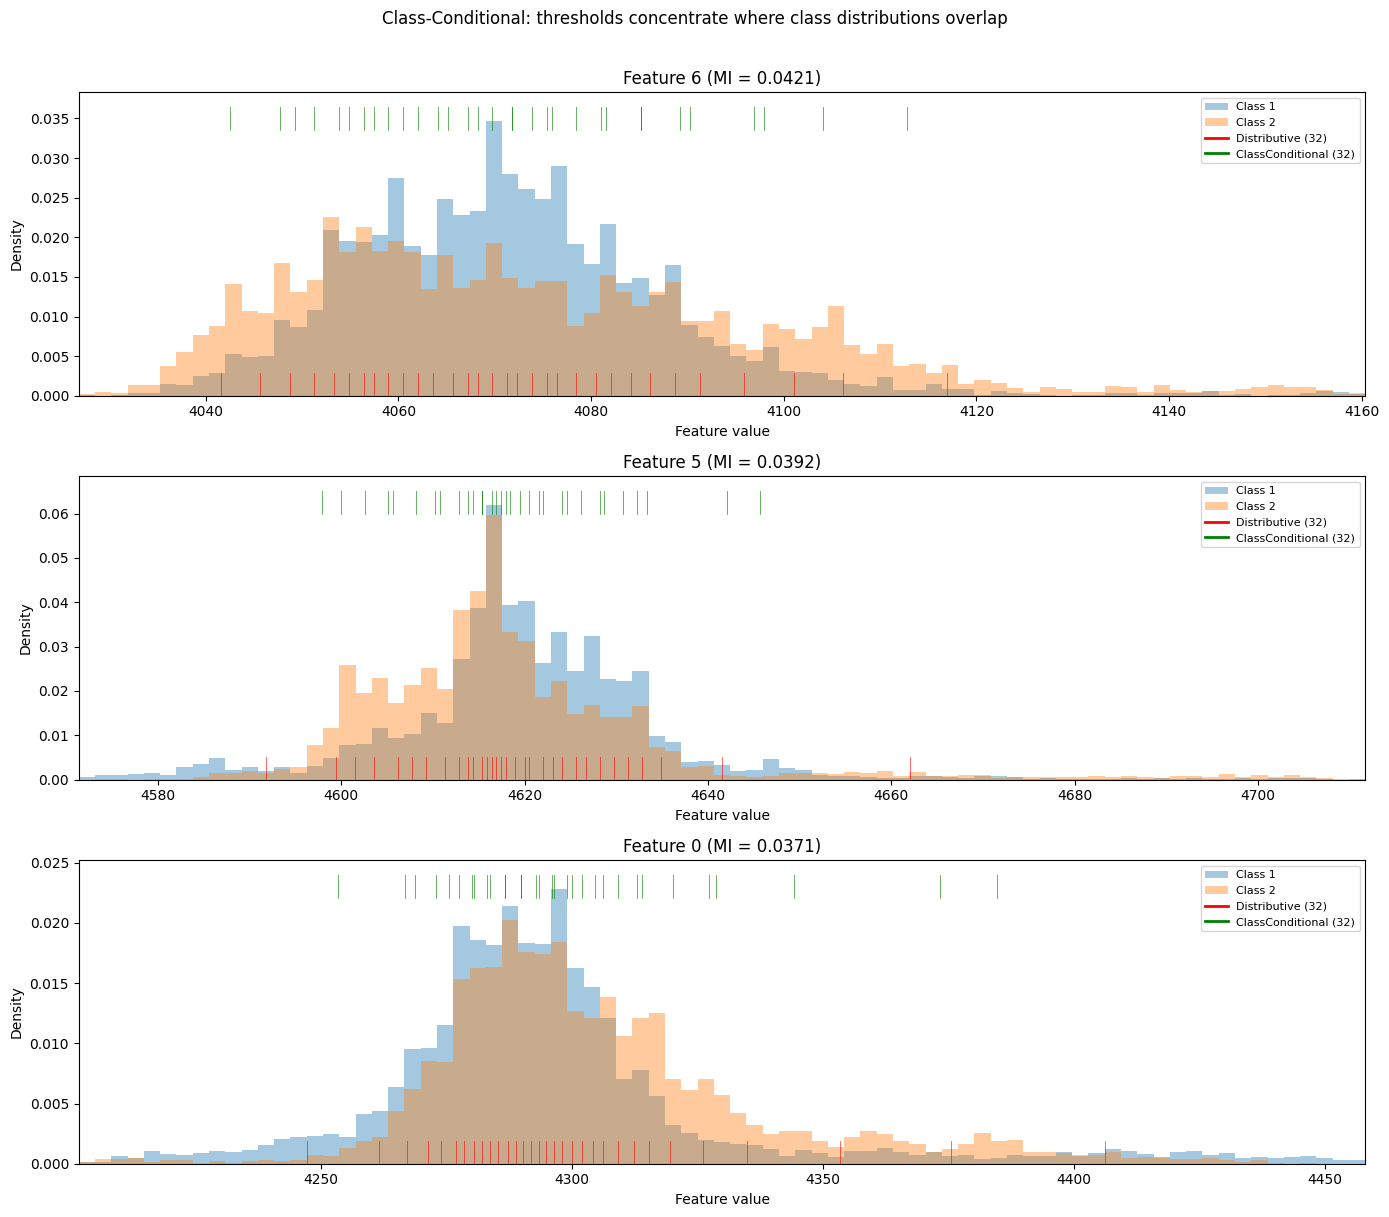

In [9]:
# === 13.1 Class-Conditional Exploration ===
# Per-class histograms + threshold positions: Distributive vs Class-Conditional

dt = wp.DistributiveThermometer(explore_thermo)
dt.fit(X_exp.tolist())
dt_thresholds = dt.getThresholds()

st_cc = wp.SupervisedThermometer(explore_thermo, 'class_conditional')
st_cc.fit(X_exp.tolist(), y_exp.tolist())
cc_thresholds = st_cc.getThresholds()

top_features = np.argsort(mi_sklearn)[::-1][:3]

fig, axes = plt.subplots(len(top_features), 1, figsize=(14, 4 * len(top_features)))
for ax_idx, f in enumerate(top_features):
    ax = axes[ax_idx]
    feat_vals = X_exp[:, f]
    p1, p99 = np.percentile(feat_vals, [1, 99])
    margin = (p99 - p1) * 0.1
    xlim = (p1 - margin, p99 + margin)
    bins = np.linspace(xlim[0], xlim[1], 80)

    for cls in unique_classes:
        ax.hist(feat_vals[y_exp == cls], bins=bins, alpha=0.4, label=f'Class {cls}', density=True)

    dt_t = [t for t in dt_thresholds[f] if xlim[0] <= t <= xlim[1]]
    cc_t = [t for t in cc_thresholds[f] if xlim[0] <= t <= xlim[1]]
    y_lo, y_hi = ax.get_ylim()
    tick_h = (y_hi - y_lo) * 0.08
    for t in dt_t: ax.plot([t, t], [y_lo, y_lo + tick_h], color='red', linewidth=0.6, alpha=0.7)
    for t in cc_t: ax.plot([t, t], [y_hi - tick_h, y_hi], color='green', linewidth=0.6, alpha=0.7)
    ax.plot([], [], color='red', linewidth=2, label=f'Distributive ({len(dt_thresholds[f])})')
    ax.plot([], [], color='green', linewidth=2, label=f'ClassConditional ({len(cc_thresholds[f])})')
    ax.set_xlim(xlim)
    ax.set_title(f'Feature {f} (MI = {mi_sklearn[f]:.4f})')
    ax.set_xlabel('Feature value'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

plt.suptitle('Class-Conditional: thresholds concentrate where class distributions overlap', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

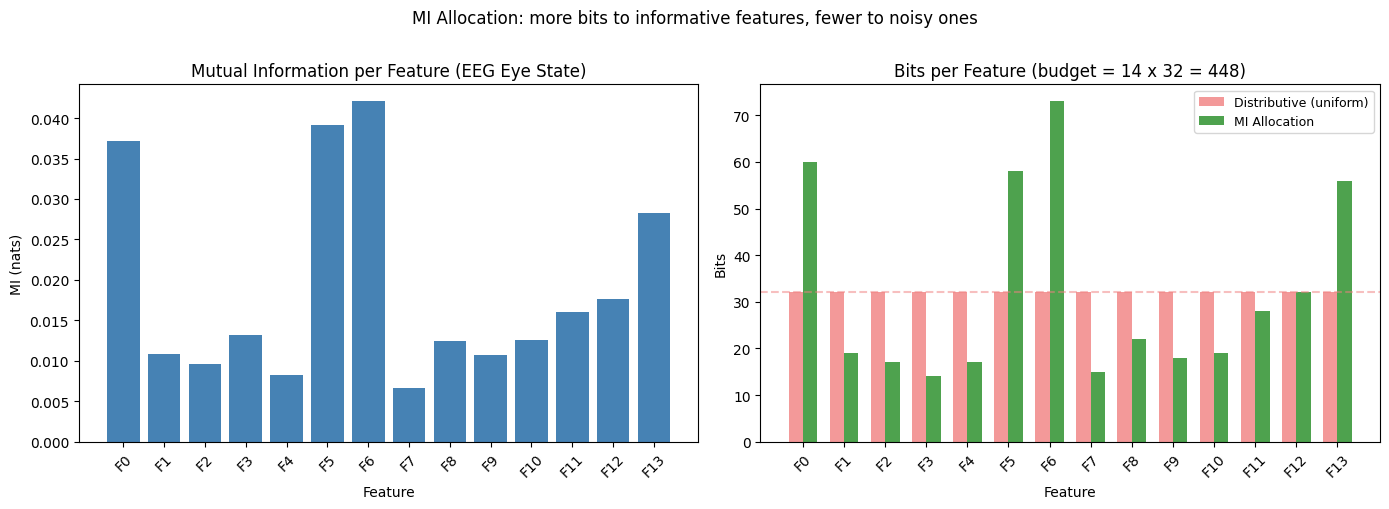

Bit allocation: {'F0': 60, 'F1': 19, 'F2': 17, 'F3': 14, 'F4': 17, 'F5': 58, 'F6': 73, 'F7': 15, 'F8': 22, 'F9': 18, 'F10': 19, 'F11': 28, 'F12': 32, 'F13': 56}


In [10]:
# === 13.2 MI Allocation Exploration ===
# Show MI per feature and resulting bit allocation

st_mi = wp.SupervisedThermometer(explore_thermo, 'mi_allocation')
st_mi.fit(X_exp.tolist(), y_exp.tolist())
mi_sizes = st_mi.getSizes()
feature_names = [f"F{i}" for i in range(X_exp.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(feature_names, mi_sklearn, color='steelblue')
ax.set_title(f'Mutual Information per Feature ({explore_ds_name})')
ax.set_ylabel('MI (nats)'); ax.set_xlabel('Feature'); ax.tick_params(axis='x', rotation=45)

ax = axes[1]
x = np.arange(len(feature_names))
width = 0.35
ax.bar(x - width/2, [explore_thermo]*len(feature_names), width, label='Distributive (uniform)', color='lightcoral', alpha=0.8)
ax.bar(x + width/2, mi_sizes, width, label='MI Allocation', color='forestgreen', alpha=0.8)
ax.axhline(y=explore_thermo, color='lightcoral', linestyle='--', alpha=0.5)
ax.set_title(f'Bits per Feature (budget = {X_exp.shape[1]} x {explore_thermo} = {X_exp.shape[1]*explore_thermo})')
ax.set_ylabel('Bits'); ax.set_xlabel('Feature')
ax.set_xticks(x); ax.set_xticklabels(feature_names, rotation=45); ax.legend(fontsize=9)

plt.suptitle('MI Allocation: more bits to informative features, fewer to noisy ones', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()
print(f"Bit allocation: {dict(zip(feature_names, mi_sizes))}")

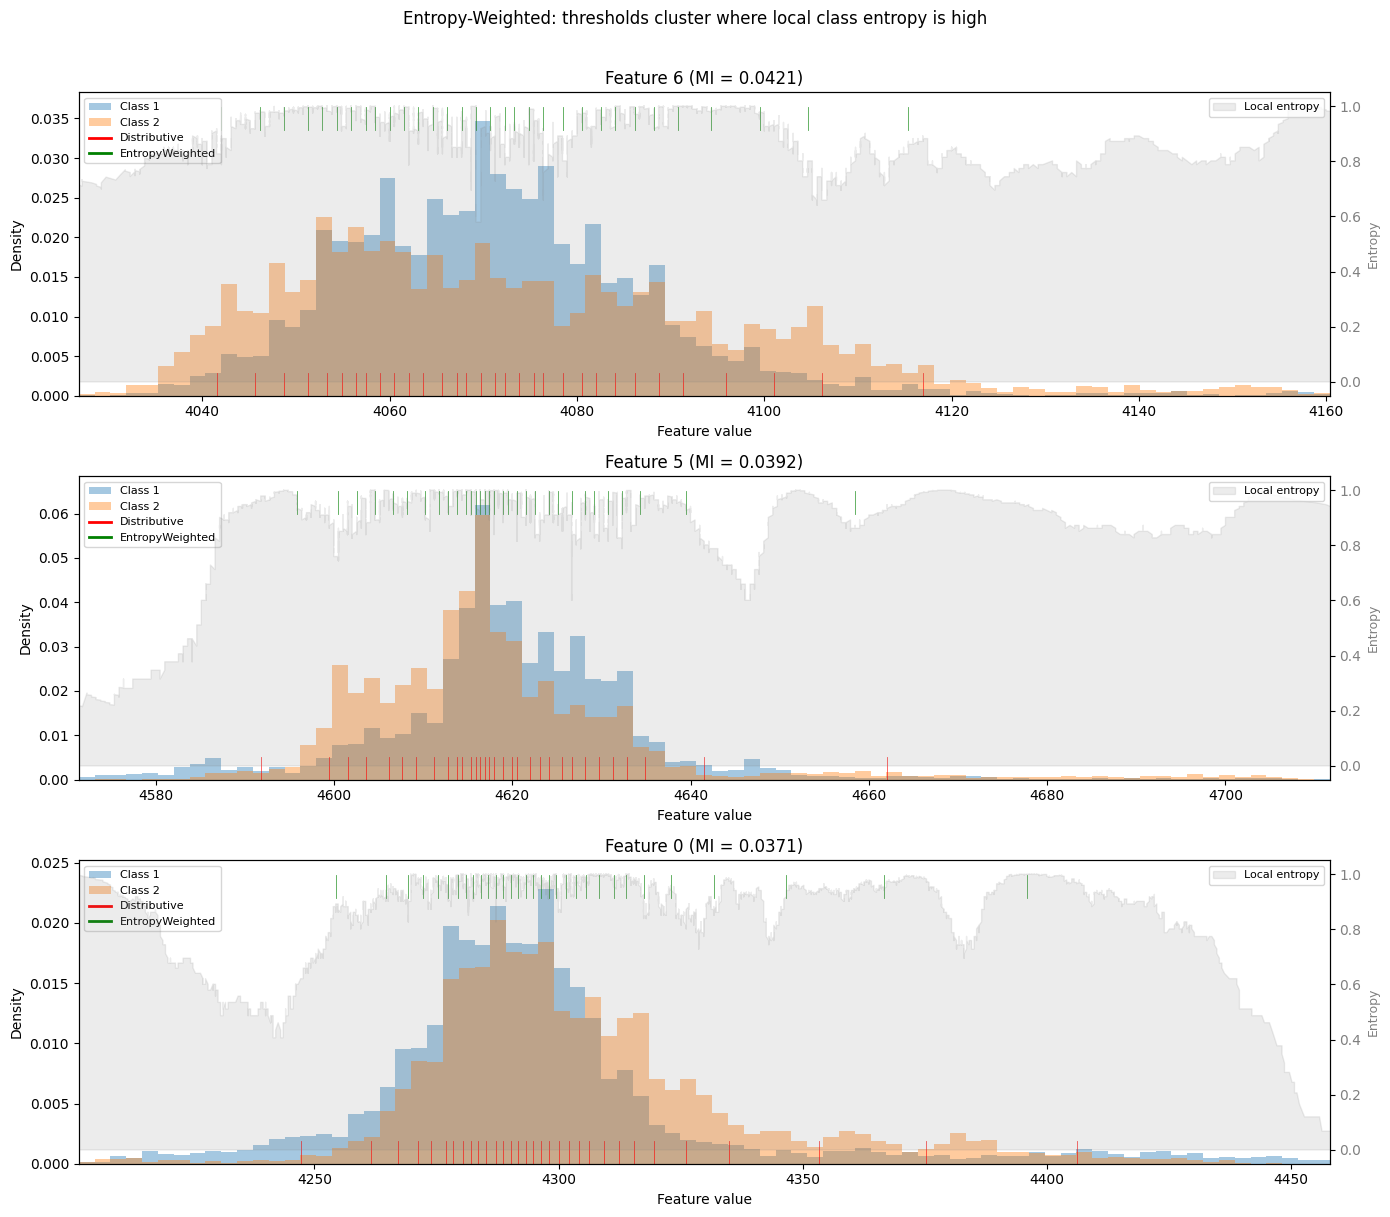

In [11]:
# === 13.3 Entropy-Weighted Exploration ===
# Show local class entropy and how thresholds concentrate at overlap regions

st_ew = wp.SupervisedThermometer(explore_thermo, 'entropy_weighted')
st_ew.fit(X_exp.tolist(), y_exp.tolist())
ew_thresholds = st_ew.getThresholds()

fig, axes = plt.subplots(len(top_features), 1, figsize=(14, 4 * len(top_features)))
for ax_idx, f in enumerate(top_features):
    ax = axes[ax_idx]
    feat_vals = X_exp[:, f]
    p1, p99 = np.percentile(feat_vals, [1, 99])
    margin = (p99 - p1) * 0.1
    xlim = (p1 - margin, p99 + margin)
    bins = np.linspace(xlim[0], xlim[1], 80)

    for cls in unique_classes:
        ax.hist(feat_vals[y_exp == cls], bins=bins, alpha=0.4, label=f'Class {cls}', density=True)

    # Compute and plot local entropy
    sorted_idx = np.argsort(feat_vals)
    sorted_vals, sorted_labels = feat_vals[sorted_idx], y_exp[sorted_idx]
    w = max(10, int(np.sqrt(len(feat_vals))))
    w = min(w, len(feat_vals) // 4)
    half_w = w // 2
    entropies = np.zeros(len(sorted_vals))
    for i in range(len(sorted_vals)):
        lo, hi = max(0, i - half_w), min(len(sorted_vals), i + half_w + 1)
        _, counts = np.unique(sorted_labels[lo:hi], return_counts=True)
        probs = counts / counts.sum()
        entropies[i] = -np.sum(probs * np.log2(probs + 1e-12))

    ax2 = ax.twinx()
    ax2.fill_between(sorted_vals, entropies, alpha=0.15, color='gray', label='Local entropy')
    ax2.set_ylabel('Entropy', color='gray', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='gray')

    dt_t = [t for t in dt_thresholds[f] if xlim[0] <= t <= xlim[1]]
    ew_t = [t for t in ew_thresholds[f] if xlim[0] <= t <= xlim[1]]
    y_lo, y_hi = ax.get_ylim()
    tick_h = (y_hi - y_lo) * 0.08
    for t in dt_t: ax.plot([t, t], [y_lo, y_lo + tick_h], color='red', linewidth=0.6, alpha=0.7)
    for t in ew_t: ax.plot([t, t], [y_hi - tick_h, y_hi], color='green', linewidth=0.6, alpha=0.7)
    ax.plot([], [], color='red', linewidth=2, label='Distributive')
    ax.plot([], [], color='green', linewidth=2, label='EntropyWeighted')
    ax.set_xlim(xlim)
    ax.set_title(f'Feature {f} (MI = {mi_sklearn[f]:.4f})')
    ax.set_xlabel('Feature value'); ax.set_ylabel('Density')
    ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Entropy-Weighted: thresholds cluster where local class entropy is high', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [12]:
# === 13.4 Stochastic Exploration ===
# Show threshold drift from Distributive baseline after coordinate descent

X_s_train, _, y_s_train, _ = train_test_split(X_exp, y_exp, test_size=0.25)

dt_s = wp.DistributiveThermometer(explore_thermo)
dt_s.fit(X_s_train.tolist())
dt_s_thresholds = dt_s.getThresholds()

st_s = wp.StochasticThermometer(explore_thermo)
st_s.fit(X_s_train.tolist())
st_s.optimize(X_s_train.tolist(), y_s_train.tolist(), addressSize=explore_addr,
              validationSize=0.25, rounds=STOCHASTIC_ROUNDS,
              stepsPerThreshold=STOCHASTIC_STEPS_PER_THRESHOLD, numThreads=STOCHASTIC_NUM_THREADS,
              maxShiftRatio=STOCHASTIC_MAX_SHIFT_RATIO, earlyStopWindow=STOCHASTIC_EARLY_STOP_WINDOW)
st_s_thresholds = st_s.getThresholds()

n_feat = X_exp.shape[1]
drift = np.array([[st_s_thresholds[f][k] - dt_s_thresholds[f][k]
                    for k in range(explore_thermo)] for f in range(n_feat)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
im = ax.imshow(np.abs(drift), aspect='auto', cmap='YlOrRd')
ax.set_title('|Threshold Drift| from Distributive'); ax.set_xlabel('Threshold index'); ax.set_ylabel('Feature')
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
ax.barh(range(n_feat), np.sum(np.abs(drift), axis=1), color='steelblue')
ax.set_yticks(range(n_feat)); ax.set_yticklabels([f'F{i}' for i in range(n_feat)])
ax.set_title('Total |Drift| per Feature'); ax.set_xlabel('Sum of |changes|'); ax.invert_yaxis()

ax = axes[2]
rel_drifts = []
for f in range(n_feat):
    for k in range(explore_thermo):
        gap = dt_s_thresholds[f][min(k+1, explore_thermo-1)] - dt_s_thresholds[f][max(k-1, 0)]
        if gap > 0: rel_drifts.append(abs(drift[f, k]) / gap)
ax.hist(rel_drifts, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Relative Drift (drift / neighbor gap)'); ax.set_xlabel('Relative magnitude'); ax.set_ylabel('Count')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% of gap'); ax.legend(fontsize=8)

n_moved = sum(1 for d in np.abs(drift).flat if d > 1e-10)
plt.suptitle(f'Stochastic: Coordinate descent threshold optimization (rounds={STOCHASTIC_ROUNDS}, steps={STOCHASTIC_STEPS_PER_THRESHOLD})', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()
print(f'Thresholds modified: {n_moved}/{n_feat*explore_thermo} ({100*n_moved/(n_feat*explore_thermo):.1f}%)')

KeyboardInterrupt: 

In [ ]:
# === 13.5 Run supervised comparison experiment ===
supervised_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    n_bits = X_ds.shape[1] * ts

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat | addr={addr_size}, thermo={ts}, binary={n_bits} bits")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    for tt in SUPERVISED_THERMO_TYPES:
        t0 = time.time()
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)

        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)

        accs = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr_size)
            w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
            preds = w.classify(wp.DataSet(X_te_bin))
            accs.append(compute_accuracy(preds, y_te))

        mean_acc, std_acc = np.mean(accs), np.std(accs)
        supervised_results[(ds_name, tt)] = (mean_acc, std_acc)
        elapsed = time.time() - t0
        print(f"  {tt:20s}: {mean_acc:.4f} +/- {std_acc:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")

In [ ]:
# === 13.6 Supervised results table + bar chart ===
sup_ds_names = list(datasets.keys())

# Table
df_sup = pd.DataFrame(index=sup_ds_names, columns=SUPERVISED_THERMO_TYPES)
for ds_name in sup_ds_names:
    for tt in SUPERVISED_THERMO_TYPES:
        m, s = supervised_results[(ds_name, tt)]
        df_sup.loc[ds_name, tt] = f"{m:.4f} +/- {s:.4f}"
print(df_sup.to_string())

# Bar chart
n_datasets = len(sup_ds_names)
n_thermos = len(SUPERVISED_THERMO_TYPES)
cmap = plt.colormaps.get_cmap('tab10')
colors = [cmap(i) for i in range(n_thermos)]

fig, axes = plt.subplots(2, (n_datasets + 1) // 2, figsize=(20, 8))
axes = axes.flat

for idx, ds_name in enumerate(sup_ds_names):
    ax = axes[idx]
    means = [supervised_results[(ds_name, tt)][0] for tt in SUPERVISED_THERMO_TYPES]
    stds = [supervised_results[(ds_name, tt)][1] for tt in SUPERVISED_THERMO_TYPES]
    bars = ax.bar(range(n_thermos), means, yerr=stds, color=colors, edgecolor='white', linewidth=0.5, capsize=3)
    ax.set_title(ds_name, fontsize=10)
    ax.set_xticks(range(n_thermos))
    ax.set_xticklabels([t[:5] for t in SUPERVISED_THERMO_TYPES], fontsize=7)
    ax.set_ylim(min(means) - 0.05, min(max(means) + 0.05, 1.0))
    ax.tick_params(axis='y', labelsize=8)
    best = np.argmax(means)
    ax.bar(best, means[best], color=colors[best], edgecolor='black', linewidth=1.5)

for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

fig.legend(SUPERVISED_THERMO_TYPES, loc='upper center', ncol=len(SUPERVISED_THERMO_TYPES), fontsize=9,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Supervised approaches vs Distributive baseline', fontsize=13, y=1.05)
plt.tight_layout(); plt.show()

## 14. PCA Preprocessing Experiment

PCA decorrelates features before binarization. This is **not** a binarization technique — it's a preprocessing step that feeds the thermometer uncorrelated inputs. Correlated features (e.g., EEG electrodes) waste thermometer bits encoding redundant information; PCA eliminates this redundancy.

We test all 5 approaches (Distributive + 4 supervised) **with and without PCA** to see which combinations benefit.

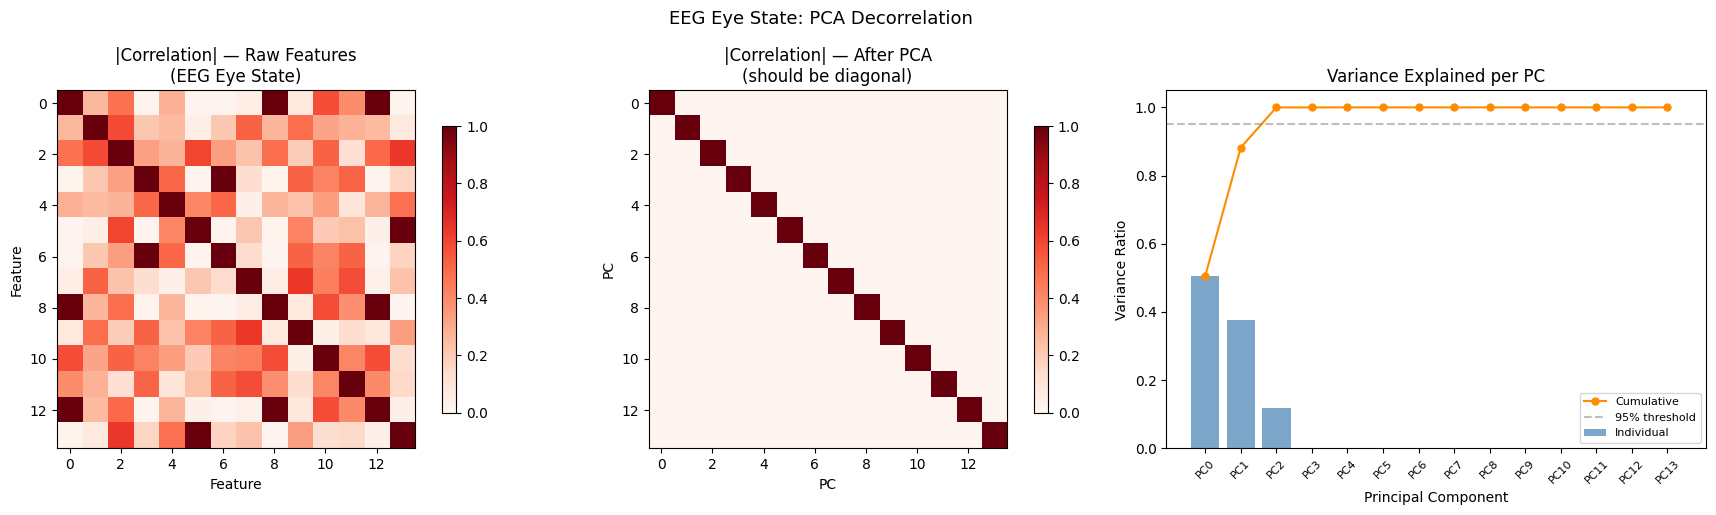

Feature pairs with |corr| > 0.8: 5 / 91
PCs for 95% variance: 3 / 14


In [18]:
# === 14.1 PCA visualization: raw vs decorrelated correlation on EEG ===
from sklearn.decomposition import PCA

pca_vis = PCA()
X_pca_vis = pca_vis.fit_transform(X_exp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
corr_raw = np.corrcoef(X_exp.T)
im = ax.imshow(np.abs(corr_raw), cmap='Reds', vmin=0, vmax=1)
ax.set_title(f'|Correlation| — Raw Features\n({explore_ds_name})')
ax.set_xlabel('Feature'); ax.set_ylabel('Feature')
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
corr_pca = np.corrcoef(X_pca_vis.T)
im2 = ax.imshow(np.abs(corr_pca), cmap='Reds', vmin=0, vmax=1)
ax.set_title('|Correlation| — After PCA\n(should be diagonal)')
ax.set_xlabel('PC'); ax.set_ylabel('PC')
plt.colorbar(im2, ax=ax, shrink=0.8)

ax = axes[2]
var_ratio = pca_vis.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
ax.bar(range(len(var_ratio)), var_ratio, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(len(cum_var)), cum_var, 'o-', color='darkorange', markersize=5, label='Cumulative')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
ax.set_title('Variance Explained per PC')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Ratio')
ax.legend(fontsize=8)
ax.set_xticks(range(len(var_ratio)))
ax.set_xticklabels([f'PC{i}' for i in range(len(var_ratio))], rotation=45, fontsize=8)

n_corr_pairs = int((np.abs(corr_raw) > 0.8).sum() - X_exp.shape[1]) // 2
n_95 = np.searchsorted(cum_var, 0.95) + 1
plt.suptitle(f'{explore_ds_name}: PCA Decorrelation', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f'Feature pairs with |corr| > 0.8: {n_corr_pairs} / {X_exp.shape[1]*(X_exp.shape[1]-1)//2}')
print(f'PCs for 95% variance: {n_95} / {X_exp.shape[1]}')

In [19]:
# === 14.2 PCA experiment: all approaches with and without PCA ===
from sklearn.decomposition import PCA

PCA_THERMO_TYPES = SUPERVISED_THERMO_TYPES  # Distributive + 4 supervised
pca_results = {}  # (dataset, thermo_type, pca_flag) -> (mean, std)

total_start = time.time()
for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    # PCA: fit on train, transform both
    pca = PCA()
    X_tr_pca = pca.fit_transform(X_tr)
    X_te_pca = pca.transform(X_te)

    for use_pca in [False, True]:
        X_tr_use = X_tr_pca if use_pca else X_tr
        X_te_use = X_te_pca if use_pca else X_te
        pca_label = "PCA" if use_pca else "Raw"

        for tt in PCA_THERMO_TYPES:
            t0 = time.time()
            thermo = create_and_fit_thermometer(tt, ts, X_tr_use,
                address_size=addr_size, y_train=y_tr, validation_size=val_size)

            X_tr_bin = binarize_dataset(X_tr_use, thermo)
            X_te_bin = binarize_dataset(X_te_use, thermo)

            accs = []
            for run in range(N_RUNS):
                w = wp.Wisard(addr_size)
                w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
                preds = w.classify(wp.DataSet(X_te_bin))
                accs.append(compute_accuracy(preds, y_te))

            mean_acc, std_acc = np.mean(accs), np.std(accs)
            pca_results[(ds_name, tt, use_pca)] = (mean_acc, std_acc)
            elapsed = time.time() - t0
            print(f"  {pca_label:3s} + {tt:20s}: {mean_acc:.4f} +/- {std_acc:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat
  Raw + Distributive        : 0.6741 +/- 0.0246  (0.1s)
  Raw + ClassConditional    : 0.6822 +/- 0.0271  (0.0s)
  Raw + MIAllocation        : 0.6815 +/- 0.0251  (0.0s)
  Raw + EntropyWeighted     : 0.6807 +/- 0.0224  (0.0s)
  Raw + Stochastic          : 0.6785 +/- 0.0188  (0.3s)
  PCA + Distributive        : 0.6356 +/- 0.0425  (0.0s)
  PCA + ClassConditional    : 0.6185 +/- 0.0370  (0.0s)
  PCA + MIAllocation        : 0.6422 +/- 0.0255  (0.0s)
  PCA + EntropyWeighted     : 0.6230 +/- 0.0398  (0.0s)
  PCA + Stochastic          : 0.6422 +/- 0.0304  (0.3s)

Ecoli: 336 samples, 7 feat
  Raw + Distributive        : 0.8238 +/- 0.0147  (0.1s)
  Raw + ClassConditional    : 0.7895 +/- 0.0198  (0.1s)
  Raw + MIAllocation        : 0.8205 +/- 0.0184  (0.1s)
  Raw + EntropyWeighted     : 0.8367 +/- 0.0133  (0.1s)
  Raw + Stochastic          : 0.8243 +/- 0.0234  (0.2s)
  PCA + Distributive        : 0.8257 +/- 0.0228  (0.1s)
  PCA + ClassConditional    : 0.8148 +/- 0.0238 

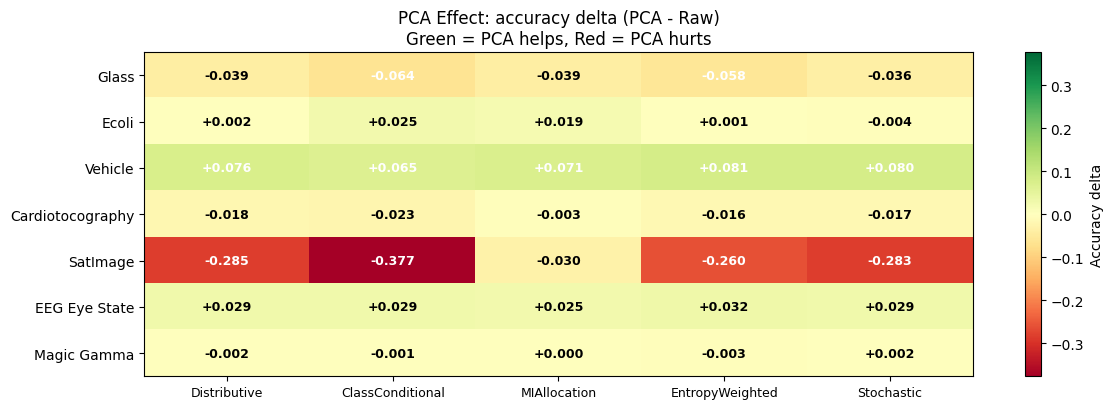

In [20]:
# === 14.3 PCA results: delta heatmap (PCA - Raw) per method and dataset ===
pca_ds_names = list(datasets.keys())

# Build delta matrix: rows = datasets, columns = thermo types, value = PCA_acc - Raw_acc
delta_data = np.zeros((len(pca_ds_names), len(PCA_THERMO_TYPES)))
for i, ds_name in enumerate(pca_ds_names):
    for j, tt in enumerate(PCA_THERMO_TYPES):
        raw_mean = pca_results[(ds_name, tt, False)][0]
        pca_mean = pca_results[(ds_name, tt, True)][0]
        delta_data[i, j] = pca_mean - raw_mean

fig, ax = plt.subplots(figsize=(12, max(4, len(pca_ds_names) * 0.6)))
vmax = max(abs(delta_data.min()), abs(delta_data.max()))
if vmax == 0: vmax = 0.01
im = ax.imshow(delta_data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(pca_ds_names)):
    for j in range(len(PCA_THERMO_TYPES)):
        val = delta_data[i, j]
        color = 'white' if abs(val) > 0.05 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(len(PCA_THERMO_TYPES)))
ax.set_xticklabels(PCA_THERMO_TYPES, fontsize=9)
ax.set_yticks(range(len(pca_ds_names)))
ax.set_yticklabels(pca_ds_names)
ax.set_title('PCA Effect: accuracy delta (PCA - Raw)\nGreen = PCA helps, Red = PCA hurts', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy delta')
plt.tight_layout(); plt.show()

## 15. Multi-Resolution WiSARD

Standard WiSARD assigns all RAMs the same address size. This is like a committee where every member has identical expertise. Inspired by **Random Forests** (where each decision tree has different depth and sees different features), we create RAMs with **varying sizes**:

- **Small RAMs** (fewer address bits): see coarse patterns, vote confidently (many training samples map to the same address). These are "generalists."
- **Large RAMs** (more address bits): see precise patterns, vote cautiously (few repeated addresses). These are "specialists."

The ensemble of generalists + specialists is combined by WiSARD's existing Bleaching mechanism, which naturally filters out weak votes.

**API**: `wp.Wisard(28, multiResolution=True)` — RAM sizes vary randomly in `[addressSize/2, addressSize]`.

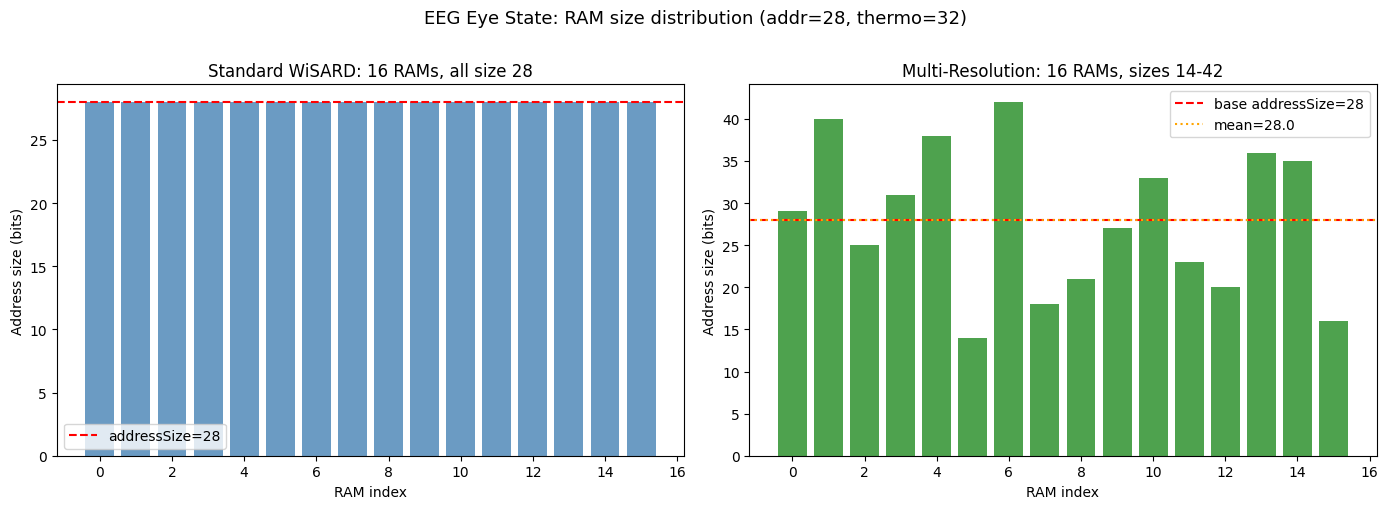

Standard: 16 RAMs × 28 bits = 448 total address bits
MultiRes: 16 RAMs, sizes=[14, 16, 18, 20, 21, 23, 25, 27, 29, 31, 33, 35, 36, 38, 40, 42], total=448 bits


In [13]:
# === 15.1 Exploration: RAM size distribution ===
# Compare standard (uniform) vs multi-resolution (variable) RAM sizes on EEG Eye State

explore_addr_mr, explore_thermo_mr, _ = DATASET_CONFIG["EEG Eye State"]
d_mr = fetch_openml(data_id=1471, as_frame=False, parser='auto')
X_mr, y_mr = d_mr.data.astype(float), d_mr.target.astype(str)
X_mr_tr, X_mr_te, y_mr_tr, y_mr_te = train_test_split(X_mr, y_mr, test_size=0.25)

dt_mr = wp.DistributiveThermometer(explore_thermo_mr)
dt_mr.fit(X_mr_tr.tolist())
bins_mr = binarize_dataset(X_mr_tr, dt_mr)

w_std = wp.Wisard(explore_addr_mr)
w_std.train(wp.DataSet(bins_mr, y_mr_tr.tolist()))
sizes_std = list(w_std.getTupleSizes().values())[0]

w_mr = wp.Wisard(explore_addr_mr, multiResolution=True)
w_mr.train(wp.DataSet(bins_mr, y_mr_tr.tolist()))
sizes_mr = list(w_mr.getTupleSizes().values())[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(len(sizes_std)), sizes_std, color='steelblue', alpha=0.8)
ax.axhline(y=explore_addr_mr, color='red', linestyle='--', label=f'addressSize={explore_addr_mr}')
ax.set_title(f'Standard WiSARD: {len(sizes_std)} RAMs, all size {explore_addr_mr}')
ax.set_xlabel('RAM index'); ax.set_ylabel('Address size (bits)'); ax.legend()

ax = axes[1]
ax.bar(range(len(sizes_mr)), sizes_mr, color='forestgreen', alpha=0.8)
ax.axhline(y=explore_addr_mr, color='red', linestyle='--', label=f'base addressSize={explore_addr_mr}')
ax.axhline(y=np.mean(sizes_mr), color='orange', linestyle=':', label=f'mean={np.mean(sizes_mr):.1f}')
ax.set_title(f'Multi-Resolution: {len(sizes_mr)} RAMs, sizes {min(sizes_mr)}-{max(sizes_mr)}')
ax.set_xlabel('RAM index'); ax.set_ylabel('Address size (bits)'); ax.legend()

plt.suptitle(f'EEG Eye State: RAM size distribution (addr={explore_addr_mr}, thermo={explore_thermo_mr})', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f'Standard: {len(sizes_std)} RAMs × {explore_addr_mr} bits = {sum(sizes_std)} total address bits')
print(f'MultiRes: {len(sizes_mr)} RAMs, sizes={sorted(sizes_mr)}, total={sum(sizes_mr)} bits')

In [17]:
# === 15.2 Comparison: Standard vs Multi-Resolution WiSARD ===
# Test across all datasets with all baseline thermometers

MR_THERMO_TYPES = ALL_THERMO_TYPES
mr_results = {}  # (dataset, thermo, multiRes) -> (mean, std)

total_start = time.time()
for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat | addr={addr_size}, thermo={ts}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    for tt in MR_THERMO_TYPES:
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)
        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)

        for use_mr in [False, True]:
            t0 = time.time()
            accs = []
            for run in range(N_RUNS):
                w = wp.Wisard(addr_size, multiResolution=use_mr)
                w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
                preds = w.classify(wp.DataSet(X_te_bin))
                accs.append(compute_accuracy(preds, y_te))

            mean_acc, std_acc = np.mean(accs), np.std(accs)
            mr_results[(ds_name, tt, use_mr)] = (mean_acc, std_acc)
            mr_label = "MultiRes" if use_mr else "Standard"
            elapsed = time.time() - t0
            print(f"  {tt:15s} {mr_label:8s}: {mean_acc:.4f} +/- {std_acc:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat | addr=8, thermo=32
  Linear          Standard: 0.6926 +/- 0.0505  (0.1s)
  Linear          MultiRes: 0.6793 +/- 0.0440  (0.0s)
  Gaussian        Standard: 0.7459 +/- 0.0387  (0.0s)
  Gaussian        MultiRes: 0.7533 +/- 0.0362  (0.0s)
  Exponential     Standard: 0.7000 +/- 0.0402  (0.0s)
  Exponential     MultiRes: 0.6993 +/- 0.0396  (0.0s)
  Distributive    Standard: 0.7593 +/- 0.0257  (0.0s)
  Distributive    MultiRes: 0.7622 +/- 0.0313  (0.0s)
  Distributive    Standard: 0.7652 +/- 0.0220  (0.0s)
  Distributive    MultiRes: 0.7600 +/- 0.0259  (0.0s)
  ClassConditional Standard: 0.7681 +/- 0.0252  (0.0s)
  ClassConditional MultiRes: 0.7681 +/- 0.0210  (0.0s)
  MIAllocation    Standard: 0.7719 +/- 0.0244  (0.0s)
  MIAllocation    MultiRes: 0.7600 +/- 0.0243  (0.0s)
  EntropyWeighted Standard: 0.7622 +/- 0.0365  (0.0s)
  EntropyWeighted MultiRes: 0.7696 +/- 0.0278  (0.0s)
  Stochastic      Standard: 0.7622 +/- 0.0362  (0.0s)
  Stochastic      MultiRes: 0.75

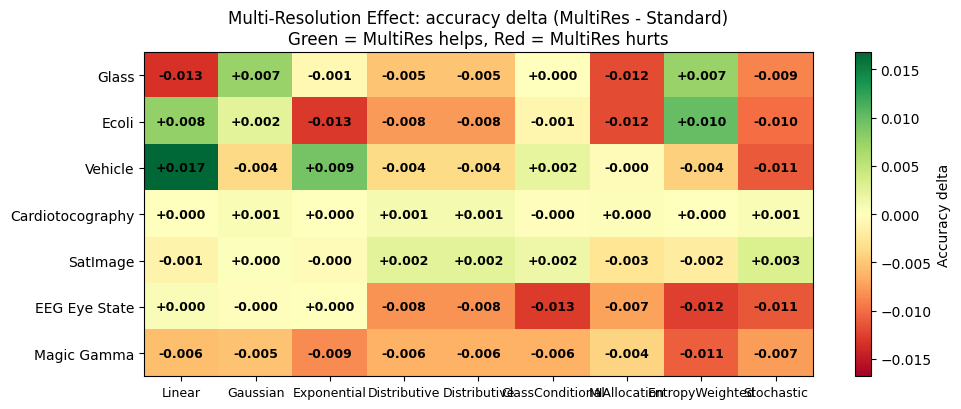

In [18]:
# === 15.3 Multi-Resolution delta heatmap ===
# For each (dataset, thermometer), show accuracy delta: MultiRes - Standard

mr_ds_names = list(datasets.keys())
delta_data = np.zeros((len(mr_ds_names), len(MR_THERMO_TYPES)))
for i, ds_name in enumerate(mr_ds_names):
    for j, tt in enumerate(MR_THERMO_TYPES):
        std_mean = mr_results[(ds_name, tt, False)][0]
        mr_mean = mr_results[(ds_name, tt, True)][0]
        delta_data[i, j] = mr_mean - std_mean

fig, ax = plt.subplots(figsize=(10, max(4, len(mr_ds_names) * 0.6)))
vmax = max(abs(delta_data.min()), abs(delta_data.max()))
if vmax == 0: vmax = 0.01
im = ax.imshow(delta_data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(mr_ds_names)):
    for j in range(len(MR_THERMO_TYPES)):
        val = delta_data[i, j]
        color = 'white' if abs(val) > 0.05 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(len(MR_THERMO_TYPES)))
ax.set_xticklabels(MR_THERMO_TYPES, fontsize=9)
ax.set_yticks(range(len(mr_ds_names)))
ax.set_yticklabels(mr_ds_names)
ax.set_title('Multi-Resolution Effect: accuracy delta (MultiRes - Standard)\nGreen = MultiRes helps, Red = MultiRes hurts', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy delta')
plt.tight_layout(); plt.show()

## 16. Multi-Resolution with Weighted Bleaching

Section 15 showed that multi-resolution RAMs hurt accuracy because **Bleaching treats all RAMs equally**. Small RAMs (generalists) produce higher vote counts than large RAMs (specialists), so Bleaching's progressive threshold filtering silences the specialists first.

**Fix**: Before Bleaching, multiply each RAM's vote by its address size. A 42-bit RAM's rare vote of 1 becomes 42, while a 14-bit RAM's common vote of 5 becomes 70. This reweighting partially compensates for the vote-count disparity — though the gap is fundamentally exponential (2^14 vs 2^42 addresses), linear weighting by address size is the simplest meaningful correction.

In [7]:
# === 16.1 Weighted Multi-Resolution comparison ===
# multiResolution=True now includes vote×size reweighting before Bleaching

MR_THERMO_TYPES = ALL_THERMO_TYPES
wmr_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat | addr={addr_size}, thermo={ts}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    for tt in MR_THERMO_TYPES:
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)
        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)

        for use_mr in [False, True]:
            t0 = time.time()
            accs = []
            for run in range(N_RUNS):
                w = wp.Wisard(addr_size, multiResolution=use_mr)
                w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
                preds = w.classify(wp.DataSet(X_te_bin))
                accs.append(compute_accuracy(preds, y_te))

            mean_acc, std_acc = np.mean(accs), np.std(accs)
            wmr_results[(ds_name, tt, use_mr)] = (mean_acc, std_acc)
            mr_label = "Weighted-MR" if use_mr else "Standard"
            elapsed = time.time() - t0
            print(f"  {tt:15s} {mr_label:11s}: {mean_acc:.4f} +/- {std_acc:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat | addr=8, thermo=32
  Linear          Standard   : 0.6333 +/- 0.0422  (0.1s)
  Linear          Weighted-MR: 0.6081 +/- 0.0612  (0.0s)
  Gaussian        Standard   : 0.6422 +/- 0.0309  (0.0s)
  Gaussian        Weighted-MR: 0.6526 +/- 0.0328  (0.0s)
  Exponential     Standard   : 0.6148 +/- 0.0491  (0.0s)
  Exponential     Weighted-MR: 0.6081 +/- 0.0578  (0.1s)
  Distributive    Standard   : 0.6696 +/- 0.0322  (0.0s)
  Distributive    Weighted-MR: 0.6770 +/- 0.0246  (0.0s)
  ClassConditional Standard   : 0.6874 +/- 0.0198  (0.0s)
  ClassConditional Weighted-MR: 0.6770 +/- 0.0203  (0.0s)
  MIAllocation    Standard   : 0.6778 +/- 0.0262  (0.0s)
  MIAllocation    Weighted-MR: 0.6807 +/- 0.0302  (0.0s)
  EntropyWeighted Standard   : 0.6785 +/- 0.0261  (0.0s)
  EntropyWeighted Weighted-MR: 0.6822 +/- 0.0249  (0.0s)
  Stochastic      Standard   : 0.6800 +/- 0.0357  (0.0s)
  Stochastic      Weighted-MR: 0.6741 +/- 0.0262  (0.0s)

Ecoli: 336 samples, 7 feat | addr=10,

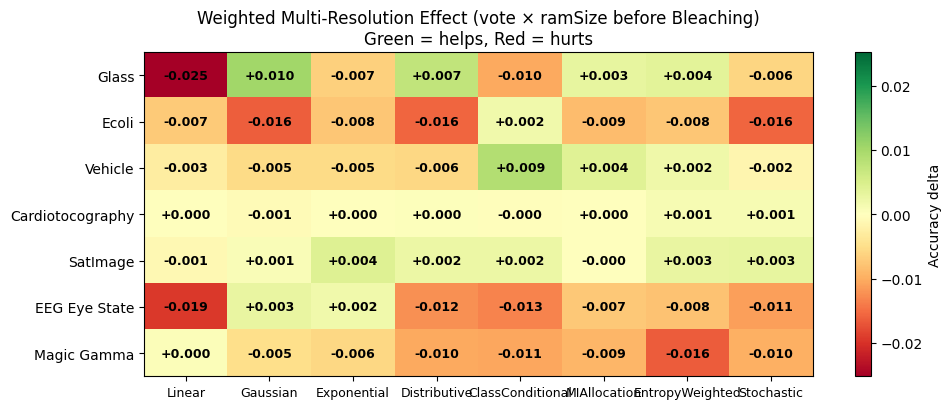

In [8]:
# === 16.2 Weighted Multi-Resolution delta heatmap ===
wmr_ds_names = list(datasets.keys())
delta_data = np.zeros((len(wmr_ds_names), len(MR_THERMO_TYPES)))
for i, ds_name in enumerate(wmr_ds_names):
    for j, tt in enumerate(MR_THERMO_TYPES):
        std_mean = wmr_results[(ds_name, tt, False)][0]
        mr_mean = wmr_results[(ds_name, tt, True)][0]
        delta_data[i, j] = mr_mean - std_mean

fig, ax = plt.subplots(figsize=(10, max(4, len(wmr_ds_names) * 0.6)))
vmax = max(abs(delta_data.min()), abs(delta_data.max()))
if vmax == 0: vmax = 0.01
im = ax.imshow(delta_data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(wmr_ds_names)):
    for j in range(len(MR_THERMO_TYPES)):
        val = delta_data[i, j]
        color = 'white' if abs(val) > 0.05 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(len(MR_THERMO_TYPES)))
ax.set_xticklabels(MR_THERMO_TYPES, fontsize=9)
ax.set_yticks(range(len(wmr_ds_names)))
ax.set_yticklabels(wmr_ds_names)
ax.set_title('Weighted Multi-Resolution Effect (vote × ramSize before Bleaching)\nGreen = helps, Red = hurts', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy delta')
plt.tight_layout(); plt.show()

## 17. WiSARD Ensemble (Multi-Resolution Done Right)

Sections 15-16 showed that mixing different-size RAMs **within** a single WiSARD breaks Bleaching. The correct Random Forest analogy is: keep each WiSARD internally uniform, but run **multiple WiSARDs with different address sizes** and combine by majority vote.

Each WiSARD is a complete, internally-consistent model where Bleaching works correctly. The diversity comes from different resolutions *between* models, not *within* a model. This is exactly how Random Forests work — each tree is complete, diversity comes from the ensemble.

In [5]:
# === 17.1 WiSARD Ensemble: multiple address sizes, majority vote ===
MR_THERMO_TYPES = ['Distributive']

ENSEMBLE_N_MODELS = 25
ensemble_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    ensemble_addrs = get_ensemble_addresses(addr_size, ENSEMBLE_N_MODELS)

    print(f"\n{'='*70}")
    print(f"{ds_name}: addr={addr_size}, ensemble addrs={ensemble_addrs}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    for tt in MR_THERMO_TYPES:
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)
        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)

        ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
        ds_test = wp.DataSet(X_te_bin)

        # Standard: single WiSARD at base address size
        t0 = time.time()
        accs_std = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr_size)
            w.train(ds_train)
            preds = w.classify(ds_test)
            accs_std.append(compute_accuracy(preds, y_te))
        std_mean, std_std = np.mean(accs_std), np.std(accs_std)
        ensemble_results[(ds_name, tt, False)] = (std_mean, std_std)

        # Ensemble: multiple WiSARDs at different address sizes, majority vote
        accs_ens = []
        for run in range(N_RUNS):
            wisards = []
            for addr in ensemble_addrs:
                w = wp.Wisard(addr)
                w.train(ds_train)
                wisards.append(w)
            preds = ensemble_classify(wisards, ds_test)
            accs_ens.append(compute_accuracy(preds, y_te))
        ens_mean, ens_std = np.mean(accs_ens), np.std(accs_ens)
        ensemble_results[(ds_name, tt, True)] = (ens_mean, ens_std)

        elapsed = time.time() - t0
        delta = ens_mean - std_mean
        print(f"  {tt:15s}  Single={std_mean:.4f}  Ensemble={ens_mean:.4f}  delta={delta:+.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: addr=8, ensemble addrs=[4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8]
  Distributive     Single=0.6315  Ensemble=0.6222  delta=-0.0093  (0.2s)

Ecoli: addr=10, ensemble addrs=[5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10]
  Distributive     Single=0.8631  Ensemble=0.8786  delta=+0.0155  (0.2s)

Vehicle: addr=14, ensemble addrs=[7, 7, 7, 7, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 14]
  Distributive     Single=0.7368  Ensemble=0.7561  delta=+0.0193  (0.7s)

Cardiotocography: addr=20, ensemble addrs=[10, 10, 10, 11, 11, 12, 12, 12, 13, 13, 14, 14, 15, 15, 15, 16, 16, 17, 17, 17, 18, 18, 19, 19, 20]
  Distributive     Single=0.9930  Ensemble=0.9981  delta=+0.0051  (5.1s)

SatImage: addr=24, ensemble addrs=[12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 20, 20, 21, 21, 22, 22, 23, 23, 24]
  Distributive     Single=0.8930  Ensemble=0.9064  delta=+0.0134  (9.7s)

EEG Eye State:

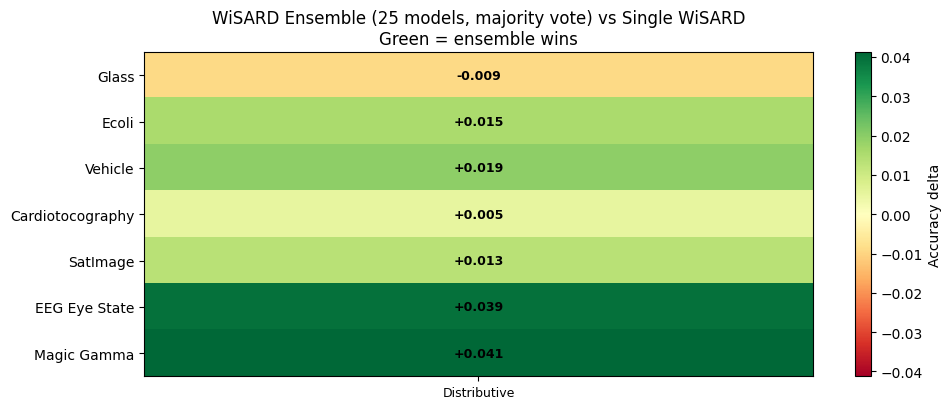

In [6]:
# === 17.2 Ensemble delta heatmap ===
ens_ds_names = list(datasets.keys())
delta_data = np.zeros((len(ens_ds_names), len(MR_THERMO_TYPES)))
for i, ds_name in enumerate(ens_ds_names):
    for j, tt in enumerate(MR_THERMO_TYPES):
        std_mean = ensemble_results[(ds_name, tt, False)][0]
        ens_mean = ensemble_results[(ds_name, tt, True)][0]
        delta_data[i, j] = ens_mean - std_mean

fig, ax = plt.subplots(figsize=(10, max(4, len(ens_ds_names) * 0.6)))
vmax = max(abs(delta_data.min()), abs(delta_data.max()))
if vmax == 0: vmax = 0.01
im = ax.imshow(delta_data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(ens_ds_names)):
    for j in range(len(MR_THERMO_TYPES)):
        val = delta_data[i, j]
        color = 'white' if abs(val) > 0.05 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(range(len(MR_THERMO_TYPES)))
ax.set_xticklabels(MR_THERMO_TYPES, fontsize=9)
ax.set_yticks(range(len(ens_ds_names)))
ax.set_yticklabels(ens_ds_names)
ax.set_title(f'WiSARD Ensemble ({ENSEMBLE_N_MODELS} models, majority vote) vs Single WiSARD\nGreen = ensemble wins', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy delta')
plt.tight_layout(); plt.show()

In [7]:
# === 17.3 Control experiment: ensemble capped at addressSize ===
# Range [addressSize/2, addressSize] — every model is AT or BELOW the single WiSARD.
# If this still wins, the improvement is from diversity, not higher address sizes.

def get_ensemble_addresses_capped(base_addr, n_models=25):
    """Sizes from base/2 to base (no model exceeds the single WiSARD)."""
    min_addr = max(2, base_addr // 2)
    max_addr = base_addr
    if n_models == 1:
        return [base_addr]
    step = (max_addr - min_addr) / (n_models - 1)
    return [int(min_addr + i * step) for i in range(n_models)]

capped_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    capped_addrs = get_ensemble_addresses_capped(addr_size)

    print(f"\n{'='*70}")
    print(f"{ds_name}: single addr={addr_size}, capped ensemble={capped_addrs[0]}-{capped_addrs[-1]} ({len(capped_addrs)} models)")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    # Only test with Distributive for speed (the pattern is consistent across thermometers)
    for tt in ['Distributive']:
        thermo = create_and_fit_thermometer(tt, ts, X_tr,
            address_size=addr_size, y_train=y_tr, validation_size=val_size)
        X_tr_bin = binarize_dataset(X_tr, thermo)
        X_te_bin = binarize_dataset(X_te, thermo)
        ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
        ds_test = wp.DataSet(X_te_bin)

        # Single WiSARD at base address size
        accs_single = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr_size)
            w.train(ds_train)
            preds = w.classify(ds_test)
            accs_single.append(compute_accuracy(preds, y_te))

        # Full ensemble [addr/2, addr*3/2]
        full_addrs = get_ensemble_addresses(addr_size)
        accs_full = []
        for run in range(N_RUNS):
            wisards = [wp.Wisard(a) for a in full_addrs]
            for w in wisards: w.train(ds_train)
            preds = ensemble_classify(wisards, ds_test)
            accs_full.append(compute_accuracy(preds, y_te))

        # Capped ensemble [addr/2, addr] — no model exceeds single
        accs_capped = []
        for run in range(N_RUNS):
            wisards = [wp.Wisard(a) for a in capped_addrs]
            for w in wisards: w.train(ds_train)
            preds = ensemble_classify(wisards, ds_test)
            accs_capped.append(compute_accuracy(preds, y_te))

        # Single WiSARD at max ensemble address (to check if higher addr alone explains it)
        max_full_addr = max(full_addrs)
        accs_max = []
        for run in range(N_RUNS):
            w = wp.Wisard(max_full_addr)
            w.train(ds_train)
            preds = w.classify(ds_test)
            accs_max.append(compute_accuracy(preds, y_te))

        s = np.mean(accs_single)
        f = np.mean(accs_full)
        c = np.mean(accs_capped)
        m = np.mean(accs_max)
        print(f"  Single (addr={addr_size}):          {s:.4f}")
        print(f"  Single (addr={max_full_addr}):         {m:.4f}  (max addr alone)")
        print(f"  Ensemble [{full_addrs[0]}-{full_addrs[-1]}]:  {f:.4f}  delta={f-s:+.4f}")
        print(f"  Ensemble [{capped_addrs[0]}-{capped_addrs[-1]}]:  {c:.4f}  delta={c-s:+.4f}  (capped, no model > single)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: single addr=8, capped ensemble=4-8 (25 models)
  Single (addr=8):          0.7519
  Single (addr=8):         0.7630  (max addr alone)
  Ensemble [4-8]:  0.7778  delta=+0.0259
  Ensemble [4-8]:  0.7833  delta=+0.0315  (capped, no model > single)

Ecoli: single addr=10, capped ensemble=5-10 (25 models)
  Single (addr=10):          0.8250
  Single (addr=10):         0.8440  (max addr alone)
  Ensemble [5-10]:  0.8321  delta=+0.0071
  Ensemble [5-10]:  0.8357  delta=+0.0107  (capped, no model > single)

Vehicle: single addr=14, capped ensemble=7-14 (25 models)
  Single (addr=14):          0.7410
  Single (addr=14):         0.7448  (max addr alone)
  Ensemble [7-14]:  0.7486  delta=+0.0075
  Ensemble [7-14]:  0.7552  delta=+0.0142  (capped, no model > single)

Cardiotocography: single addr=20, capped ensemble=10-20 (25 models)
  Single (addr=20):          0.9981
  Single (addr=20):         0.9991  (max addr alone)
  Ensemble [10-20]:  1.0000  delta=+0.0019
  Ensemble [10-20]:  1.000

In [8]:
# === 17.4 Ensemble hyperparameter sweep: min address size & number of models ===
# Always capped at addressSize (max = base). Sweep min_ratio and n_models.
# Uses Distributive thermometer only.

MIN_RATIOS = [0.25, 0.5, 0.75, 1.0]  # min addr as fraction of base (1.0 = all same size = baseline)
N_MODELS_LIST = [3, 5, 10, 25]

sweep_results = {}  # (dataset, min_ratio, n_models) -> (mean, std)
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: base addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    for min_ratio in MIN_RATIOS:
        for n_models in N_MODELS_LIST:
            min_addr = max(2, int(addr_size * min_ratio))
            max_addr = addr_size

            if n_models == 1 or min_addr == max_addr:
                addrs = [addr_size] * n_models
            else:
                step = (max_addr - min_addr) / (n_models - 1)
                addrs = [int(min_addr + i * step) for i in range(n_models)]

            accs = []
            for run in range(N_RUNS):
                wisards = [wp.Wisard(a) for a in addrs]
                for w in wisards:
                    w.train(ds_train)
                preds = ensemble_classify(wisards, ds_test)
                accs.append(compute_accuracy(preds, y_te))

            mean_acc, std_acc = np.mean(accs), np.std(accs)
            sweep_results[(ds_name, min_ratio, n_models)] = (mean_acc, std_acc)

    # Print summary for this dataset
    print(f"  {'min_ratio':>10s}", end='')
    for n in N_MODELS_LIST:
        print(f"  n={n:2d}", end='')
    print()
    for mr in MIN_RATIOS:
        print(f"  {mr:>10.2f}", end='')
        for n in N_MODELS_LIST:
            m = sweep_results[(ds_name, mr, n)][0]
            print(f"  {m:.4f}", end='')
        print()

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: base addr=8
   min_ratio  n= 3  n= 5  n=10  n=25
        0.25  0.6389  0.6278  0.6389  0.6611
        0.50  0.6611  0.6648  0.6593  0.6593
        0.75  0.6593  0.6648  0.6611  0.6593
        1.00  0.6537  0.6593  0.6574  0.6463

Ecoli: base addr=10
   min_ratio  n= 3  n= 5  n=10  n=25
        0.25  0.8488  0.8440  0.8548  0.8607
        0.50  0.8560  0.8440  0.8464  0.8464
        0.75  0.8393  0.8405  0.8488  0.8464
        1.00  0.8393  0.8464  0.8381  0.8345

Vehicle: base addr=14
   min_ratio  n= 3  n= 5  n=10  n=25
        0.25  0.7429  0.7278  0.7373  0.7373
        0.50  0.7283  0.7358  0.7311  0.7354
        0.75  0.7349  0.7349  0.7302  0.7387
        1.00  0.7321  0.7307  0.7344  0.7335

Cardiotocography: base addr=20
   min_ratio  n= 3  n= 5  n=10  n=25
        0.25  1.0000  1.0000  1.0000  1.0000
        0.50  0.9998  0.9998  1.0000  1.0000
        0.75  0.9998  0.9998  0.9996  1.0000
        1.00  0.9991  0.9989  0.9989  0.9996

SatImage: base addr=24
   min_ratio

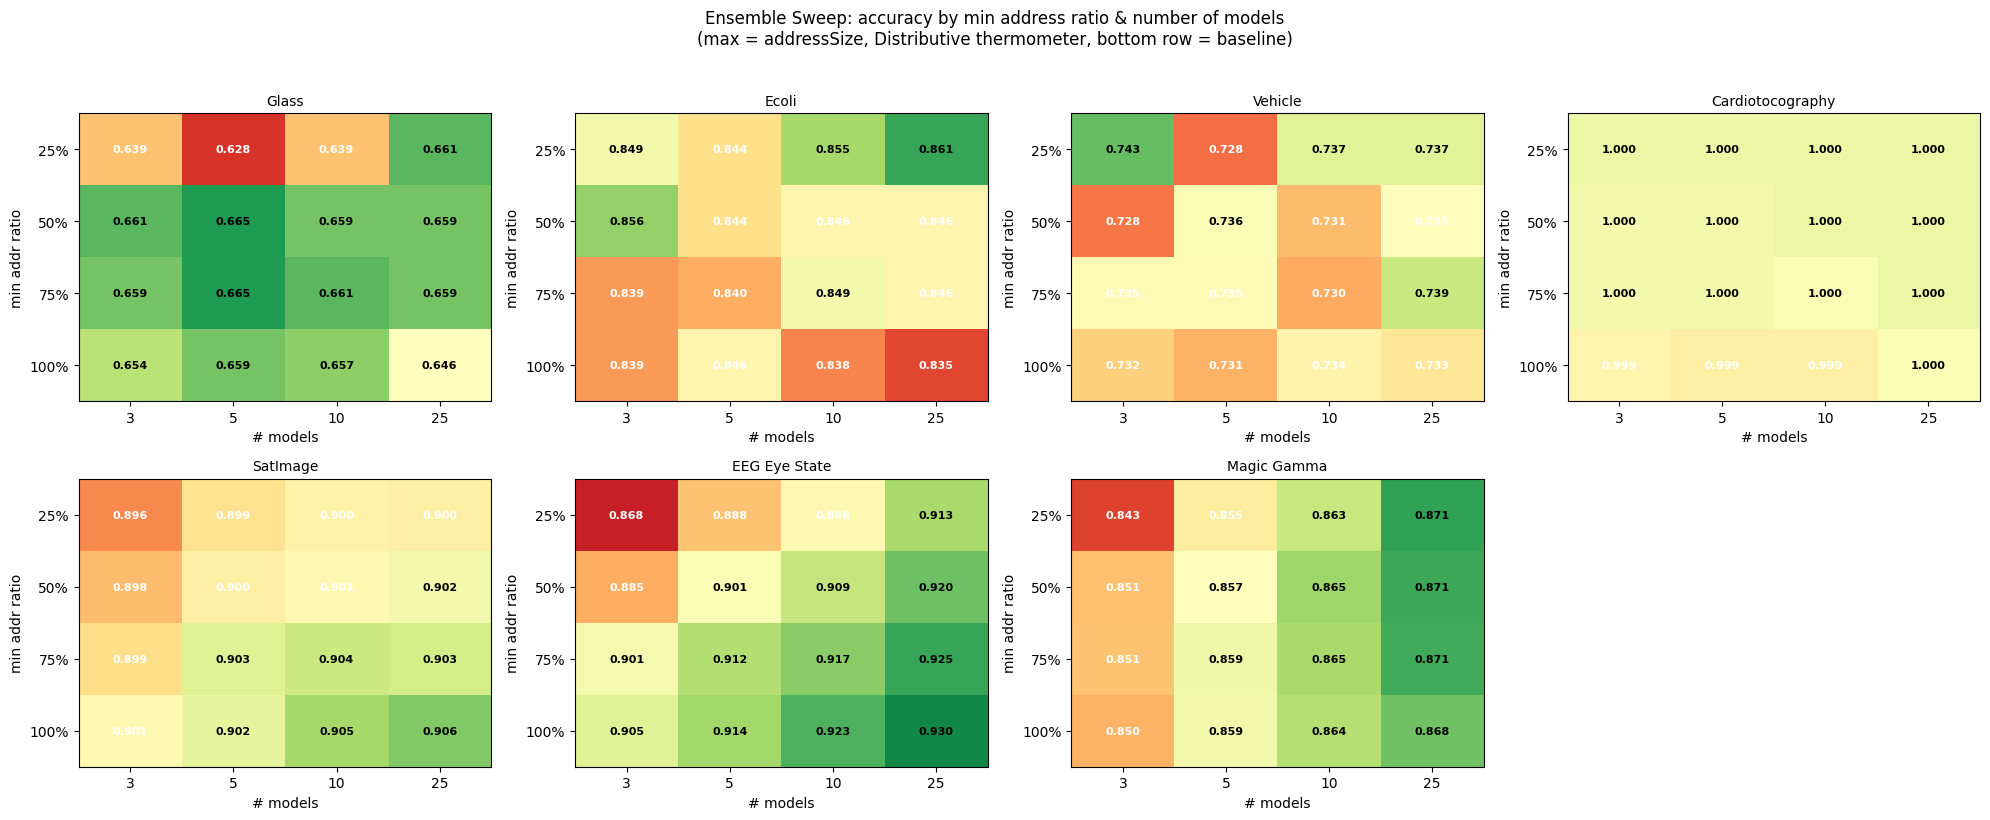

In [9]:
# === 17.5 Sweep heatmaps: one per dataset ===
# Rows = min_ratio, Columns = n_models. Color = accuracy.
# min_ratio=1.0 row is the baseline (all models = same addr = standard WiSARD with voting).

sweep_ds_names = list(datasets.keys())
n_rows = 2
n_cols = (len(sweep_ds_names) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flat

for idx, ds_name in enumerate(sweep_ds_names):
    ax = axes[idx]
    matrix = np.zeros((len(MIN_RATIOS), len(N_MODELS_LIST)))
    for i, mr in enumerate(MIN_RATIOS):
        for j, n in enumerate(N_MODELS_LIST):
            matrix[i, j] = sweep_results[(ds_name, mr, n)][0]

    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto',
                   vmin=matrix.min() - 0.005, vmax=matrix.max() + 0.005)
    for i in range(len(MIN_RATIOS)):
        for j in range(len(N_MODELS_LIST)):
            val = matrix[i, j]
            color = 'white' if val < (matrix.min() + matrix.max()) / 2 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                    color=color, fontweight='bold')

    ax.set_xticks(range(len(N_MODELS_LIST)))
    ax.set_xticklabels(N_MODELS_LIST)
    ax.set_yticks(range(len(MIN_RATIOS)))
    ax.set_yticklabels([f'{mr:.0%}' for mr in MIN_RATIOS])
    ax.set_xlabel('# models')
    ax.set_ylabel('min addr ratio')
    ax.set_title(ds_name, fontsize=10)

for idx in range(len(sweep_ds_names), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Ensemble Sweep: accuracy by min address ratio & number of models\n(max = addressSize, Distributive thermometer, bottom row = baseline)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# === 17.6 Ensemble size sweep: accuracy vs number of WiSARDs ===
# All models use the same addressSize (min_ratio=1.0). Only the count varies.
# This isolates the effect of random-mapping diversity.

ENSEMBLE_SIZES = [1, 5, 10, 15, 25, 50, 100]

size_sweep_results = {}  # (dataset, n_models) -> (mean, std)
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"{ds_name} (addr={addr_size}): ", end='', flush=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    for n_models in ENSEMBLE_SIZES:
        accs = []
        for run in range(N_RUNS):
            wisards = [wp.Wisard(addr_size) for _ in range(n_models)]
            for w in wisards:
                w.train(ds_train)
            if n_models == 1:
                preds = wisards[0].classify(ds_test)
            else:
                preds = ensemble_classify(wisards, ds_test)
            accs.append(compute_accuracy(preds, y_te))

        mean_acc, std_acc = np.mean(accs), np.std(accs)
        size_sweep_results[(ds_name, n_models)] = (mean_acc, std_acc)
        print(f"n={n_models}:{mean_acc:.4f} ", end='', flush=True)
    print()

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")

Glass (addr=8): n=1:0.7056 n=5:0.6889 n=10:0.6889 n=15:0.6870 n=25:0.6870 n=50:0.6852 n=100:0.6852 
Ecoli (addr=10): n=1:0.8298 n=5:0.8226 n=10:0.8286 n=15:0.8345 n=25:0.8333 n=50:0.8357 n=100:0.8321 
Vehicle (addr=14): n=1:0.7316 n=5:0.7392 n=10:0.7472 n=15:0.7458 n=25:0.7434 n=50:0.7415 n=100:0.7415 
Cardiotocography (addr=20): n=1:0.9987 n=5:1.0000 n=10:1.0000 n=15:1.0000 n=25:1.0000 n=50:1.0000 n=100:1.0000 
SatImage (addr=24): n=1:0.8971 n=5:0.9039 n=10:0.9040 n=15:0.9045 n=25:0.9044 n=50:0.9053 n=100:0.9056 
EEG Eye State (addr=28): n=1:0.8839 n=5:0.9246 n=10:0.9314 n=15:0.9356 n=25:0.9386 n=50:0.9409 n=100:0.9413 
Magic Gamma (addr=28): n=1:0.8319 n=5:0.8598 n=10:0.8667 n=15:0.8708 n=25:0.8714 n=50:0.8722 n=100:0.8728 

Done! Total time: 3m 1.5s


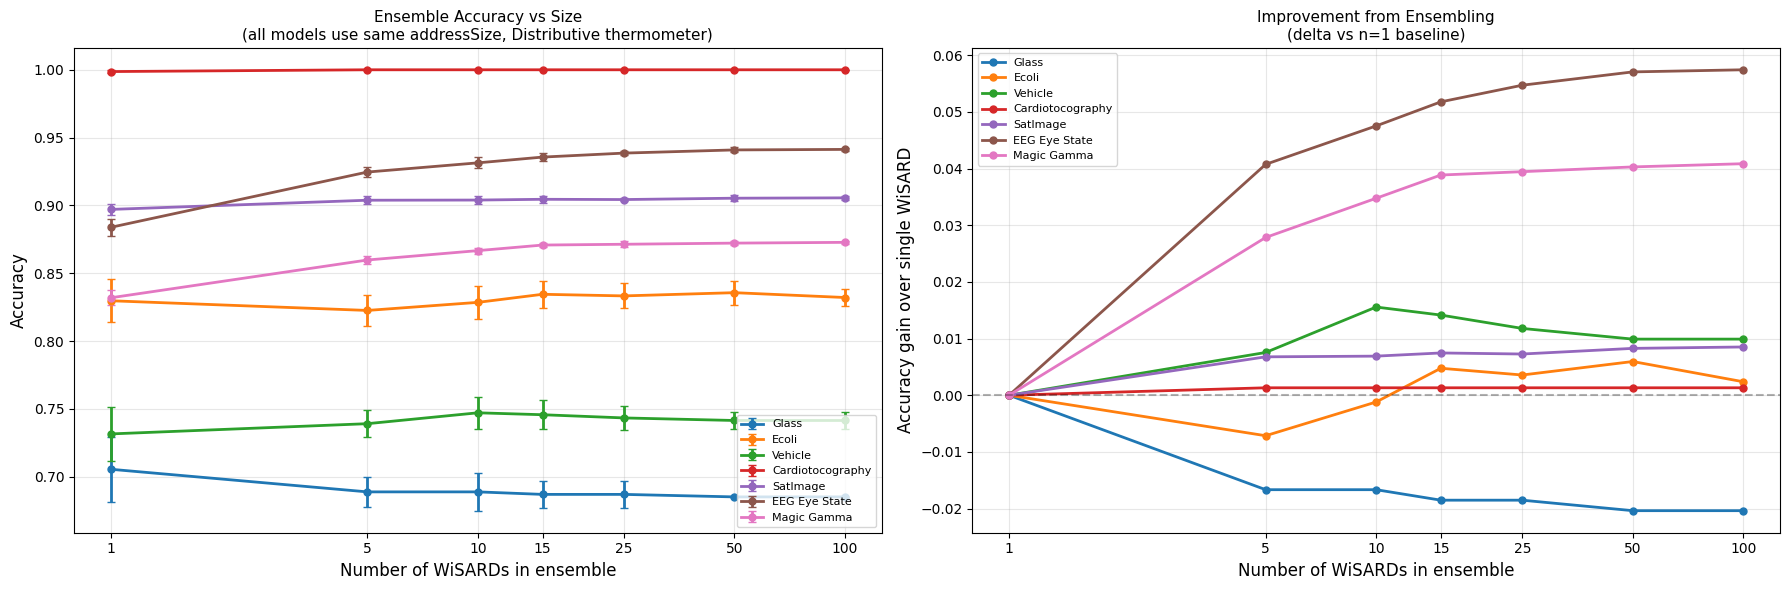

             Dataset  n=1 (baseline)  n=50 (best)  gain
                                                         
               Glass          0.7056       0.6852  -0.0204
               Ecoli          0.8298       0.8357  +0.0060
             Vehicle          0.7316       0.7415  +0.0099
    Cardiotocography          0.9987       1.0000  +0.0013
            SatImage          0.8971       0.9053  +0.0083
       EEG Eye State          0.8839       0.9409  +0.0571
         Magic Gamma          0.8319       0.8722  +0.0403


In [11]:
# === 17.7 Visualization: accuracy vs ensemble size ===
# One line per dataset. x-axis = number of WiSARDs, y-axis = accuracy.
# n=1 is the baseline (single WiSARD). Shows how majority vote improves with more models.

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cmap = plt.colormaps.get_cmap('tab10')
sweep_ds_names = list(datasets.keys())

# Left: absolute accuracy
ax = axes[0]
for i, ds_name in enumerate(sweep_ds_names):
    means = [size_sweep_results[(ds_name, n)][0] for n in ENSEMBLE_SIZES]
    stds = [size_sweep_results[(ds_name, n)][1] for n in ENSEMBLE_SIZES]
    ax.errorbar(ENSEMBLE_SIZES, means, yerr=stds, marker='o', capsize=3,
                label=ds_name, color=cmap(i), linewidth=2, markersize=5)

ax.set_xlabel('Number of WiSARDs in ensemble', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Ensemble Accuracy vs Size\n(all models use same addressSize, Distributive thermometer)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.set_xscale('log', base=2)
ax.set_xticks(ENSEMBLE_SIZES)
ax.set_xticklabels(ENSEMBLE_SIZES)
ax.grid(True, alpha=0.3)

# Right: relative improvement over single WiSARD (n=1)
ax = axes[1]
for i, ds_name in enumerate(sweep_ds_names):
    baseline = size_sweep_results[(ds_name, 1)][0]
    deltas = [size_sweep_results[(ds_name, n)][0] - baseline for n in ENSEMBLE_SIZES]
    ax.plot(ENSEMBLE_SIZES, deltas, marker='o', label=ds_name, color=cmap(i), linewidth=2, markersize=5)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Number of WiSARDs in ensemble', fontsize=12)
ax.set_ylabel('Accuracy gain over single WiSARD', fontsize=12)
ax.set_title('Improvement from Ensembling\n(delta vs n=1 baseline)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.set_xscale('log', base=2)
ax.set_xticks(ENSEMBLE_SIZES)
ax.set_xticklabels(ENSEMBLE_SIZES)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Dataset':>20s}  n=1 (baseline)  n=50 (best)  gain")
print(f"{'':>20s}  {'':>14s}  {'':>11s}  {'':>6s}")
for ds_name in sweep_ds_names:
    b = size_sweep_results[(ds_name, 1)][0]
    best = size_sweep_results[(ds_name, 50)][0]
    print(f"{ds_name:>20s}  {b:>14.4f}  {best:>11.4f}  {best-b:>+6.4f}")

## 18. Supervised Mapping

The ensemble results (Section 17) showed that mapping quality is a major source of accuracy variance — some random bit-to-RAM assignments are much better than others. Instead of relying on random luck (or averaging over many random mappings), we try to **construct a good mapping directly**.

**Algorithm** (per class discriminator):
1. Compute MI between each input bit and the class label ("is this class?")
2. Assign bits to RAMs greedily: each RAM starts with the highest-MI unassigned bit, then fills remaining slots with bits that are informative but uncorrelated with bits already in that RAM
3. Result: each RAM gets a maximally informative AND diverse set of bits

This is **supervised** (uses labels), **deterministic** (no randomness), and **per-class** (each discriminator gets its own optimized mapping). No C++ changes — uses the existing `mapping=` parameter.

In [9]:
# === 18.1 Supervised Mapping: implementation + experiment ===

def compute_bit_correlation(X_bin, n_bits):
    """Compute absolute pairwise correlation between input bits (sampled for speed)."""
    n_samples = len(X_bin)
    # Sample for speed on large datasets
    max_samples = min(n_samples, 2000)
    idx = np.random.choice(n_samples, max_samples, replace=False)
    bit_matrix = np.array([X_bin[i] for i in idx], dtype=float)  # (samples, bits)
    # Use numpy correlation
    stds = bit_matrix.std(axis=0)
    stds[stds == 0] = 1  # avoid division by zero
    normalized = (bit_matrix - bit_matrix.mean(axis=0)) / stds
    corr = np.abs(normalized.T @ normalized / max_samples)
    np.fill_diagonal(corr, 0)
    return corr

def compute_supervised_mapping(X_bin, y, address_size):
    """Compute a supervised mapping: one optimized mapping per class."""
    n_bits = len(X_bin[0])
    classes = sorted(set(y))

    # Precompute bit correlation matrix (shared across classes)
    corr = compute_bit_correlation(X_bin, n_bits)

    mapping = {}
    for cls in classes:
        # MI between each bit and this class
        mi = compute_bit_mi(X_bin, y, cls)

        # Greedy assignment: build RAMs one at a time
        assigned = set()
        class_mapping = []
        n_rams = n_bits // address_size
        if n_bits % address_size != 0:
            n_rams += 1

        for ram_idx in range(n_rams):
            ram_bits = []
            remaining_size = min(address_size, n_bits - len(assigned))

            # Pick first bit: highest MI among unassigned
            candidates = [b for b in range(n_bits) if b not in assigned]
            if not candidates:
                break

            # Sort by MI descending
            candidates.sort(key=lambda b: mi[b], reverse=True)
            first_bit = candidates[0]
            ram_bits.append(first_bit)
            assigned.add(first_bit)

            # Fill remaining slots: high MI, low correlation with already-selected
            for _ in range(remaining_size - 1):
                candidates = [b for b in range(n_bits) if b not in assigned]
                if not candidates:
                    break

                # Score = MI - mean_correlation_with_selected
                scores = []
                for b in candidates:
                    avg_corr = np.mean([corr[b, s] for s in ram_bits])
                    score = mi[b] - avg_corr
                    scores.append((score, b))
                scores.sort(reverse=True)
                best_bit = scores[0][1]
                ram_bits.append(best_bit)
                assigned.add(best_bit)

            class_mapping.append(ram_bits)

        mapping[cls] = class_mapping

    return mapping

# === Run experiment ===
sup_map_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat, addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)

    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Standard: random mapping
    t0 = time.time()
    accs_std = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size)
        w.train(ds_train)
        preds = w.classify(ds_test)
        accs_std.append(compute_accuracy(preds, y_te))
    std_time = time.time() - t0

    # Supervised mapping
    t0 = time.time()
    sup_mapping = compute_supervised_mapping(X_tr_bin, y_tr.tolist(), addr_size)
    mapping_time = time.time() - t0

    accs_sup = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size, mapping=sup_mapping)
        w.train(ds_train)
        preds = w.classify(ds_test)
        accs_sup.append(compute_accuracy(preds, y_te))

    # Ensemble (n=25) for reference
    accs_ens = []
    for run in range(N_RUNS):
        wisards = [wp.Wisard(addr_size) for _ in range(25)]
        for w in wisards: w.train(ds_train)
        preds = ensemble_classify(wisards, ds_test)
        accs_ens.append(compute_accuracy(preds, y_te))

    s = np.mean(accs_std)
    m = np.mean(accs_sup)
    e = np.mean(accs_ens)
    sup_map_results[(ds_name, 'Random')] = (s, np.std(accs_std))
    sup_map_results[(ds_name, 'Supervised')] = (m, np.std(accs_sup))
    sup_map_results[(ds_name, 'Ensemble(25)')] = (e, np.std(accs_ens))

    print(f"  Random mapping:     {s:.4f} +/- {np.std(accs_std):.4f}  ({std_time:.1f}s)")
    print(f"  Supervised mapping: {m:.4f} +/- {np.std(accs_sup):.4f}  (mapping computed in {mapping_time:.1f}s)")
    print(f"  Ensemble (n=25):    {e:.4f} +/- {np.std(accs_ens):.4f}  (reference)")
    print(f"  Supervised vs Random: {m-s:+.4f}")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat, addr=8
  Random mapping:     0.7926 +/- 0.0231  (0.0s)
  Supervised mapping: 0.8148 +/- 0.0000  (mapping computed in 0.5s)
  Ensemble (n=25):    0.8222 +/- 0.0091  (reference)
  Supervised vs Random: +0.0222

Ecoli: 336 samples, 7 feat, addr=10
  Random mapping:     0.8988 +/- 0.0179  (0.0s)
  Supervised mapping: 0.9286 +/- 0.0000  (mapping computed in 0.4s)
  Ensemble (n=25):    0.9226 +/- 0.0143  (reference)
  Supervised vs Random: +0.0298

Vehicle: 846 samples, 18 feat, addr=14


KeyboardInterrupt: 

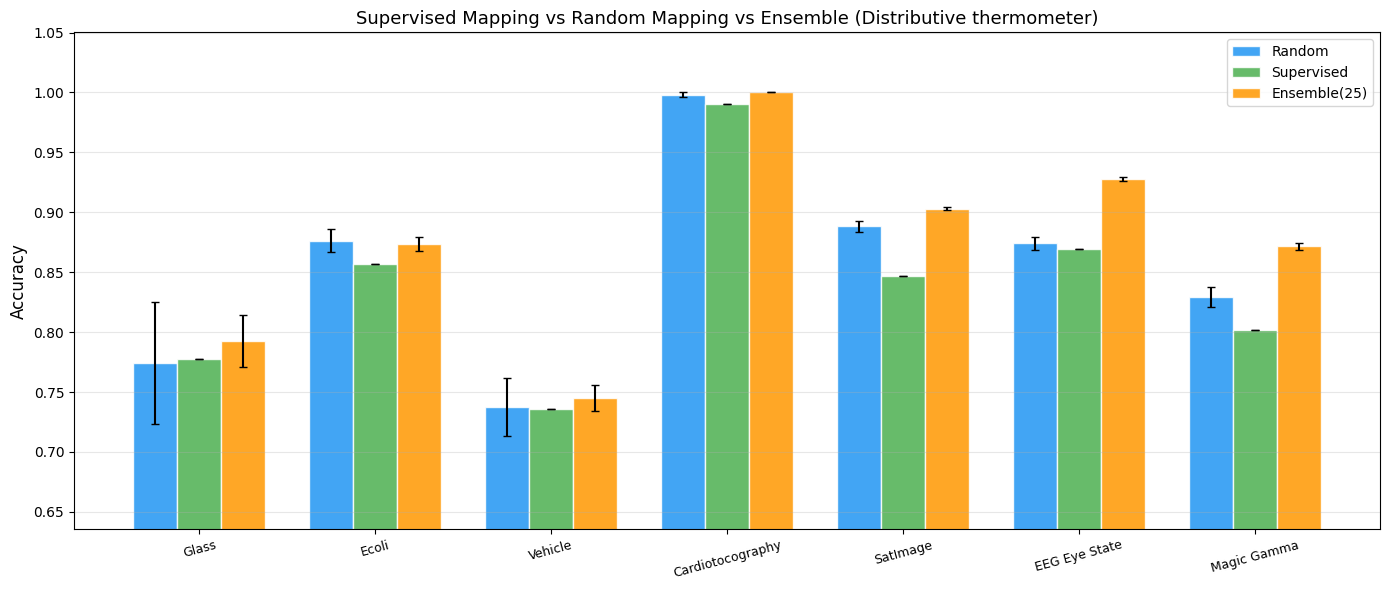


             Dataset    Random  Supervised    Ensemble   Sup-Rnd
               Glass    0.7741      0.7778      0.7926   +0.0037
               Ecoli    0.8762      0.8571      0.8738   -0.0190
             Vehicle    0.7373      0.7358      0.7453   -0.0014
    Cardiotocography    0.9981      0.9906      1.0000   -0.0075
            SatImage    0.8882      0.8470      0.9029   -0.0412
       EEG Eye State    0.8741      0.8697      0.9278   -0.0044
         Magic Gamma    0.8293      0.8021      0.8716   -0.0272


In [6]:
# === 18.2 Visualization: Random vs Supervised vs Ensemble ===

methods = ['Random', 'Supervised', 'Ensemble(25)']
colors_map = {'Random': '#2196F3', 'Supervised': '#4CAF50', 'Ensemble(25)': '#FF9800'}
sm_ds_names = list(datasets.keys())

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(sm_ds_names))
width = 0.25

for i, method in enumerate(methods):
    means = [sup_map_results[(ds, method)][0] for ds in sm_ds_names]
    stds = [sup_map_results[(ds, method)][1] for ds in sm_ds_names]
    bars = ax.bar(x + i * width, means, width, yerr=stds, label=method,
                  color=colors_map[method], edgecolor='white', capsize=3, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(sm_ds_names, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Supervised Mapping vs Random Mapping vs Ensemble (Distributive thermometer)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(bottom=max(0, min(sup_map_results[(ds, m)][0] for ds in sm_ds_names for m in methods) - 0.1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Delta summary
print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'Supervised':>10s}  {'Ensemble':>10s}  {'Sup-Rnd':>8s}")
for ds in sm_ds_names:
    r = sup_map_results[(ds, 'Random')][0]
    s = sup_map_results[(ds, 'Supervised')][0]
    e = sup_map_results[(ds, 'Ensemble(25)')][0]
    print(f"{ds:>20s}  {r:>8.4f}  {s:>10.4f}  {e:>10.4f}  {s-r:>+8.4f}")

In [7]:
# === 18.3 Supervised Mapping v2: Round-Robin MI Distribution ===
# Fix: instead of greedy (best bits → first RAMs), deal bits like cards.
# Sort all bits by MI, then distribute round-robin across RAMs.
# Each RAM gets an equal mix of high-MI and low-MI bits. No correlation avoidance.

# === Run experiment ===
sup_map_v2_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat, addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Random mapping (baseline)
    accs_rnd = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size)
        w.train(ds_train)
        preds = w.classify(ds_test)
        accs_rnd.append(compute_accuracy(preds, y_te))

    # v1: Greedy MI (from 18.1)
    v1_mapping = compute_supervised_mapping(X_tr_bin, y_tr.tolist(), addr_size)
    w_v1 = wp.Wisard(addr_size, mapping=v1_mapping)
    w_v1.train(ds_train)
    acc_v1 = compute_accuracy(w_v1.classify(ds_test), y_te)

    # v2: Round-robin MI
    v2_mapping = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)
    w_v2 = wp.Wisard(addr_size, mapping=v2_mapping)
    w_v2.train(ds_train)
    acc_v2 = compute_accuracy(w_v2.classify(ds_test), y_te)

    # Ensemble (n=25) for reference
    accs_ens = []
    for run in range(N_RUNS):
        wisards = [wp.Wisard(addr_size) for _ in range(25)]
        for w in wisards: w.train(ds_train)
        preds = ensemble_classify(wisards, ds_test)
        accs_ens.append(compute_accuracy(preds, y_te))

    r = np.mean(accs_rnd)
    e = np.mean(accs_ens)
    sup_map_v2_results[(ds_name, 'Random')] = (r, np.std(accs_rnd))
    sup_map_v2_results[(ds_name, 'Greedy MI')] = (acc_v1, 0.0)
    sup_map_v2_results[(ds_name, 'RoundRobin MI')] = (acc_v2, 0.0)
    sup_map_v2_results[(ds_name, 'Ensemble(25)')] = (e, np.std(accs_ens))

    print(f"  Random:          {r:.4f} +/- {np.std(accs_rnd):.4f}")
    print(f"  Greedy MI (v1):  {acc_v1:.4f}  delta={acc_v1-r:+.4f}")
    print(f"  RoundRobin (v2): {acc_v2:.4f}  delta={acc_v2-r:+.4f}")
    print(f"  Ensemble (n=25): {e:.4f}  delta={e-r:+.4f}  (reference)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat, addr=8
  Random:          0.7167 +/- 0.0204
  Greedy MI (v1):  0.6852  delta=-0.0315
  RoundRobin (v2): 0.7037  delta=-0.0130
  Ensemble (n=25): 0.7500  delta=+0.0333  (reference)

Ecoli: 336 samples, 7 feat, addr=10
  Random:          0.8512 +/- 0.0080
  Greedy MI (v1):  0.8452  delta=-0.0060
  RoundRobin (v2): 0.8571  delta=+0.0060
  Ensemble (n=25): 0.8464  delta=-0.0048  (reference)

Vehicle: 846 samples, 18 feat, addr=14
  Random:          0.7288 +/- 0.0169
  Greedy MI (v1):  0.7170  delta=-0.0118
  RoundRobin (v2): 0.7075  delta=-0.0212
  Ensemble (n=25): 0.7142  delta=-0.0146  (reference)

Cardiotocography: 2126 samples, 35 feat, addr=20
  Random:          0.9942 +/- 0.0018
  Greedy MI (v1):  0.9793  delta=-0.0148
  RoundRobin (v2): 0.9981  delta=+0.0039
  Ensemble (n=25): 0.9959  delta=+0.0017  (reference)

SatImage: 6430 samples, 36 feat, addr=24
  Random:          0.8893 +/- 0.0049
  Greedy MI (v1):  0.8532  delta=-0.0361
  RoundRobin (v2): 0.8887

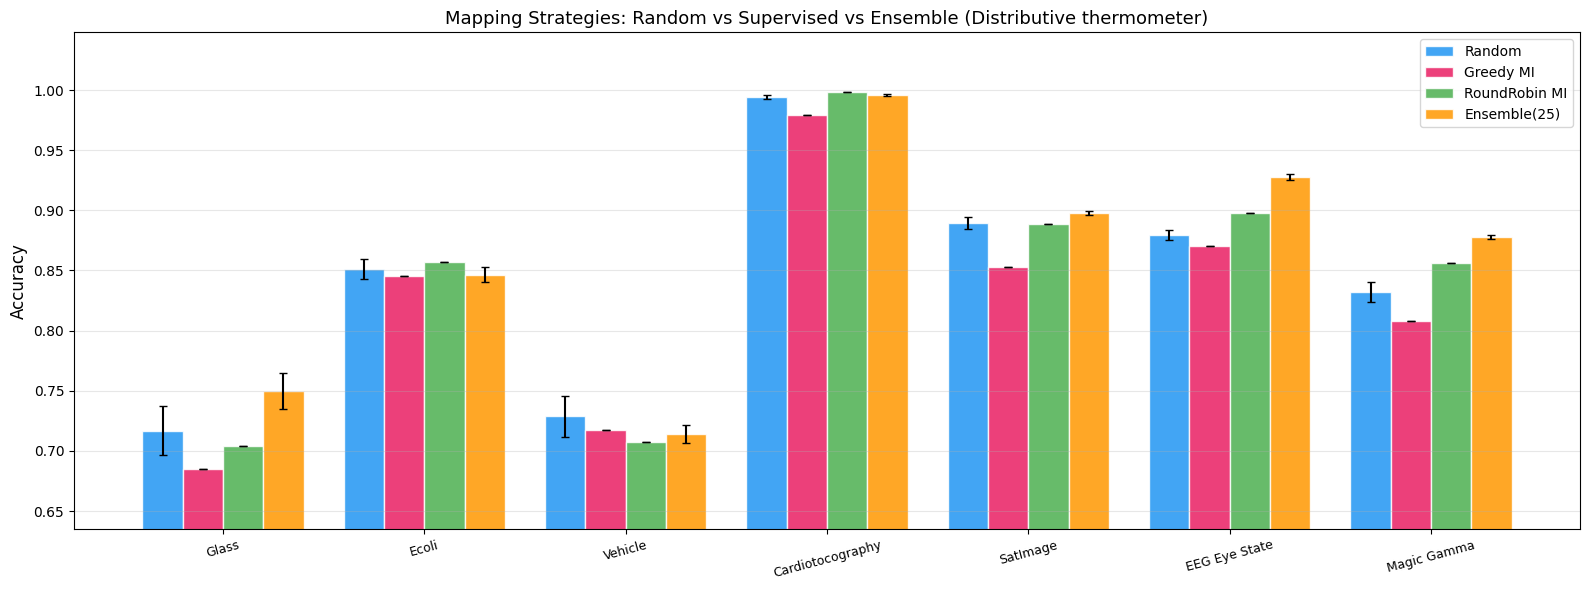


             Dataset    Random    Greedy  RndRobin  Ensemble  v1 delta  v2 delta
               Glass    0.7167    0.6852    0.7037    0.7500   -0.0315   -0.0130
               Ecoli    0.8512    0.8452    0.8571    0.8464   -0.0060   +0.0060
             Vehicle    0.7288    0.7170    0.7075    0.7142   -0.0118   -0.0212
    Cardiotocography    0.9942    0.9793    0.9981    0.9959   -0.0148   +0.0039
            SatImage    0.8893    0.8532    0.8887    0.8978   -0.0361   -0.0006
       EEG Eye State    0.8797    0.8708    0.8977    0.9276   -0.0089   +0.0181
         Magic Gamma    0.8320    0.8082    0.8564    0.8780   -0.0238   +0.0244


In [8]:
# === 18.4 Visualization: Random vs Greedy MI vs RoundRobin MI vs Ensemble ===

v2_methods = ['Random', 'Greedy MI', 'RoundRobin MI', 'Ensemble(25)']
v2_colors = {'Random': '#2196F3', 'Greedy MI': '#E91E63', 'RoundRobin MI': '#4CAF50', 'Ensemble(25)': '#FF9800'}
v2_ds_names = list(datasets.keys())

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(v2_ds_names))
width = 0.2

for i, method in enumerate(v2_methods):
    means = [sup_map_v2_results[(ds, method)][0] for ds in v2_ds_names]
    stds = [sup_map_v2_results[(ds, method)][1] for ds in v2_ds_names]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=v2_colors[method], edgecolor='white', capsize=3, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(v2_ds_names, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Mapping Strategies: Random vs Supervised vs Ensemble (Distributive thermometer)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(bottom=max(0, min(sup_map_v2_results[(ds, m)][0] for ds in v2_ds_names for m in v2_methods) - 0.05))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'Greedy':>8s}  {'RndRobin':>8s}  {'Ensemble':>8s}  {'v1 delta':>8s}  {'v2 delta':>8s}")
for ds in v2_ds_names:
    r = sup_map_v2_results[(ds, 'Random')][0]
    v1 = sup_map_v2_results[(ds, 'Greedy MI')][0]
    v2 = sup_map_v2_results[(ds, 'RoundRobin MI')][0]
    e = sup_map_v2_results[(ds, 'Ensemble(25)')][0]
    print(f"{ds:>20s}  {r:>8.4f}  {v1:>8.4f}  {v2:>8.4f}  {e:>8.4f}  {v1-r:>+8.4f}  {v2-r:>+8.4f}")

In [9]:
# === 18.5 Supervised Mapping v3: Feature-Balanced ===
# Ensure each RAM gets bits from ALL features (not just high-MI bits from a few).
# Deal: cycle through features, each giving its next-best bit, round-robin across RAMs.

def compute_supervised_mapping_v3(X_bin, y, address_size, thermo_size=32):
    """Feature-balanced: each RAM gets bits from as many features as possible."""
    n_bits = len(X_bin[0])
    classes = sorted(set(y))
    n_features = n_bits // thermo_size
    if n_bits % thermo_size != 0:
        n_features += 1

    mapping = {}
    for cls in classes:
        mi = compute_bit_mi(X_bin, y, cls)

        n_rams = n_bits // address_size
        if n_bits % address_size != 0:
            n_rams += 1

        # For each feature, sort its bits by MI descending
        feature_queues = []
        for f in range(n_features):
            start = f * thermo_size
            end = min(start + thermo_size, n_bits)
            bits = list(range(start, end))
            bits.sort(key=lambda b: mi[b], reverse=True)
            feature_queues.append(list(bits))  # queue: best first

        # Deal: cycle features, each gives one bit, round-robin across RAMs
        ram_bits = [[] for _ in range(n_rams)]
        ram_idx = 0
        round_num = 0
        max_rounds = max(len(q) for q in feature_queues)

        while round_num < max_rounds:
            for f in range(n_features):
                if round_num < len(feature_queues[f]):
                    target_ram = ram_idx % n_rams
                    ram_bits[target_ram].append(feature_queues[f][round_num])
                    ram_idx += 1
            round_num += 1

        mapping[cls] = [rb for rb in ram_bits if len(rb) > 0]

    return mapping

# === Run experiment ===
sup_map_v3_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {X_ds.shape[1]} feat, addr={addr_size}, thermo={ts}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Random
    accs_rnd = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size)
        w.train(ds_train)
        accs_rnd.append(compute_accuracy(w.classify(ds_test), y_te))

    # v2: RoundRobin MI
    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)
    w_v2 = wp.Wisard(addr_size, mapping=v2_map)
    w_v2.train(ds_train)
    acc_v2 = compute_accuracy(w_v2.classify(ds_test), y_te)

    # v3: Feature-Balanced
    v3_map = compute_supervised_mapping_v3(X_tr_bin, y_tr.tolist(), addr_size, ts)
    w_v3 = wp.Wisard(addr_size, mapping=v3_map)
    w_v3.train(ds_train)
    acc_v3 = compute_accuracy(w_v3.classify(ds_test), y_te)

    # Ensemble
    accs_ens = []
    for run in range(N_RUNS):
        wisards = [wp.Wisard(addr_size) for _ in range(25)]
        for w in wisards: w.train(ds_train)
        accs_ens.append(compute_accuracy(ensemble_classify(wisards, ds_test), y_te))

    r = np.mean(accs_rnd)
    e = np.mean(accs_ens)
    sup_map_v3_results[(ds_name, 'Random')] = (r, np.std(accs_rnd))
    sup_map_v3_results[(ds_name, 'RoundRobin MI')] = (acc_v2, 0.0)
    sup_map_v3_results[(ds_name, 'FeatureBalanced')] = (acc_v3, 0.0)
    sup_map_v3_results[(ds_name, 'Ensemble(25)')] = (e, np.std(accs_ens))

    # Show bits-per-feature distribution for one class
    sample_ram = v3_map[sorted(set(y_tr.tolist()))[0]][0]
    features_in_ram = [b // ts for b in sample_ram]
    n_feat_in_ram = len(set(features_in_ram))

    print(f"  Random:            {r:.4f} +/- {np.std(accs_rnd):.4f}")
    print(f"  RoundRobin MI (v2):{acc_v2:.4f}  delta={acc_v2-r:+.4f}")
    print(f"  FeatureBalanced(v3):{acc_v3:.4f}  delta={acc_v3-r:+.4f}")
    print(f"  Ensemble (n=25):   {e:.4f}  delta={e-r:+.4f}  (reference)")
    print(f"  v3 RAM[0]: {len(sample_ram)} bits from {n_feat_in_ram}/{X_ds.shape[1]} features")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat, addr=8, thermo=32
  Random:            0.7111 +/- 0.0381
  RoundRobin MI (v2):0.7407  delta=+0.0296
  FeatureBalanced(v3):0.6111  delta=-0.1000
  Ensemble (n=25):   0.7352  delta=+0.0241  (reference)
  v3 RAM[0]: 8 bits from 1/9 features

Ecoli: 336 samples, 7 feat, addr=10, thermo=32
  Random:            0.8690 +/- 0.0141
  RoundRobin MI (v2):0.8452  delta=-0.0238
  FeatureBalanced(v3):0.9048  delta=+0.0357
  Ensemble (n=25):   0.8810  delta=+0.0119  (reference)
  v3 RAM[0]: 10 bits from 7/7 features

Vehicle: 846 samples, 18 feat, addr=14, thermo=32
  Random:            0.7179 +/- 0.0117
  RoundRobin MI (v2):0.7500  delta=+0.0321
  FeatureBalanced(v3):0.6840  delta=-0.0340
  Ensemble (n=25):   0.7212  delta=+0.0033  (reference)
  v3 RAM[0]: 14 bits from 3/18 features

Cardiotocography: 2126 samples, 35 feat, addr=20, thermo=32
  Random:            0.9955 +/- 0.0028
  RoundRobin MI (v2):0.9906  delta=-0.0049
  FeatureBalanced(v3):0.9718  delta=-0.0237
  En

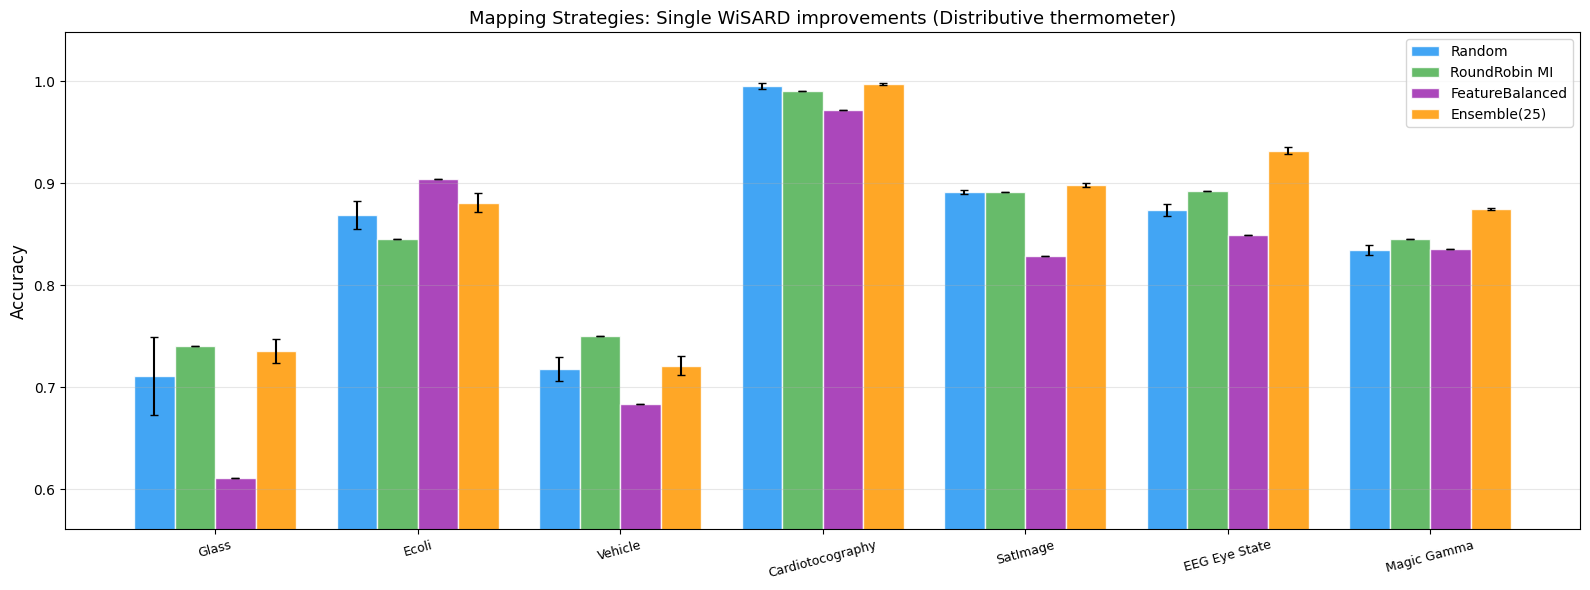


             Dataset    Random  RndRobin   FeatBal  Ensemble  v2 delta  v3 delta
               Glass    0.7111    0.7407    0.6111    0.7352   +0.0296   -0.1000
               Ecoli    0.8690    0.8452    0.9048    0.8810   -0.0238   +0.0357
             Vehicle    0.7179    0.7500    0.6840    0.7212   +0.0321   -0.0340
    Cardiotocography    0.9955    0.9906    0.9718    0.9972   -0.0049   -0.0237
            SatImage    0.8919    0.8918    0.8284    0.8983   -0.0001   -0.0635
       EEG Eye State    0.8743    0.8927    0.8497    0.9322   +0.0184   -0.0246
         Magic Gamma    0.8345    0.8452    0.8360    0.8750   +0.0107   +0.0014


In [10]:
# === 18.6 Visualization: all mapping strategies ===

v3_methods = ['Random', 'RoundRobin MI', 'FeatureBalanced', 'Ensemble(25)']
v3_colors = {'Random': '#2196F3', 'RoundRobin MI': '#4CAF50', 'FeatureBalanced': '#9C27B0', 'Ensemble(25)': '#FF9800'}
v3_ds_names = list(datasets.keys())

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(v3_ds_names))
width = 0.2

for i, method in enumerate(v3_methods):
    means = [sup_map_v3_results[(ds, method)][0] for ds in v3_ds_names]
    stds = [sup_map_v3_results[(ds, method)][1] for ds in v3_ds_names]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=v3_colors[method], edgecolor='white', capsize=3, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(v3_ds_names, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Mapping Strategies: Single WiSARD improvements (Distributive thermometer)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(bottom=max(0, min(sup_map_v3_results[(ds, m)][0] for ds in v3_ds_names for m in v3_methods) - 0.05))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'RndRobin':>8s}  {'FeatBal':>8s}  {'Ensemble':>8s}  {'v2 delta':>8s}  {'v3 delta':>8s}")
for ds in v3_ds_names:
    r = sup_map_v3_results[(ds, 'Random')][0]
    v2 = sup_map_v3_results[(ds, 'RoundRobin MI')][0]
    v3 = sup_map_v3_results[(ds, 'FeatureBalanced')][0]
    e = sup_map_v3_results[(ds, 'Ensemble(25)')][0]
    print(f"{ds:>20s}  {r:>8.4f}  {v2:>8.4f}  {v3:>8.4f}  {e:>8.4f}  {v2-r:>+8.4f}  {v3-r:>+8.4f}")

In [11]:
# === 18.7 Feature-Balanced sweep: accuracy vs addressSize ===
# Test all mapping strategies across address sizes, including Ensemble for reference.

SWEEP_ADDR_SIZES = [4, 8, 14, 20, 28, 36, 48, 56, 64]

sweep_mapping_results = {}  # (dataset, addr, method) -> (mean, std)
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    _, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    n_feat = X_ds.shape[1]
    n_bits = n_feat * ts

    print(f"\n{'='*70}")
    print(f"{ds_name}: {n_feat} features, {n_bits} bits, thermo={ts}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=28, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    print(f"  {'addr':>4s}  {'ratio':>5s}  {'Random':>8s}  {'v2 RR':>8s}  {'v3 FB':>8s}  {'Ens(25)':>8s}  {'v2 delta':>8s}  {'v3 delta':>8s}  {'ens delta':>9s}")
    for addr in SWEEP_ADDR_SIZES:
        if addr > n_bits:
            continue
        ratio = addr / n_feat

        # Random
        accs_rnd = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr)
            w.train(ds_train)
            accs_rnd.append(compute_accuracy(w.classify(ds_test), y_te))

        # v2: RoundRobin MI
        v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr)
        w_v2 = wp.Wisard(addr, mapping=v2_map)
        w_v2.train(ds_train)
        acc_v2 = compute_accuracy(w_v2.classify(ds_test), y_te)

        # v3: Feature-Balanced
        v3_map = compute_supervised_mapping_v3(X_tr_bin, y_tr.tolist(), addr, ts)
        w_v3 = wp.Wisard(addr, mapping=v3_map)
        w_v3.train(ds_train)
        acc_v3 = compute_accuracy(w_v3.classify(ds_test), y_te)

        # Ensemble (25 random)
        accs_ens = []
        for run in range(N_RUNS):
            wisards = [wp.Wisard(addr) for _ in range(25)]
            for w in wisards: w.train(ds_train)
            accs_ens.append(compute_accuracy(ensemble_classify(wisards, ds_test), y_te))

        r = np.mean(accs_rnd)
        e = np.mean(accs_ens)
        sweep_mapping_results[(ds_name, addr, 'Random')] = (r, np.std(accs_rnd))
        sweep_mapping_results[(ds_name, addr, 'RoundRobin')] = (acc_v2, 0.0)
        sweep_mapping_results[(ds_name, addr, 'FeatureBalanced')] = (acc_v3, 0.0)
        sweep_mapping_results[(ds_name, addr, 'Ensemble(25)')] = (e, np.std(accs_ens))

        print(f"  {addr:>4d}  {ratio:>5.1f}  {r:>8.4f}  {acc_v2:>8.4f}  {acc_v3:>8.4f}  {e:>8.4f}  {acc_v2-r:>+8.4f}  {acc_v3-r:>+8.4f}  {e-r:>+9.4f}")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 9 features, 288 bits, thermo=32
  addr  ratio    Random     v2 RR     v3 FB   Ens(25)  v2 delta  v3 delta  ens delta
     4    0.4    0.6722    0.6481    0.6296    0.6963   -0.0241   -0.0426    +0.0241
     8    0.9    0.7796    0.8148    0.5926    0.7852   +0.0352   -0.1870    +0.0056
    14    1.6    0.8426    0.8519    0.7222    0.8574   +0.0093   -0.1204    +0.0148
    20    2.2    0.8519    0.8889    0.7593    0.8778   +0.0370   -0.0926    +0.0259
    28    3.1    0.7611    0.7778    0.7222    0.8704   +0.0167   -0.0389    +0.1093
    36    4.0    0.6741    0.6296    0.5926    0.7167   -0.0444   -0.0815    +0.0426
    48    5.3    0.4315    0.4630    0.5926    0.4500   +0.0315   +0.1611    +0.0185
    56    6.2    0.3889    0.4630    0.5926    0.3204   +0.0741   +0.2037    -0.0685
    64    7.1    0.2741    0.2037    0.2407    0.2241   -0.0704   -0.0333    -0.0500

Ecoli: 7 features, 224 bits, thermo=32
  addr  ratio    Random     v2 RR     v3 FB   Ens(25)  v2 delta  v3 de

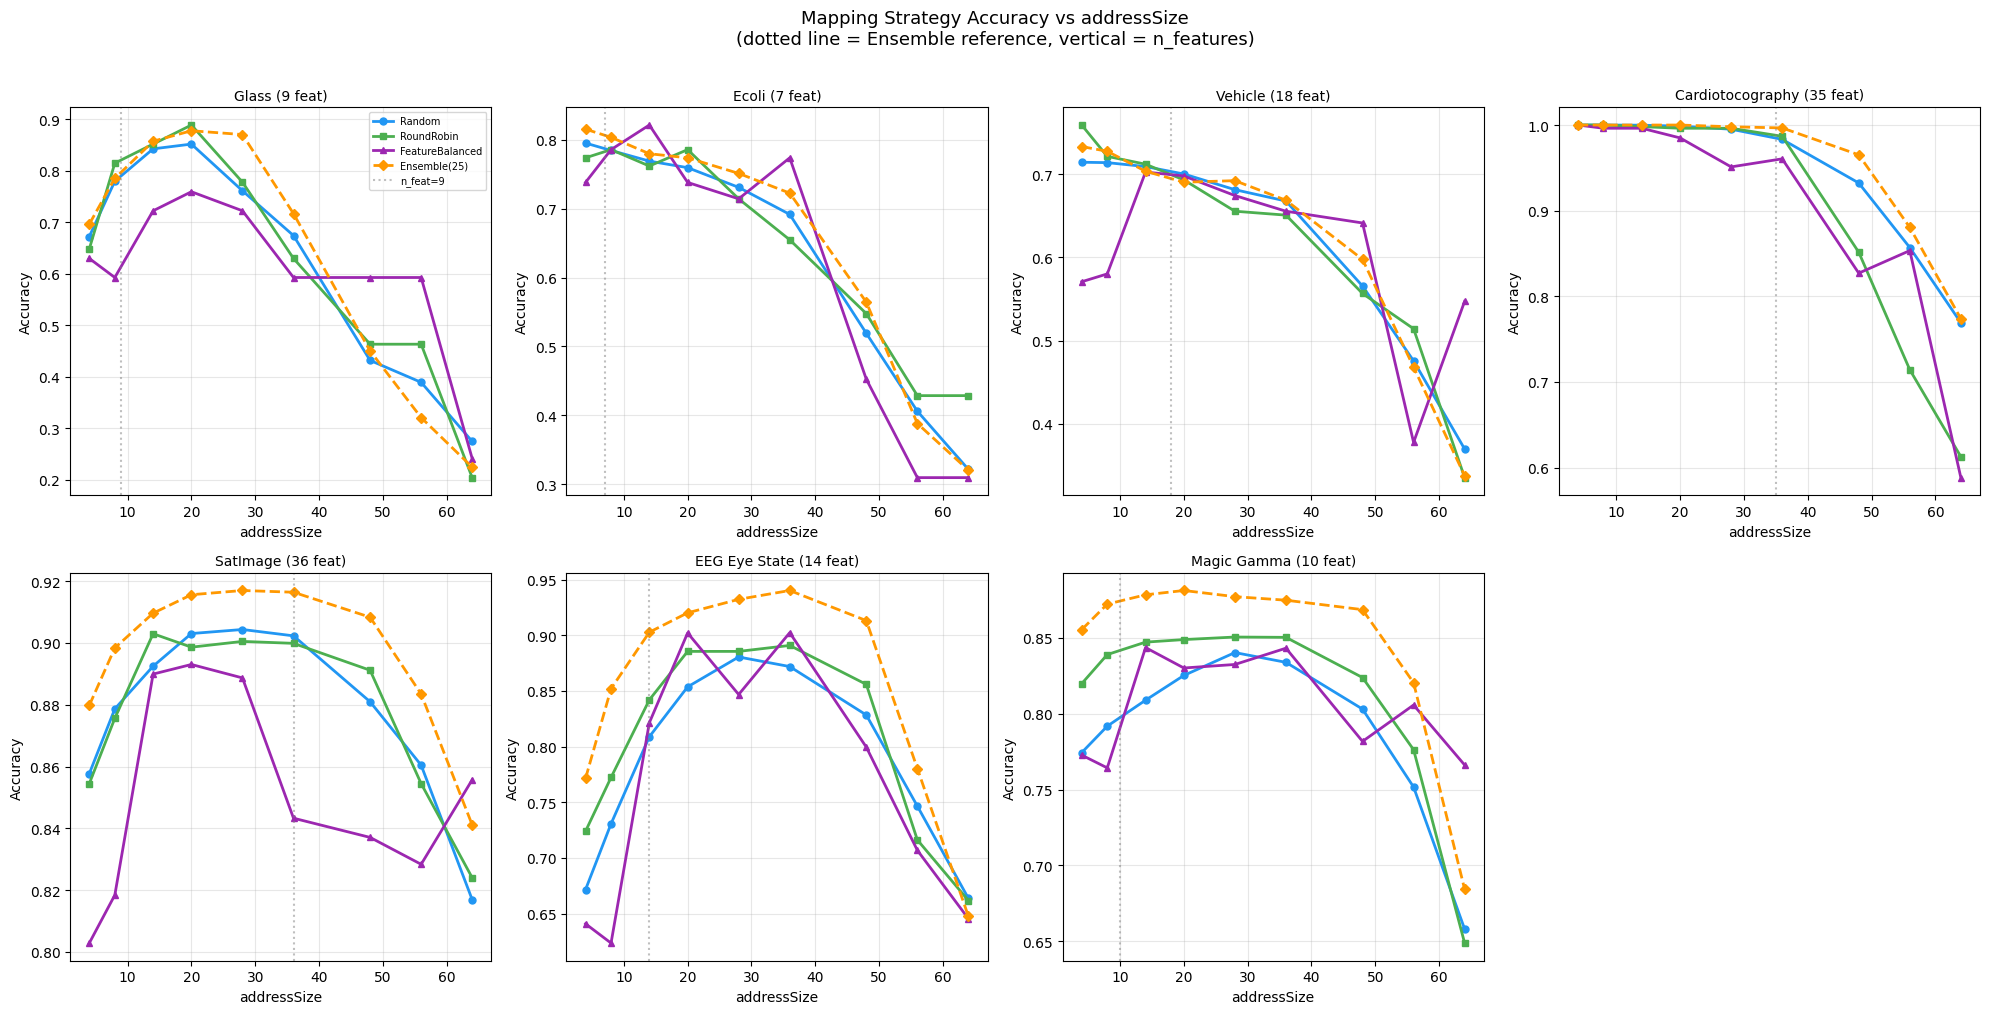

In [12]:
# === 18.8 Visualization: mapping strategy accuracy vs addressSize per dataset ===

sweep_ds_names = list(datasets.keys())
n_ds = len(sweep_ds_names)
fig, axes = plt.subplots(2, (n_ds + 1) // 2, figsize=(20, 10))
axes = axes.flat

method_styles = {
    'Random':          {'color': '#2196F3', 'marker': 'o', 'linestyle': '-'},
    'RoundRobin':      {'color': '#4CAF50', 'marker': 's', 'linestyle': '-'},
    'FeatureBalanced': {'color': '#9C27B0', 'marker': '^', 'linestyle': '-'},
    'Ensemble(25)':    {'color': '#FF9800', 'marker': 'D', 'linestyle': '--'},
}

for idx, ds_name in enumerate(sweep_ds_names):
    ax = axes[idx]
    n_feat = datasets[ds_name][0].shape[1]
    n_bits = n_feat * DATASET_CONFIG[ds_name][1]

    valid_addrs = [a for a in SWEEP_ADDR_SIZES if a <= n_bits]

    for method, style in method_styles.items():
        vals = []
        addrs_used = []
        for addr in valid_addrs:
            key = (ds_name, addr, method)
            if key in sweep_mapping_results:
                vals.append(sweep_mapping_results[key][0])
                addrs_used.append(addr)
        if vals:
            ax.plot(addrs_used, vals, marker=style['marker'], color=style['color'],
                    linestyle=style['linestyle'], label=method, linewidth=2, markersize=5)

    ax.axvline(x=n_feat, color='gray', linestyle=':', alpha=0.5, label=f'n_feat={n_feat}')
    ax.set_title(f'{ds_name} ({n_feat} feat)', fontsize=10)
    ax.set_xlabel('addressSize')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

for idx in range(n_ds, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Mapping Strategy Accuracy vs addressSize\n(dotted line = Ensemble reference, vertical = n_features)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 19. Ensemble of Supervised Mappings

Combine two proven techniques: **v2 (RoundRobin MI)** supervised mapping + **multi-address-size ensemble** diversity. Instead of 25 random WiSARDs at one address size, use 5 v2-mapped WiSARDs at different address sizes. Fewer models, each higher quality, with multi-resolution diversity.

In [27]:
# === 19.1 Ensemble of v2 mappings at different address sizes ===

def get_v2_ensemble_addresses(base_addr, n_models=5):
    """Address sizes from base/2 to base (capped, like section 17.3)."""
    min_addr = max(2, base_addr // 2)
    max_addr = base_addr
    step = (max_addr - min_addr) / (n_models - 1) if n_models > 1 else 0
    return [int(min_addr + i * step) for i in range(n_models)]

v2_ens_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: base addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Single Random
    t0 = time.time()
    accs = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size); w.train(ds_train)
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    v2_ens_results[(ds_name, 'Single Random')] = (np.mean(accs), np.std(accs))
    t_rnd = time.time() - t0

    # Single v2
    t0 = time.time()
    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)
    w = wp.Wisard(addr_size, mapping=v2_map); w.train(ds_train)
    acc_v2 = compute_accuracy(w.classify(ds_test), y_te)
    v2_ens_results[(ds_name, 'Single v2')] = (acc_v2, 0.0)
    t_v2 = time.time() - t0

    # Ensemble(5 random, same addr)
    t0 = time.time()
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(5)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    v2_ens_results[(ds_name, 'Ens(5 random)')] = (np.mean(accs), np.std(accs))
    t_ens5rnd = time.time() - t0

    # Ensemble(5 v2, multi-addr)
    t0 = time.time()
    ens_addrs_5 = get_v2_ensemble_addresses(addr_size, 5)
    accs = []
    for run in range(N_RUNS):
        ws = []
        for addr in ens_addrs_5:
            m = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr)
            w = wp.Wisard(addr, mapping=m); w.train(ds_train)
            ws.append(w)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    v2_ens_results[(ds_name, 'Ens(5 v2)')] = (np.mean(accs), np.std(accs))
    t_ens5v2 = time.time() - t0

    for method, elapsed in [('Single Random', t_rnd), ('Single v2', t_v2),
                             ('Ens(5 random)', t_ens5rnd),
                             ('Ens(5 v2)', t_ens5v2)]:
        m, s = v2_ens_results[(ds_name, method)]
        print(f"  {method:18s}: {m:.4f} +/- {s:.4f}  ({elapsed:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: base addr=8
  Single Random     : 0.7287 +/- 0.0462  (0.0s)
  Single v2         : 0.7407 +/- 0.0000  (0.0s)
  Ens(5 random)     : 0.7361 +/- 0.0233  (0.1s)
  Ens(5 v2)         : 0.7407 +/- 0.0000  (2.9s)

Ecoli: base addr=10
  Single Random     : 0.8369 +/- 0.0210  (0.0s)
  Single v2         : 0.8452 +/- 0.0000  (0.0s)
  Ens(5 random)     : 0.8470 +/- 0.0115  (0.1s)
  Ens(5 v2)         : 0.8452 +/- 0.0000  (3.5s)

Vehicle: base addr=14
  Single Random     : 0.7288 +/- 0.0166  (0.0s)
  Single v2         : 0.7594 +/- 0.0000  (0.1s)
  Ens(5 random)     : 0.7245 +/- 0.0168  (0.2s)
  Ens(5 v2)         : 0.7689 +/- 0.0000  (8.2s)

Cardiotocography: base addr=20
  Single Random     : 0.9947 +/- 0.0031  (0.3s)
  Single v2         : 0.9962 +/- 0.0000  (0.8s)
  Ens(5 random)     : 0.9964 +/- 0.0019  (1.5s)
  Ens(5 v2)         : 1.0000 +/- 0.0000  (80.6s)

SatImage: base addr=24
  Single Random     : 0.8884 +/- 0.0046  (0.6s)
  Single v2         : 0.8893 +/- 0.0000  (1.6s)
  Ens(5 random)

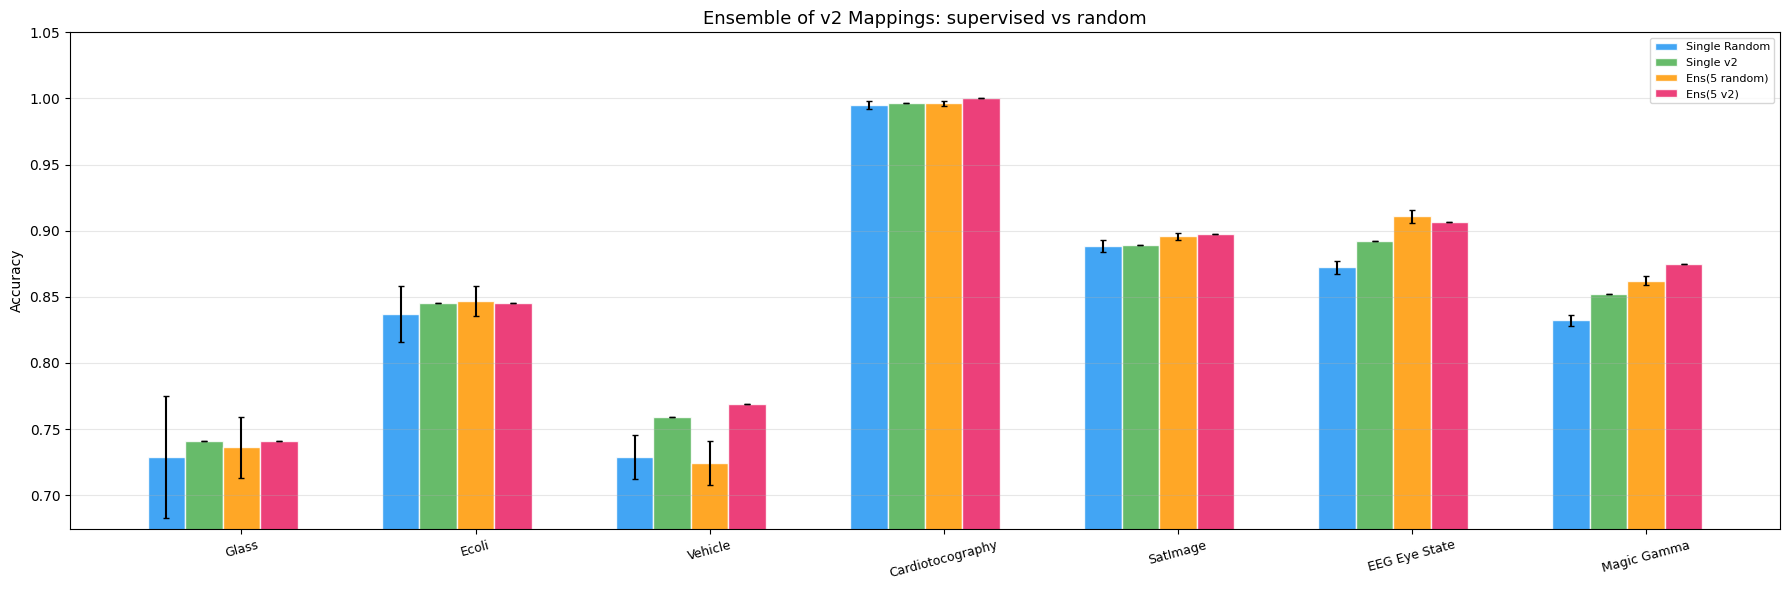


             Dataset    Random        v2     E5rnd      E5v2
               Glass    0.7287    0.7407    0.7361    0.7407
               Ecoli    0.8369    0.8452    0.8470    0.8452
             Vehicle    0.7288    0.7594    0.7245    0.7689
    Cardiotocography    0.9947    0.9962    0.9964    1.0000
            SatImage    0.8884    0.8893    0.8957    0.8974
       EEG Eye State    0.8724    0.8919    0.9108    0.9063
         Magic Gamma    0.8322    0.8519    0.8623    0.8751


In [29]:
# === 19.2 Visualization ===
s19_methods = ['Single Random', 'Single v2', 'Ens(5 random)', 'Ens(5 v2)']
s19_colors = {'Single Random': '#2196F3', 'Single v2': '#4CAF50', 'Ens(5 random)': '#FF9800',
              'Ens(5 v2)': '#E91E63'}
s19_ds = list(datasets.keys())

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(s19_ds))
width = 0.16
for i, method in enumerate(s19_methods):
    means = [v2_ens_results[(ds, method)][0] for ds in s19_ds]
    stds = [v2_ens_results[(ds, method)][1] for ds in s19_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=s19_colors[method], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 2 * width)
ax.set_xticklabels(s19_ds, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy'); ax.set_title('Ensemble of v2 Mappings: supervised vs random', fontsize=13)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(v2_ens_results[(ds, m)][0] for ds in s19_ds for m in s19_methods) - 0.05))
plt.tight_layout(); plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'v2':>8s}  {'E5rnd':>8s}  {'E5v2':>8s}")
for ds in s19_ds:
    vals = [v2_ens_results[(ds, m)][0] for m in s19_methods]
    print(f"{ds:>20s}  {vals[0]:>8.4f}  {vals[1]:>8.4f}  {vals[2]:>8.4f}  {vals[3]:>8.4f}")

## 20. Hill-Climbing Mapping Optimization

Start from v2 (RoundRobin MI) mapping and iteratively improve it. Each step: swap a random bit pair between two RAMs, evaluate on a validation split, keep the swap if accuracy improves. This is cheap — WiSARD train+classify is fast — and directly optimizes the mapping for classification accuracy.

In [12]:
# === 20.1 Hill-climbing mapping optimization ===
import copy

def hill_climb_mapping(base_mapping, X_bin_train, y_train, X_bin_val, y_val,
                       address_size, n_iterations=500):
    """Optimize a mapping by iteratively swapping bits between RAMs.
    Returns (best_mapping, accuracy_history)."""
    classes = sorted(base_mapping.keys())

    # Evaluate initial mapping
    ds_train = wp.DataSet(X_bin_train, y_train)
    ds_val = wp.DataSet(X_bin_val)

    w = wp.Wisard(address_size, mapping=base_mapping)
    w.train(ds_train)
    best_acc = compute_accuracy(w.classify(ds_val), y_val)
    best_mapping = copy.deepcopy(base_mapping)
    history = [best_acc]

    for iteration in range(n_iterations):
        # Pick a random class to modify
        cls = np.random.choice(classes)
        rams = best_mapping[cls]
        if len(rams) < 2:
            continue

        # Pick two different RAMs
        r1, r2 = np.random.choice(len(rams), 2, replace=False)
        if len(rams[r1]) == 0 or len(rams[r2]) == 0:
            continue

        # Pick one bit from each RAM and swap
        b1_idx = np.random.randint(len(rams[r1]))
        b2_idx = np.random.randint(len(rams[r2]))

        # Create candidate mapping with swap
        candidate = copy.deepcopy(best_mapping)
        candidate[cls][r1][b1_idx], candidate[cls][r2][b2_idx] = \
            candidate[cls][r2][b2_idx], candidate[cls][r1][b1_idx]

        # Evaluate
        w = wp.Wisard(address_size, mapping=candidate)
        w.train(ds_train)
        acc = compute_accuracy(w.classify(ds_val), y_val)

        if acc > best_acc:
            best_acc = acc
            best_mapping = candidate

        history.append(best_acc)

    return best_mapping, history

# === Run experiment ===
HC_ITERATIONS = [100, 500]
hc_results = {}
hc_histories = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)

    # Split train into train_inner + validation for hill climbing
    split_idx = int(len(X_tr_bin) * 0.8)
    X_inner, X_val_hc = X_tr_bin[:split_idx], X_tr_bin[split_idx:]
    y_inner, y_val_hc = y_tr[:split_idx].tolist(), y_tr[split_idx:].tolist()

    ds_full_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Random baseline
    accs = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size); w.train(ds_full_train)
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    hc_results[(ds_name, 'Random')] = (np.mean(accs), np.std(accs))

    # v2 baseline
    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)
    w = wp.Wisard(addr_size, mapping=v2_map); w.train(ds_full_train)
    hc_results[(ds_name, 'v2')] = (compute_accuracy(w.classify(ds_test), y_te), 0.0)

    # Hill-climbed from v2
    for n_iter in HC_ITERATIONS:
        t0 = time.time()
        hc_map, history = hill_climb_mapping(
            v2_map, X_inner, y_inner, X_val_hc, y_val_hc, addr_size, n_iter)
        hc_time = time.time() - t0

        # Evaluate on test set (train on FULL training data)
        w = wp.Wisard(addr_size, mapping=hc_map); w.train(ds_full_train)
        acc_hc = compute_accuracy(w.classify(ds_test), y_te)
        hc_results[(ds_name, f'HC({n_iter})')] = (acc_hc, 0.0)
        hc_histories[(ds_name, n_iter)] = history
        print(f"  HC(iter={n_iter}): val {history[0]:.4f} → {history[-1]:.4f}, test={acc_hc:.4f} ({hc_time:.1f}s)")

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_full_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    hc_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))

    r = hc_results[(ds_name, 'Random')][0]
    for method in ['Random', 'v2'] + [f'HC({n})' for n in HC_ITERATIONS] + ['Ens(25)']:
        m, s = hc_results[(ds_name, method)]
        print(f"  {method:12s}: {m:.4f}  delta={m-r:+.4f}")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: addr=8
  HC(iter=100): val 0.7188 → 0.7188, test=0.8333 (0.1s)
  HC(iter=500): val 0.7188 → 0.7188, test=0.8333 (0.3s)
  Random      : 0.8074  delta=+0.0000
  v2          : 0.8333  delta=+0.0259
  HC(100)     : 0.8333  delta=+0.0259
  HC(500)     : 0.8333  delta=+0.0259
  Ens(25)     : 0.8111  delta=+0.0037

Ecoli: addr=10
  HC(iter=100): val 0.8824 → 0.9020, test=0.8333 (0.1s)
  HC(iter=500): val 0.8824 → 0.9216, test=0.8452 (0.3s)
  Random      : 0.8155  delta=+0.0000
  v2          : 0.8333  delta=+0.0179
  HC(100)     : 0.8333  delta=+0.0179
  HC(500)     : 0.8452  delta=+0.0298
  Ens(25)     : 0.8310  delta=+0.0155

Vehicle: addr=14
  HC(iter=100): val 0.7717 → 0.8110, test=0.7170 (0.2s)
  HC(iter=500): val 0.7717 → 0.8189, test=0.7358 (0.9s)
  Random      : 0.7146  delta=+0.0000
  v2          : 0.7123  delta=-0.0024
  HC(100)     : 0.7170  delta=+0.0024
  HC(500)     : 0.7358  delta=+0.0212
  Ens(25)     : 0.7099  delta=-0.0047

Cardiotocography: addr=20
  HC(iter=100): va

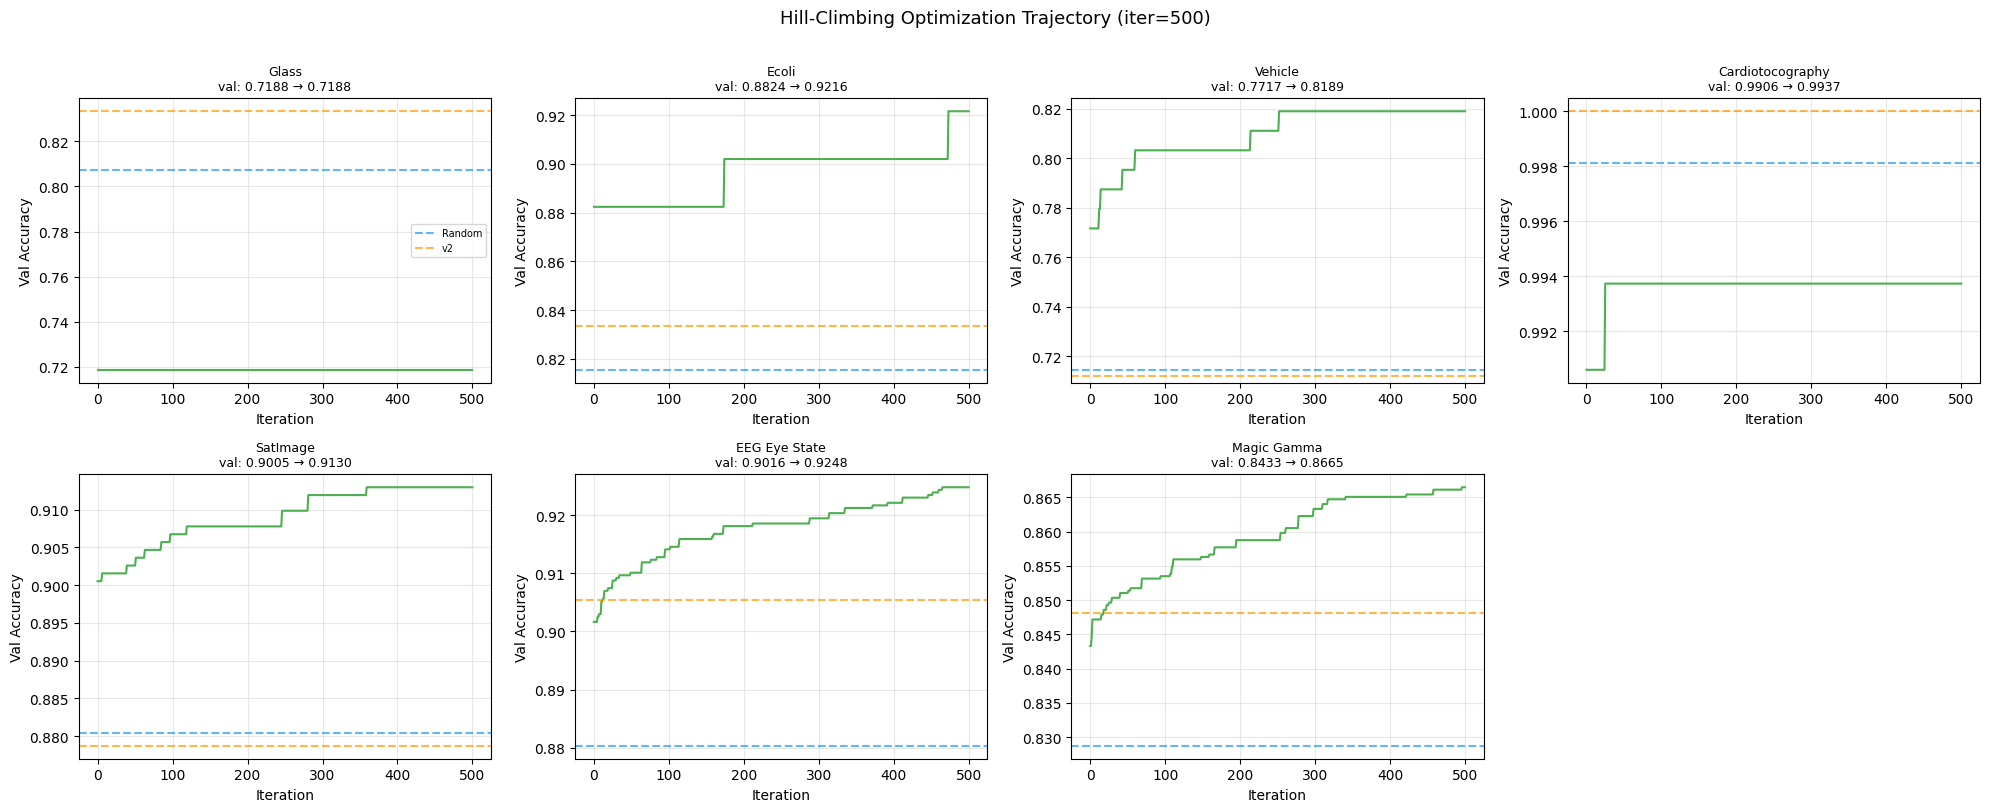

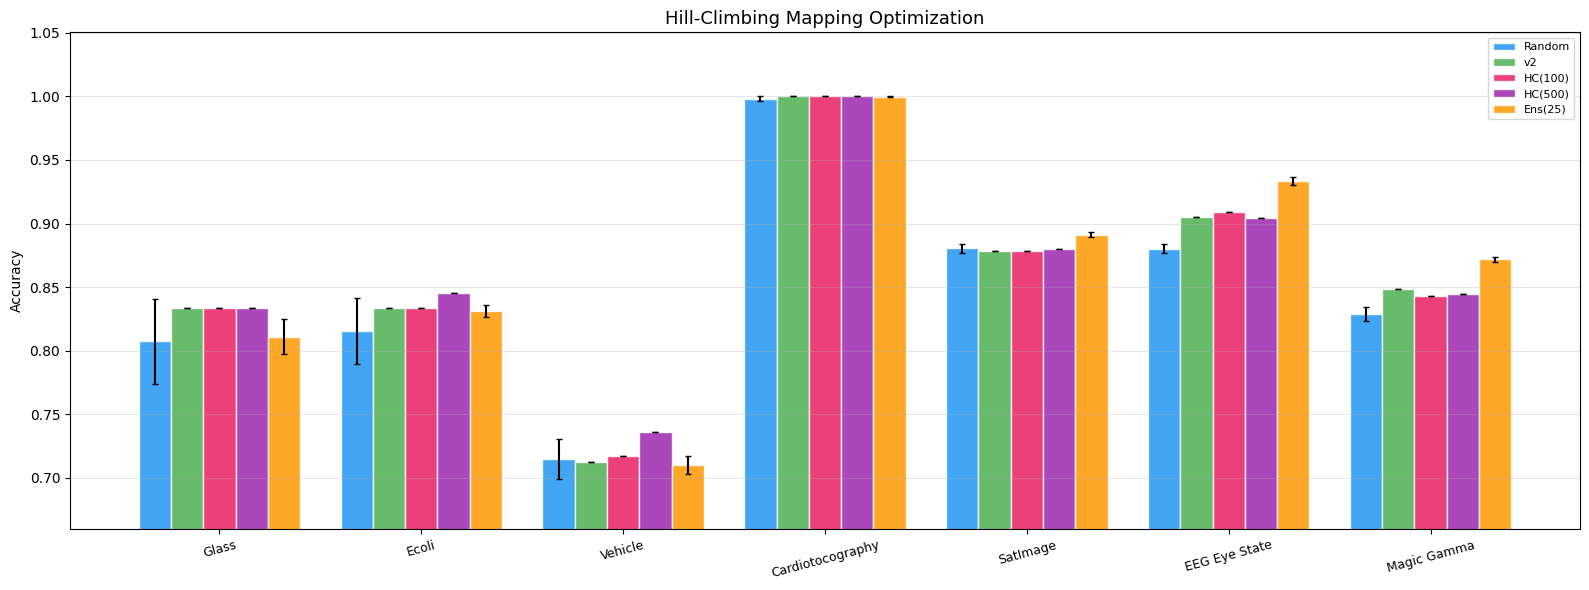

In [13]:
# === 20.2 Hill-climbing trajectory + results visualization ===

# Trajectory plots for the largest iteration count
fig, axes = plt.subplots(2, (len(datasets) + 1) // 2, figsize=(20, 8))
axes = axes.flat
max_iter = max(HC_ITERATIONS)

for idx, ds_name in enumerate(datasets.keys()):
    ax = axes[idx]
    if (ds_name, max_iter) in hc_histories:
        history = hc_histories[(ds_name, max_iter)]
        ax.plot(history, color='#4CAF50', linewidth=1.5)
        ax.axhline(y=hc_results[(ds_name, 'Random')][0], color='#2196F3', linestyle='--', alpha=0.7, label='Random')
        ax.axhline(y=hc_results[(ds_name, 'v2')][0], color='#FF9800', linestyle='--', alpha=0.7, label='v2')
        ax.set_title(f'{ds_name}\nval: {history[0]:.4f} → {history[-1]:.4f}', fontsize=9)
        ax.set_xlabel('Iteration'); ax.set_ylabel('Val Accuracy')
        if idx == 0: ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(len(datasets), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Hill-Climbing Optimization Trajectory (iter={max_iter})', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Bar chart: all methods
hc_methods = ['Random', 'v2'] + [f'HC({n})' for n in HC_ITERATIONS] + ['Ens(25)']
hc_colors = ['#2196F3', '#4CAF50', '#E91E63', '#9C27B0', '#FF9800']
hc_ds = list(datasets.keys())

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(hc_ds))
width = 0.16
for i, method in enumerate(hc_methods):
    means = [hc_results[(ds, method)][0] for ds in hc_ds]
    stds = [hc_results[(ds, method)][1] for ds in hc_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=hc_colors[i], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 2 * width)
ax.set_xticklabels(hc_ds, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy'); ax.set_title('Hill-Climbing Mapping Optimization', fontsize=13)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(hc_results[(ds, m)][0] for ds in hc_ds for m in hc_methods) - 0.05))
plt.tight_layout(); plt.show()

## 21. Overlapping/Redundant Bit Mappings

Standard WiSARD: each bit goes to exactly 1 RAM. Here: **high-MI bits appear in multiple RAMs**. Different RAMs see the same important bit combined with different neighbors → diversity within a single model. WiSARD already supports this (tested in `test_discriminator.py`).

In [19]:
# === 21.1 Overlapping bit mappings: sweep overlap fraction ===

def compute_overlap_mapping(X_bin, y, address_size, overlap_fraction=0.25):
    """Start from v2 mapping, then duplicate top-MI bits into additional RAMs.
    overlap_fraction: fraction of bits to duplicate (0 = no overlap = v2).
    Each RAM is capped at 64 bits to avoid address overflow."""
    # Start from v2 as base
    base_mapping = compute_supervised_mapping_v2(X_bin, y, address_size)
    n_bits = len(X_bin[0])
    classes = sorted(set(y))
    max_ram_size = min(64, address_size * 2)  # cap: don't let RAMs grow too large

    mapping = {}
    for cls in classes:
        mi = compute_bit_mi(X_bin, y, cls)
        rams = [list(r) for r in base_mapping[cls]]

        # Identify top-MI bits to duplicate
        all_bits = list(range(n_bits))
        all_bits.sort(key=lambda b: mi[b], reverse=True)
        n_overlap = int(n_bits * overlap_fraction)
        top_bits = all_bits[:n_overlap]

        # Compute average MI per RAM to find weakest RAMs
        ram_mi = []
        for r_idx, ram in enumerate(rams):
            avg = np.mean([mi[b] for b in ram]) if ram else 0
            ram_mi.append((avg, r_idx))
        ram_mi.sort()  # weakest first

        # Add each top bit to the weakest RAM that doesn't already have it and isn't full
        for bit in top_bits:
            for _, r_idx in ram_mi:
                if bit not in rams[r_idx] and len(rams[r_idx]) < max_ram_size:
                    rams[r_idx].append(bit)
                    break

        mapping[cls] = rams

    return mapping

# === Run experiment: sweep overlap fractions ===
OVERLAP_FRACTIONS = [0.0, 0.1, 0.25, 0.5]
overlap_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))

    print(f"\n{'='*70}")
    print(f"{ds_name}: addr={addr_size}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Random baseline
    accs = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size); w.train(ds_train)
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    overlap_results[(ds_name, 'Random')] = (np.mean(accs), np.std(accs))

    # Sweep overlap fractions
    for frac in OVERLAP_FRACTIONS:
        ol_map = compute_overlap_mapping(X_tr_bin, y_tr.tolist(), addr_size, frac)
        w = wp.Wisard(addr_size, mapping=ol_map)
        w.train(ds_train)
        acc = compute_accuracy(w.classify(ds_test), y_te)
        label = f'v2' if frac == 0 else f'Overlap({int(frac*100)}%)'
        overlap_results[(ds_name, label)] = (acc, 0.0)

        # Show RAM sizes for first class
        sample_cls = sorted(ol_map.keys())[0]
        ram_sizes = [len(r) for r in ol_map[sample_cls]]
        total_bits = sum(ram_sizes)
        print(f"  {label:15s}: {acc:.4f}  RAM sizes: min={min(ram_sizes)}, max={max(ram_sizes)}, total={total_bits} (base={len(X_tr_bin[0])})")

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    overlap_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))

    r = overlap_results[(ds_name, 'Random')][0]
    print(f"  {'Random':15s}: {r:.4f}")
    print(f"  {'Ens(25)':15s}: {overlap_results[(ds_name, 'Ens(25)')][0]:.4f}")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: addr=8
  v2             : 0.7593  RAM sizes: min=8, max=8, total=288 (base=288)
  Overlap(10%)   : 0.7593  RAM sizes: min=8, max=16, total=316 (base=288)
  Overlap(25%)   : 0.7963  RAM sizes: min=8, max=16, total=360 (base=288)
  Overlap(50%)   : 0.8148  RAM sizes: min=8, max=16, total=432 (base=288)
  Random         : 0.7019
  Ens(25)        : 0.7407

Ecoli: addr=10
  v2             : 0.9167  RAM sizes: min=9, max=10, total=224 (base=224)
  Overlap(10%)   : 0.9167  RAM sizes: min=9, max=20, total=246 (base=224)
  Overlap(25%)   : 0.9167  RAM sizes: min=9, max=20, total=280 (base=224)
  Overlap(50%)   : 0.8929  RAM sizes: min=10, max=20, total=336 (base=224)
  Random         : 0.8702
  Ens(25)        : 0.8762

Vehicle: addr=14
  v2             : 0.7689  RAM sizes: min=13, max=14, total=576 (base=576)
  Overlap(10%)   : 0.7783  RAM sizes: min=13, max=28, total=633 (base=576)
  Overlap(25%)   : 0.7783  RAM sizes: min=13, max=28, total=720 (base=576)
  Overlap(50%)   : 0.7642  RAM

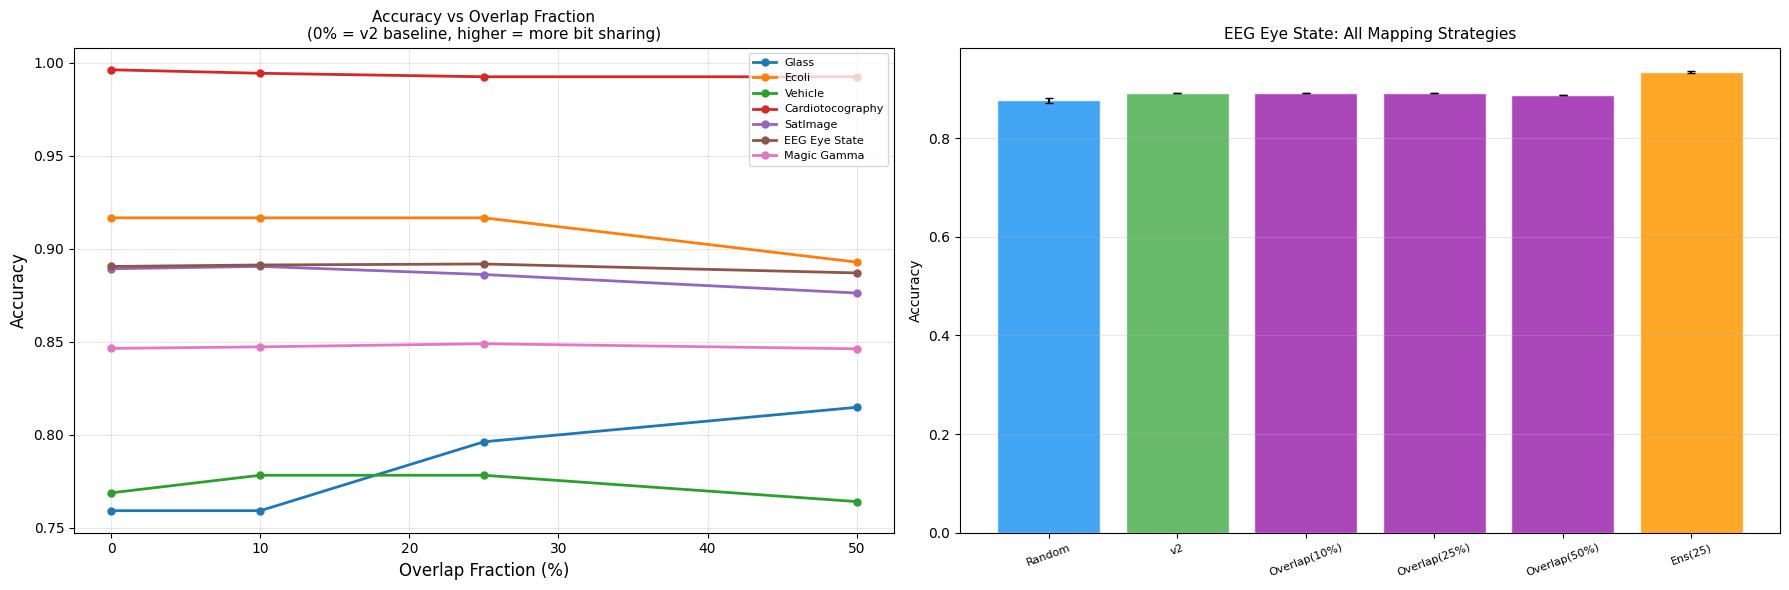


             Dataset      Random          v2  Overlap(10%)  Overlap(25%)  Overlap(50%)     Ens(25)
               Glass      0.7019      0.7593      0.7593      0.7963      0.8148      0.7407
               Ecoli      0.8702      0.9167      0.9167      0.9167      0.8929      0.8762
             Vehicle      0.7830      0.7689      0.7783      0.7783      0.7642      0.7783
    Cardiotocography      0.9974      0.9962      0.9944      0.9925      0.9925      0.9979
            SatImage      0.8918      0.8893      0.8905      0.8862      0.8762      0.9027
       EEG Eye State      0.8764      0.8905      0.8913      0.8919      0.8870      0.9347
         Magic Gamma      0.8286      0.8465      0.8473      0.8490      0.8463      0.8696


In [20]:
# === 21.2 Visualization: accuracy vs overlap fraction per dataset ===

ol_ds_names = list(datasets.keys())
ol_labels = ['v2'] + [f'Overlap({int(f*100)}%)' for f in OVERLAP_FRACTIONS if f > 0]
all_ol_labels = ['Random'] + ol_labels + ['Ens(25)']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: accuracy vs overlap fraction (line plot)
ax = axes[0]
cmap = plt.colormaps.get_cmap('tab10')
fracs_plot = OVERLAP_FRACTIONS
for i, ds_name in enumerate(ol_ds_names):
    vals = []
    for frac in fracs_plot:
        label = 'v2' if frac == 0 else f'Overlap({int(frac*100)}%)'
        vals.append(overlap_results[(ds_name, label)][0])
    ax.plot([f*100 for f in fracs_plot], vals, 'o-', color=cmap(i), label=ds_name, linewidth=2, markersize=5)

ax.set_xlabel('Overlap Fraction (%)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Overlap Fraction\n(0% = v2 baseline, higher = more bit sharing)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: bar chart all methods for EEG Eye State
ax = axes[1]
ds_show = 'EEG Eye State'
x = np.arange(len(all_ol_labels))
vals = [overlap_results[(ds_show, m)][0] for m in all_ol_labels]
stds = [overlap_results[(ds_show, m)][1] for m in all_ol_labels]
colors = ['#2196F3'] + ['#4CAF50'] + ['#9C27B0'] * (len(ol_labels) - 1) + ['#FF9800']
ax.bar(x, vals, yerr=stds, color=colors, edgecolor='white', capsize=3, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(all_ol_labels, fontsize=8, rotation=20)
ax.set_ylabel('Accuracy'); ax.set_title(f'{ds_show}: All Mapping Strategies', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
print(f"\n{'Dataset':>20s}", end='')
for m in all_ol_labels: print(f"  {m:>10s}", end='')
print()
for ds in ol_ds_names:
    print(f"{ds:>20s}", end='')
    for m in all_ol_labels:
        print(f"  {overlap_results[(ds, m)][0]:>10.4f}", end='')
    print()

## 22. Soft Bleaching

Standard Bleaching counts RAMs: "how many recognized this pattern?" — treating a vote of 10 the same as a vote of 2 (both count as 1). **Soft Bleaching** uses the vote magnitude: `contribution = vote - threshold`. Stronger matches contribute more to the class score.

In [5]:
# === 22.1 Soft Bleaching experiment ===
soft_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    print(f"\n{ds_name}: ", end='', flush=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)

    configs = [
        ('Random',          {'addr': addr_size}),
        ('Random+Soft',     {'addr': addr_size, 'softBleaching': True}),
        ('v2',              {'addr': addr_size, 'mapping': v2_map}),
        ('v2+Soft',         {'addr': addr_size, 'mapping': v2_map, 'softBleaching': True}),
    ]

    for label, kwargs in configs:
        addr = kwargs.pop('addr')
        accs = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr, **kwargs)
            w.train(ds_train)
            accs.append(compute_accuracy(w.classify(ds_test), y_te))
        soft_results[(ds_name, label)] = (np.mean(accs), np.std(accs))
        kwargs['addr'] = addr  # restore
        print(f"{label}={np.mean(accs):.4f} ", end='', flush=True)

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    soft_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))
    print(f"Ens={np.mean(accs):.4f}")

total_elapsed = time.time() - total_start
print(f"\nDone! {total_elapsed:.1f}s")


Glass: Random=0.6435 Random+Soft=0.6213 v2=0.5926 v2+Soft=0.5741 Ens=0.6435

Ecoli: Random=0.8315 Random+Soft=0.7512 v2=0.8571 v2+Soft=0.7738 Ens=0.8530

Vehicle: Random=0.7533 Random+Soft=0.6979 v2=0.7453 v2+Soft=0.7028 Ens=0.7535

Cardiotocography: Random=0.9964 Random+Soft=0.9390 v2=0.9962 v2+Soft=0.9492 Ens=0.9988

SatImage: Random=0.8991 Random+Soft=0.8547 v2=0.9036 v2+Soft=0.8688 Ens=0.9089

EEG Eye State: Random=0.8761 Random+Soft=0.7496 v2=0.8953 v2+Soft=0.8139 Ens=0.9315

Magic Gamma: Random=0.8311 Random+Soft=0.7983 v2=0.8494 v2+Soft=0.8219 Ens=0.8733

Done! 52.9s


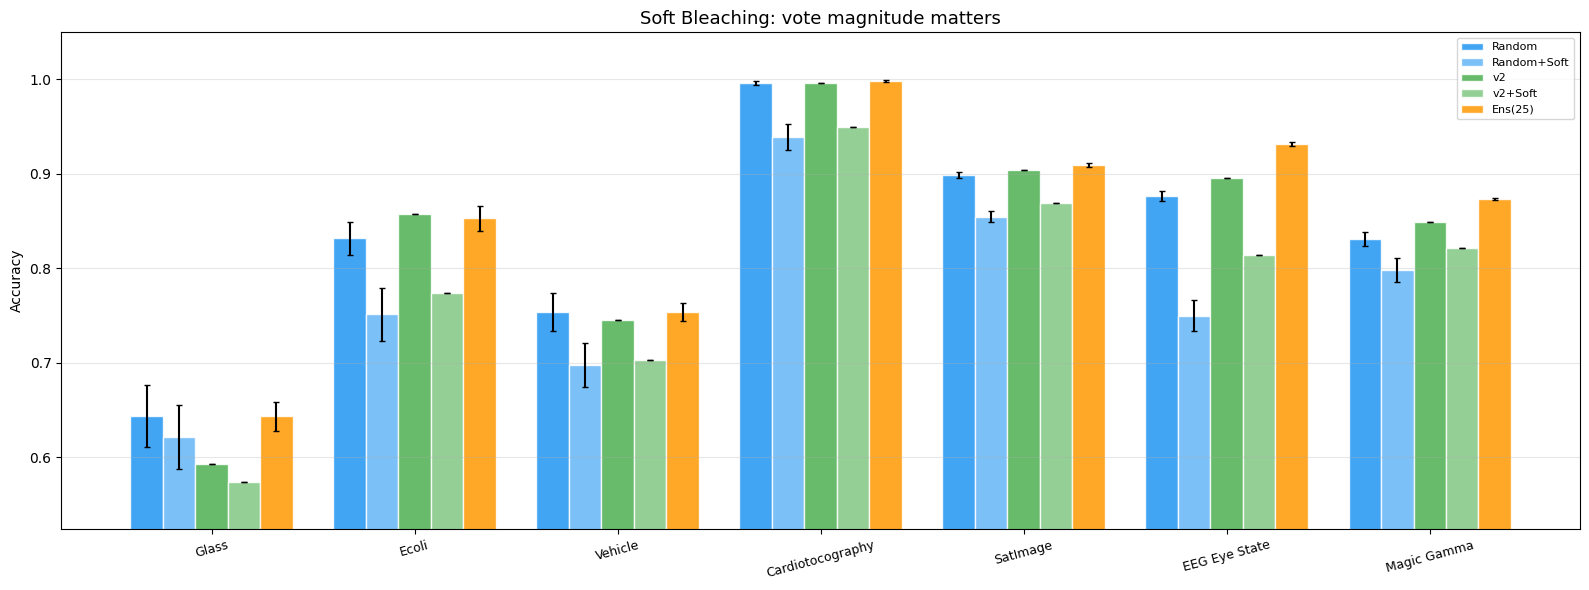


             Dataset    Random  Rnd+Soft        v2   v2+Soft     Ens25
               Glass    0.6435    0.6213    0.5926    0.5741    0.6435
               Ecoli    0.8315    0.7512    0.8571    0.7738    0.8530
             Vehicle    0.7533    0.6979    0.7453    0.7028    0.7535
    Cardiotocography    0.9964    0.9390    0.9962    0.9492    0.9988
            SatImage    0.8991    0.8547    0.9036    0.8688    0.9089
       EEG Eye State    0.8761    0.7496    0.8953    0.8139    0.9315
         Magic Gamma    0.8311    0.7983    0.8494    0.8219    0.8733


In [6]:
# === 22.2 Soft Bleaching visualization ===
s22_methods = ['Random', 'Random+Soft', 'v2', 'v2+Soft', 'Ens(25)']
s22_colors = ['#2196F3', '#64B5F6', '#4CAF50', '#81C784', '#FF9800']
s22_ds = list(datasets.keys())

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(s22_ds)); width = 0.16
for i, method in enumerate(s22_methods):
    means = [soft_results[(ds, method)][0] for ds in s22_ds]
    stds = [soft_results[(ds, method)][1] for ds in s22_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=s22_colors[i], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 2 * width); ax.set_xticklabels(s22_ds, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy'); ax.set_title('Soft Bleaching: vote magnitude matters', fontsize=13)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(soft_results[(ds, m)][0] for ds in s22_ds for m in s22_methods) - 0.05))
plt.tight_layout(); plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'Rnd+Soft':>8s}  {'v2':>8s}  {'v2+Soft':>8s}  {'Ens25':>8s}")
for ds in s22_ds:
    vals = [soft_results[(ds, m)][0] for m in s22_methods]
    print(f"{ds:>20s}  {vals[0]:>8.4f}  {vals[1]:>8.4f}  {vals[2]:>8.4f}  {vals[3]:>8.4f}  {vals[4]:>8.4f}")

## 23. Cross-Class Scoring

Standard WiSARD: each Discriminator scores independently — class A's RAMs don't know what class B sees. A pattern common to ALL classes is uninformative, but standard Bleaching can't detect this. **Cross-class scoring** normalizes each RAM's vote by the total across all classes: `vote_A / (vote_A + vote_B + ε)`. Unique patterns get amplified; shared patterns get dampened.

In [7]:
# === 23.1 Cross-class scoring experiment ===
cross_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    print(f"\n{ds_name}: ", end='', flush=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)

    configs = [
        ('Random',           {'addr': addr_size}),
        ('Random+Cross',     {'addr': addr_size, 'crossClassScoring': True}),
        ('v2',               {'addr': addr_size, 'mapping': v2_map}),
        ('v2+Cross',         {'addr': addr_size, 'mapping': v2_map, 'crossClassScoring': True}),
    ]

    for label, kwargs in configs:
        addr = kwargs.pop('addr')
        accs = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr, **kwargs)
            w.train(ds_train)
            accs.append(compute_accuracy(w.classify(ds_test), y_te))
        cross_results[(ds_name, label)] = (np.mean(accs), np.std(accs))
        kwargs['addr'] = addr
        print(f"{label}={np.mean(accs):.4f} ", end='', flush=True)

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    cross_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))
    print(f"Ens={np.mean(accs):.4f}")

total_elapsed = time.time() - total_start
print(f"\nDone! {total_elapsed:.1f}s")


Glass: Random=0.7130 Random+Cross=0.7019 v2=0.7407 v2+Cross=0.7222 Ens=0.7333

Ecoli: Random=0.8268 Random+Cross=0.8232 v2=0.7976 v2+Cross=0.8214 Ens=0.8232

Vehicle: Random=0.7106 Random+Cross=0.6889 v2=0.7358 v2+Cross=0.7028 Ens=0.7229

Cardiotocography: Random=0.9977 Random+Cross=0.9967 v2=0.9962 v2+Cross=0.9962 Ens=0.9995

SatImage: Random=0.8920 Random+Cross=0.8885 v2=0.8986 v2+Cross=0.8893 Ens=0.8998

EEG Eye State: Random=0.8722 Random+Cross=0.8444 v2=0.8903 v2+Cross=0.8737 Ens=0.9263

Magic Gamma: Random=0.8212 Random+Cross=0.8198 v2=0.8395 v2+Cross=0.8351 Ens=0.8541

Done! 53.3s


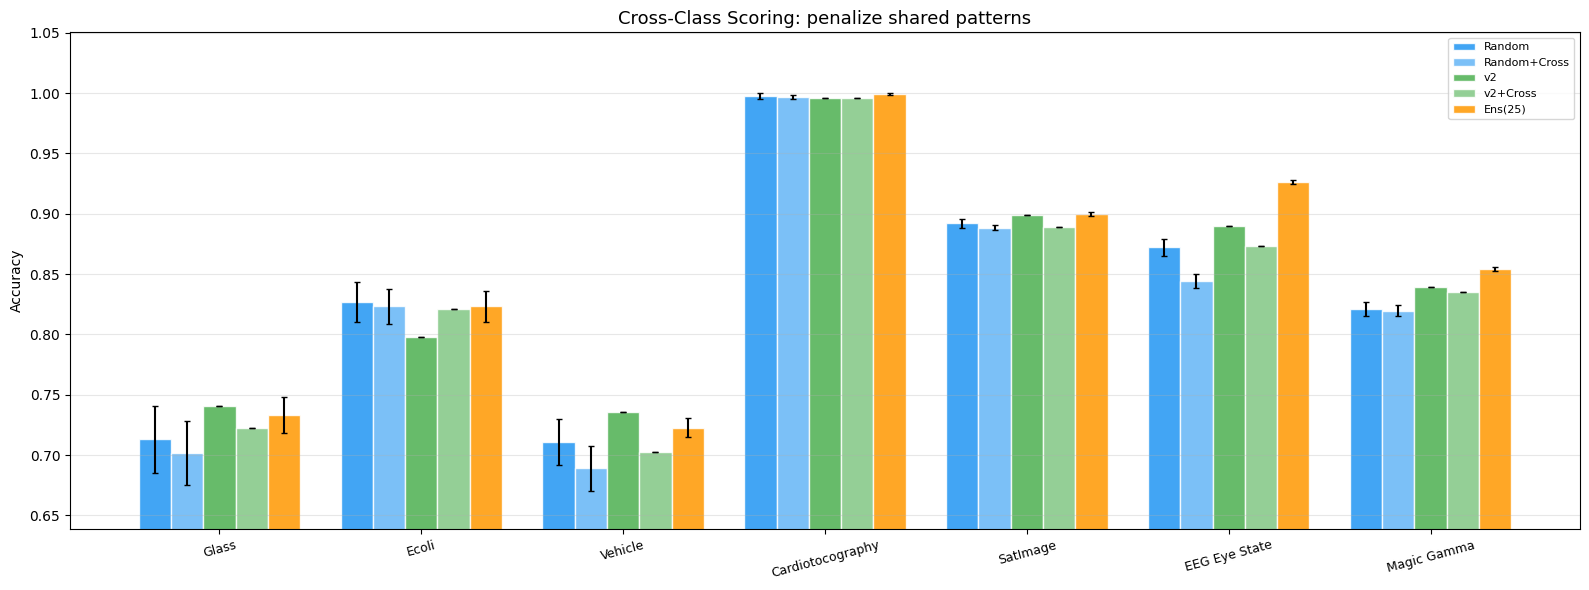


             Dataset    Random    Rnd+Xc        v2     v2+Xc     Ens25
               Glass    0.7130    0.7019    0.7407    0.7222    0.7333
               Ecoli    0.8268    0.8232    0.7976    0.8214    0.8232
             Vehicle    0.7106    0.6889    0.7358    0.7028    0.7229
    Cardiotocography    0.9977    0.9967    0.9962    0.9962    0.9995
            SatImage    0.8920    0.8885    0.8986    0.8893    0.8998
       EEG Eye State    0.8722    0.8444    0.8903    0.8737    0.9263
         Magic Gamma    0.8212    0.8198    0.8395    0.8351    0.8541


In [8]:
# === 23.2 Cross-class scoring visualization ===
s23_methods = ['Random', 'Random+Cross', 'v2', 'v2+Cross', 'Ens(25)']
s23_colors = ['#2196F3', '#64B5F6', '#4CAF50', '#81C784', '#FF9800']
s23_ds = list(datasets.keys())

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(s23_ds)); width = 0.16
for i, method in enumerate(s23_methods):
    means = [cross_results[(ds, method)][0] for ds in s23_ds]
    stds = [cross_results[(ds, method)][1] for ds in s23_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=s23_colors[i], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 2 * width); ax.set_xticklabels(s23_ds, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy'); ax.set_title('Cross-Class Scoring: penalize shared patterns', fontsize=13)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(cross_results[(ds, m)][0] for ds in s23_ds for m in s23_methods) - 0.05))
plt.tight_layout(); plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}  {'Rnd+Xc':>8s}  {'v2':>8s}  {'v2+Xc':>8s}  {'Ens25':>8s}")
for ds in s23_ds:
    vals = [cross_results[(ds, m)][0] for m in s23_methods]
    print(f"{ds:>20s}  {vals[0]:>8.4f}  {vals[1]:>8.4f}  {vals[2]:>8.4f}  {vals[3]:>8.4f}  {vals[4]:>8.4f}")

## 24. Boosted WiSARD Ensemble

Unlike random ensembles (Section 17) where each WiSARD makes independent random errors, **boosting** adapts: each new model focuses on samples the previous models got wrong. We duplicate misclassified samples in the training set for the next round, so later models specialize in hard cases.

In [8]:
# === 24.1 Boosted WiSARD experiment ===

# === Run experiment ===
BOOST_ROUNDS = [1, 3, 5, 10]
boost_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    print(f"\n{ds_name}: ", end='', flush=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_test = wp.DataSet(X_te_bin)

    # Random baseline
    accs = []
    for run in range(N_RUNS):
        w = wp.Wisard(addr_size)
        w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    boost_results[(ds_name, 'Random(1)')] = (np.mean(accs), np.std(accs))
    print(f"Rnd={np.mean(accs):.4f} ", end='', flush=True)

    # Boosted at different round counts
    for n_rounds in BOOST_ROUNDS:
        t0 = time.time()
        accs = []
        for run in range(N_RUNS):
            wisards = boosted_wisard_train(X_tr_bin, y_tr.tolist(), addr_size, n_rounds)
            preds = boosted_classify(wisards, ds_test)
            accs.append(compute_accuracy(preds, y_te))
        boost_results[(ds_name, f'Boost({n_rounds})')] = (np.mean(accs), np.std(accs))
        elapsed = time.time() - t0
        print(f"B{n_rounds}={np.mean(accs):.4f}({elapsed:.1f}s) ", end='', flush=True)

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(wp.DataSet(X_tr_bin, y_tr.tolist()))
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    boost_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))
    print(f"Ens={np.mean(accs):.4f}")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! {int(minutes)}m {seconds:.1f}s")


Glass: Rnd=0.7426 B1=0.7333(0.0s) B3=0.7519(0.1s) B5=0.7463(0.2s) B10=0.7389(0.2s) Ens=0.7556

Ecoli: Rnd=0.8446 B1=0.8321(0.0s) B3=0.8393(0.2s) B5=0.8399(0.3s) B10=0.8411(0.7s) Ens=0.8417

Vehicle: Rnd=0.7170 B1=0.7106(0.2s) B3=0.7245(0.4s) B5=0.7163(0.4s) B10=0.7144(0.3s) Ens=0.7167

Cardiotocography: 

KeyboardInterrupt: 

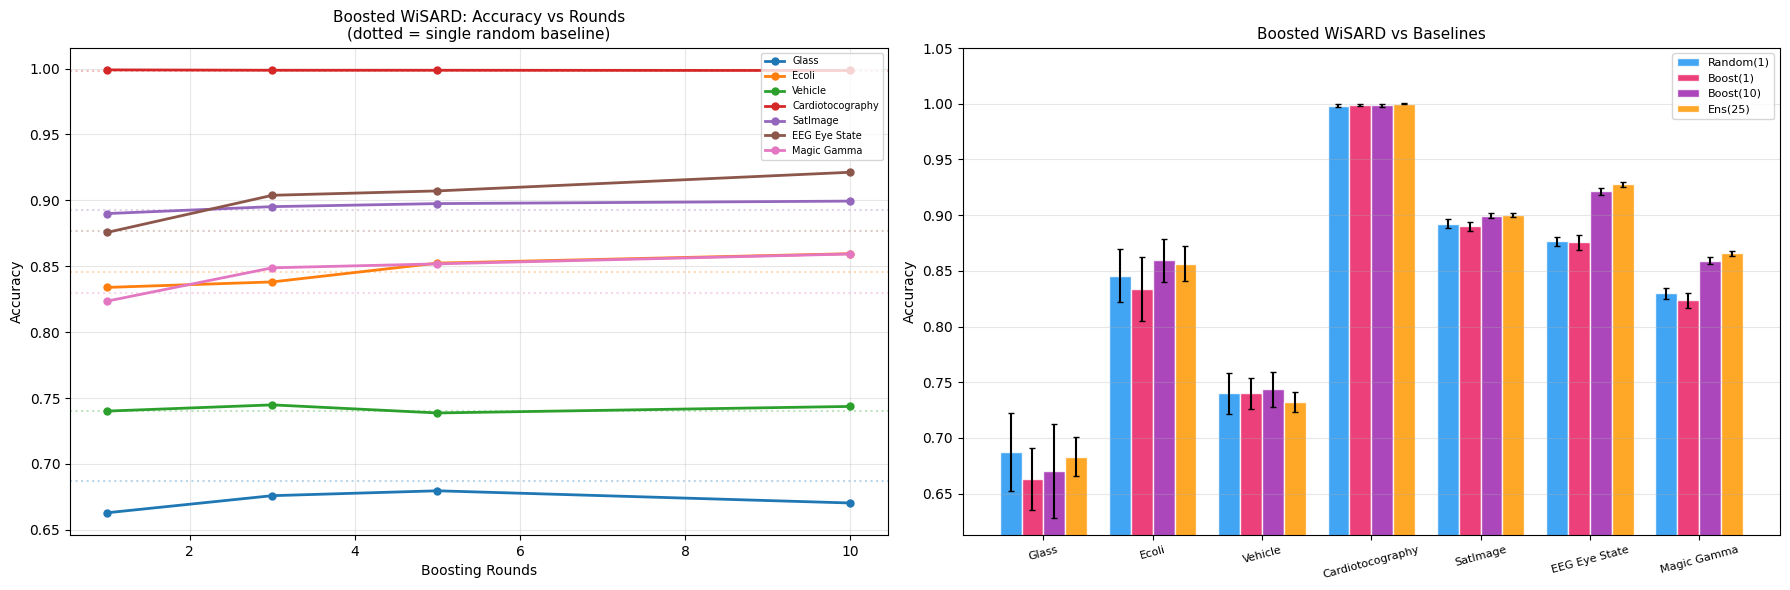


             Dataset    Random        B1        B3        B5       B10     Ens25
               Glass    0.6870    0.6630    0.6759    0.6796    0.6704    0.6833
               Ecoli    0.8458    0.8339    0.8381    0.8524    0.8595    0.8565
             Vehicle    0.7401    0.7401    0.7448    0.7387    0.7436    0.7323
    Cardiotocography    0.9982    0.9990    0.9987    0.9987    0.9985    0.9999
            SatImage    0.8924    0.8900    0.8952    0.8975    0.8994    0.9001
       EEG Eye State    0.8764    0.8757    0.9038    0.9071    0.9213    0.9278
         Magic Gamma    0.8299    0.8235    0.8488    0.8518    0.8593    0.8660


In [10]:
# === 24.2 Boosted WiSARD visualization ===
boost_ds = list(datasets.keys())

# Line plot: accuracy vs boosting rounds
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cmap = plt.colormaps.get_cmap('tab10')

ax = axes[0]
for i, ds_name in enumerate(boost_ds):
    vals = [boost_results[(ds_name, f'Boost({n})')][0] for n in BOOST_ROUNDS]
    ax.plot(BOOST_ROUNDS, vals, 'o-', color=cmap(i), label=ds_name, linewidth=2, markersize=5)
    # Reference lines
    ax.axhline(y=boost_results[(ds_name, 'Random(1)')][0], color=cmap(i), linestyle=':', alpha=0.3)
ax.set_xlabel('Boosting Rounds'); ax.set_ylabel('Accuracy')
ax.set_title('Boosted WiSARD: Accuracy vs Rounds\n(dotted = single random baseline)', fontsize=11)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Bar chart: best boosting vs baselines
ax = axes[1]
boost_methods = ['Random(1)', 'Boost(1)', f'Boost({max(BOOST_ROUNDS)})', 'Ens(25)']
boost_colors = ['#2196F3', '#E91E63', '#9C27B0', '#FF9800']
x = np.arange(len(boost_ds)); width = 0.2
for i, method in enumerate(boost_methods):
    means = [boost_results[(ds, method)][0] for ds in boost_ds]
    stds = [boost_results[(ds, method)][1] for ds in boost_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=boost_colors[i], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 1.5 * width); ax.set_xticklabels(boost_ds, fontsize=8, rotation=15)
ax.set_ylabel('Accuracy'); ax.set_title('Boosted WiSARD vs Baselines', fontsize=11)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(boost_results[(ds, m)][0] for ds in boost_ds for m in boost_methods) - 0.05))

plt.tight_layout(); plt.show()

print(f"\n{'Dataset':>20s}  {'Random':>8s}", end='')
for n in BOOST_ROUNDS: print(f"  {'B'+str(n):>8s}", end='')
print(f"  {'Ens25':>8s}")
for ds in boost_ds:
    print(f"{ds:>20s}  {boost_results[(ds, 'Random(1)')][0]:>8.4f}", end='')
    for n in BOOST_ROUNDS: print(f"  {boost_results[(ds, f'Boost({n})')][0]:>8.4f}", end='')
    print(f"  {boost_results[(ds, 'Ens(25)')][0]:>8.4f}")

## 25. Shared Discriminative RAMs

Currently each class has **independent RAMs** with **different bit-to-RAM mappings** (`monoMapping=False`). Class A's RAM #3 reads different bits than class B's RAM #3 — so their votes aren't directly comparable.

With `monoMapping=True`, all classes share the **same mapping**. RAM #3 reads the same bits for all classes. Now we can directly compare: "address X was seen 5 times for class A but 0 for class B" — making cross-class scoring meaningful.

This section tests combinations of `monoMapping` with `crossClassScoring` and `softBleaching`.

In [11]:
# === 25.1 Shared Discriminative RAMs experiment ===
shared_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in datasets.items():
    addr_size, ts, val_size = DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    print(f"\n{ds_name}: ", end='', flush=True)

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    configs = [
        ('Random',                {}),
        ('Mono',                  {'monoMapping': True}),
        ('Mono+Cross',            {'monoMapping': True, 'crossClassScoring': True}),
        ('Mono+Soft',             {'monoMapping': True, 'softBleaching': True}),
        ('Mono+Cross+Soft',       {'monoMapping': True, 'crossClassScoring': True, 'softBleaching': True}),
    ]

    for label, kwargs in configs:
        accs = []
        for run in range(N_RUNS):
            w = wp.Wisard(addr_size, **kwargs)
            w.train(ds_train)
            accs.append(compute_accuracy(w.classify(ds_test), y_te))
        shared_results[(ds_name, label)] = (np.mean(accs), np.std(accs))
        print(f"{label}={np.mean(accs):.4f} ", end='', flush=True)

    # Ensemble reference
    accs = []
    for run in range(N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    shared_results[(ds_name, 'Ens(25)')] = (np.mean(accs), np.std(accs))
    print(f"Ens={np.mean(accs):.4f}")

total_elapsed = time.time() - total_start
print(f"\nDone! {total_elapsed:.1f}s")


Glass: Random=0.7019 Mono=0.6972 Mono+Cross=0.6870 Mono+Soft=0.6065 Mono+Cross+Soft=0.6694 Ens=0.7287

Ecoli: Random=0.8488 Mono=0.8375 Mono+Cross=0.8524 Mono+Soft=0.8060 Mono+Cross+Soft=0.8464 Ens=0.8571

Vehicle: Random=0.7724 Mono=0.7705 Mono+Cross=0.7618 Mono+Soft=0.7337 Mono+Cross+Soft=0.7597 Ens=0.7748

Cardiotocography: Random=0.9959 Mono=0.9972 Mono+Cross=0.9953 Mono+Soft=0.9359 Mono+Cross+Soft=0.9939 Ens=0.9990

SatImage: Random=0.8974 Mono=0.8978 Mono+Cross=0.8902 Mono+Soft=0.8426 Mono+Cross+Soft=0.8853 Ens=0.9062

EEG Eye State: Random=0.8748 Mono=0.8892 Mono+Cross=0.8717 Mono+Soft=0.8117 Mono+Cross+Soft=0.8739 Ens=0.9288

Magic Gamma: Random=0.8297 Mono=0.8419 Mono+Cross=0.8381 Mono+Soft=0.8017 Mono+Cross+Soft=0.8405 Ens=0.8657

Done! 51.9s


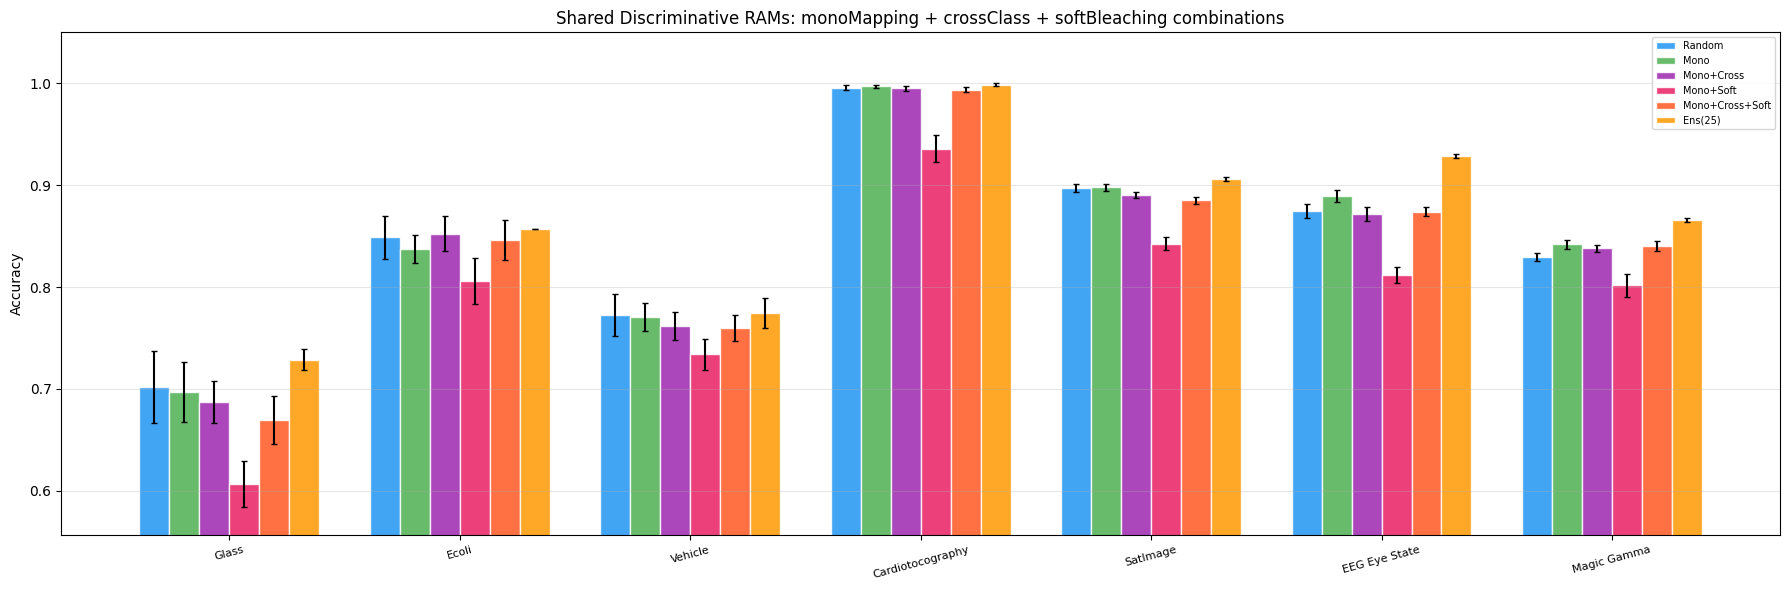


             Dataset        Random          Mono    Mono+Cross     Mono+Soft  Mono+Cross+Soft       Ens(25)
               Glass        0.7019        0.6972        0.6870        0.6065        0.6694        0.7287
               Ecoli        0.8488        0.8375        0.8524        0.8060        0.8464        0.8571
             Vehicle        0.7724        0.7705        0.7618        0.7337        0.7597        0.7748
    Cardiotocography        0.9959        0.9972        0.9953        0.9359        0.9939        0.9990
            SatImage        0.8974        0.8978        0.8902        0.8426        0.8853        0.9062
       EEG Eye State        0.8748        0.8892        0.8717        0.8117        0.8739        0.9288
         Magic Gamma        0.8297        0.8419        0.8381        0.8017        0.8405        0.8657

             Dataset          Mono    Mono+Cross     Mono+Soft  Mono+Cross+Soft       Ens(25)
               Glass       -0.0046       -0.0148       -0.095

In [12]:
# === 25.2 Shared Discriminative RAMs visualization ===
s25_methods = ['Random', 'Mono', 'Mono+Cross', 'Mono+Soft', 'Mono+Cross+Soft', 'Ens(25)']
s25_colors = ['#2196F3', '#4CAF50', '#9C27B0', '#E91E63', '#FF5722', '#FF9800']
s25_ds = list(datasets.keys())

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(s25_ds)); width = 0.13
for i, method in enumerate(s25_methods):
    means = [shared_results[(ds, method)][0] for ds in s25_ds]
    stds = [shared_results[(ds, method)][1] for ds in s25_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=s25_colors[i], edgecolor='white', capsize=2, alpha=0.85)
ax.set_xticks(x + 2.5 * width); ax.set_xticklabels(s25_ds, fontsize=8, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Shared Discriminative RAMs: monoMapping + crossClass + softBleaching combinations', fontsize=12)
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(shared_results[(ds, m)][0] for ds in s25_ds for m in s25_methods) - 0.05))
plt.tight_layout(); plt.show()

# Summary table
print(f"\n{'Dataset':>20s}", end='')
for m in s25_methods: print(f"  {m:>12s}", end='')
print()
for ds in s25_ds:
    print(f"{ds:>20s}", end='')
    for m in s25_methods:
        print(f"  {shared_results[(ds, m)][0]:>12.4f}", end='')
    print()

# Delta vs Random
print(f"\n{'Dataset':>20s}", end='')
for m in s25_methods[1:]: print(f"  {m:>12s}", end='')
print()
for ds in s25_ds:
    r = shared_results[(ds, 'Random')][0]
    print(f"{ds:>20s}", end='')
    for m in s25_methods[1:]:
        print(f"  {shared_results[(ds, m)][0]-r:>+12.4f}", end='')
    print()

## 26. Final Comprehensive Benchmark

All successful techniques tested on **all datasets** including image datasets (Fashion MNIST, MNIST, CIFAR-10, CIFAR-100). Uses Distributive thermometer throughout.

**Methods compared:**
- **Random**: Standard WiSARD (baseline)
- **v2**: RoundRobin MI supervised mapping (best single-model improvement)
- **Boost(10)**: Boosted WiSARD with 10 rounds
- **Ensemble(25)**: 25 random WiSARDs, majority vote
- **MonoMapping**: Shared mapping across classes

In [15]:
# === 26.1 Load all datasets including image datasets ===

FINAL_DATASET_CONFIG = {
    # (address_size, thermo_size, validation_size)
    "Glass":            (8,  32, 0.25),
    "Ecoli":            (10, 32, 0.25),
    "Vehicle":          (14, 32, 0.25),
    "Cardiotocography": (20, 32, 0.25),
    "SatImage":         (24, 32, 0.25),
    "EEG Eye State":    (28, 32, 0.25),
    "Magic Gamma":      (28, 32, 0.25),
    "Fashion MNIST":    (28, 2,  0.25),
    "MNIST":            (28, 2,  0.25),
    # "CIFAR-10":         (28, 4,  0.2),
    # "CIFAR-100":        (28, 4,  0.2),
}

final_datasets = {}

# Load OpenML datasets
openml_final = [
    ("Glass", 41), ("Ecoli", 39), ("Vehicle", 54),
    ("Cardiotocography", 1560), ("SatImage", 182),
    ("EEG Eye State", 1471), ("Magic Gamma", 1120),
    ("Fashion MNIST", 40996), ("MNIST", 554),
]
for name, did in openml_final:
    try:
        d = fetch_openml(data_id=did, as_frame=False, parser='auto')
        final_datasets[name] = (d.data.astype(float), d.target.astype(str))
        print(f"  Loaded {name}: {d.data.shape}")
    except Exception as e:
        print(f"  Skipping {name}: {e}")

# Load MNIST datasets
for name, openml_name in [("Fashion MNIST", "Fashion-MNIST"), ("MNIST", "mnist_784")]:
    try:
        d = fetch_openml(openml_name, version=1, as_frame=False, parser='auto')
        final_datasets[name] = (d.data.astype(float), d.target.astype(str))
        print(f"  Loaded {name}: {d.data.shape}")
    except Exception as e:
        print(f"  Skipping {name}: {e}")

# Load CIFAR datasets
# data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
# os.makedirs(data_dir, exist_ok=True)
# for name, loader in [("CIFAR-10", load_cifar10), ("CIFAR-100", load_cifar100)]:
#     try:
#         X, y = loader(data_dir)
#         final_datasets[name] = (X, y)
#         print(f"  Loaded {name}: {X.shape}")
#     except Exception as e:
#         print(f"  Skipping {name}: {e}")

print(f"\nTotal: {len(final_datasets)} datasets loaded")

  Loaded Glass: (214, 9)
  Loaded Ecoli: (336, 7)
  Loaded Vehicle: (846, 18)
  Loaded Cardiotocography: (2126, 35)
  Loaded SatImage: (6430, 36)
  Loaded EEG Eye State: (14980, 14)
  Loaded Magic Gamma: (19020, 10)
  Loaded Fashion MNIST: (70000, 784)
  Loaded MNIST: (70000, 784)
  Loaded Fashion MNIST: (70000, 784)
  Loaded MNIST: (70000, 784)

Total: 9 datasets loaded


In [16]:
# === 26.2 Final comprehensive benchmark ===
FINAL_N_RUNS = 5  # fewer runs for large datasets (speed)
FINAL_METHODS = ['Random', 'v2', 'MonoMapping', 'Boost(10)', 'Ensemble(25)']

final_results = {}
total_start = time.time()

for ds_name, (X_ds, y_ds) in final_datasets.items():
    addr_size, ts, val_size = FINAL_DATASET_CONFIG.get(ds_name, (28, 8, 0.2))
    n_feat = X_ds.shape[1]
    n_bits = n_feat * ts

    print(f"\n{'='*70}")
    print(f"{ds_name}: {X_ds.shape[0]} samples, {n_feat} feat, addr={addr_size}, thermo={ts}, bits={n_bits}")
    print(f"{'='*70}")

    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.25)

    t0 = time.time()
    thermo = create_and_fit_thermometer('Distributive', ts, X_tr,
        address_size=addr_size, y_train=y_tr, validation_size=val_size)
    X_tr_bin = binarize_dataset(X_tr, thermo)
    X_te_bin = binarize_dataset(X_te, thermo)
    print(f"  Binarized in {time.time()-t0:.1f}s")

    ds_train = wp.DataSet(X_tr_bin, y_tr.tolist())
    ds_test = wp.DataSet(X_te_bin)

    # Random baseline
    t0 = time.time()
    accs = []
    for run in range(FINAL_N_RUNS):
        w = wp.Wisard(addr_size); w.train(ds_train)
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    final_results[(ds_name, 'Random')] = (np.mean(accs), np.std(accs))
    print(f"  Random:       {np.mean(accs):.4f} +/- {np.std(accs):.4f}  ({time.time()-t0:.1f}s)")

    # v2 mapping
    t0 = time.time()
    v2_map = compute_supervised_mapping_v2(X_tr_bin, y_tr.tolist(), addr_size)
    w = wp.Wisard(addr_size, mapping=v2_map); w.train(ds_train)
    acc_v2 = compute_accuracy(w.classify(ds_test), y_te)
    final_results[(ds_name, 'v2')] = (acc_v2, 0.0)
    print(f"  v2:           {acc_v2:.4f}              ({time.time()-t0:.1f}s)")

    # MonoMapping
    t0 = time.time()
    accs = []
    for run in range(FINAL_N_RUNS):
        w = wp.Wisard(addr_size, monoMapping=True); w.train(ds_train)
        accs.append(compute_accuracy(w.classify(ds_test), y_te))
    final_results[(ds_name, 'MonoMapping')] = (np.mean(accs), np.std(accs))
    print(f"  MonoMapping:  {np.mean(accs):.4f} +/- {np.std(accs):.4f}  ({time.time()-t0:.1f}s)")

    # Boosted(10)
    t0 = time.time()
    accs = []
    for run in range(FINAL_N_RUNS):
        wisards = boosted_wisard_train(X_tr_bin, y_tr.tolist(), addr_size, 10)
        preds = boosted_classify(wisards, ds_test)
        accs.append(compute_accuracy(preds, y_te))
    final_results[(ds_name, 'Boost(10)')] = (np.mean(accs), np.std(accs))
    print(f"  Boost(10):    {np.mean(accs):.4f} +/- {np.std(accs):.4f}  ({time.time()-t0:.1f}s)")

    # Ensemble(25)
    t0 = time.time()
    accs = []
    for run in range(FINAL_N_RUNS):
        ws = [wp.Wisard(addr_size) for _ in range(25)]
        for w in ws: w.train(ds_train)
        accs.append(compute_accuracy(ensemble_classify(ws, ds_test), y_te))
    final_results[(ds_name, 'Ensemble(25)')] = (np.mean(accs), np.std(accs))
    print(f"  Ensemble(25): {np.mean(accs):.4f} +/- {np.std(accs):.4f}  ({time.time()-t0:.1f}s)")

total_elapsed = time.time() - total_start
minutes, seconds = divmod(total_elapsed, 60)
print(f"\nDone! Total time: {int(minutes)}m {seconds:.1f}s")


Glass: 214 samples, 9 feat, addr=8, thermo=32, bits=288
  Binarized in 0.0s
  Random:       0.7148 +/- 0.0148  (0.0s)
  v2:           0.6852              (0.0s)
  MonoMapping:  0.7296 +/- 0.0381  (0.0s)
  Boost(10):    0.7185 +/- 0.0319  (0.1s)
  Ensemble(25): 0.6963 +/- 0.0091  (0.1s)

Ecoli: 336 samples, 7 feat, addr=10, thermo=32, bits=224
  Binarized in 0.0s
  Random:       0.8429 +/- 0.0356  (0.0s)
  v2:           0.8214              (0.0s)
  MonoMapping:  0.8643 +/- 0.0095  (0.0s)
  Boost(10):    0.8476 +/- 0.0089  (0.2s)
  Ensemble(25): 0.8548 +/- 0.0048  (0.1s)

Vehicle: 846 samples, 18 feat, addr=14, thermo=32, bits=576
  Binarized in 0.0s
  Random:       0.7377 +/- 0.0165  (0.0s)
  v2:           0.7736              (0.1s)
  MonoMapping:  0.7566 +/- 0.0162  (0.0s)
  Boost(10):    0.7481 +/- 0.0135  (0.2s)
  Ensemble(25): 0.7726 +/- 0.0105  (0.3s)

Cardiotocography: 2126 samples, 35 feat, addr=20, thermo=32, bits=1120
  Binarized in 0.0s
  Random:       0.9805 +/- 0.0015  (0.0

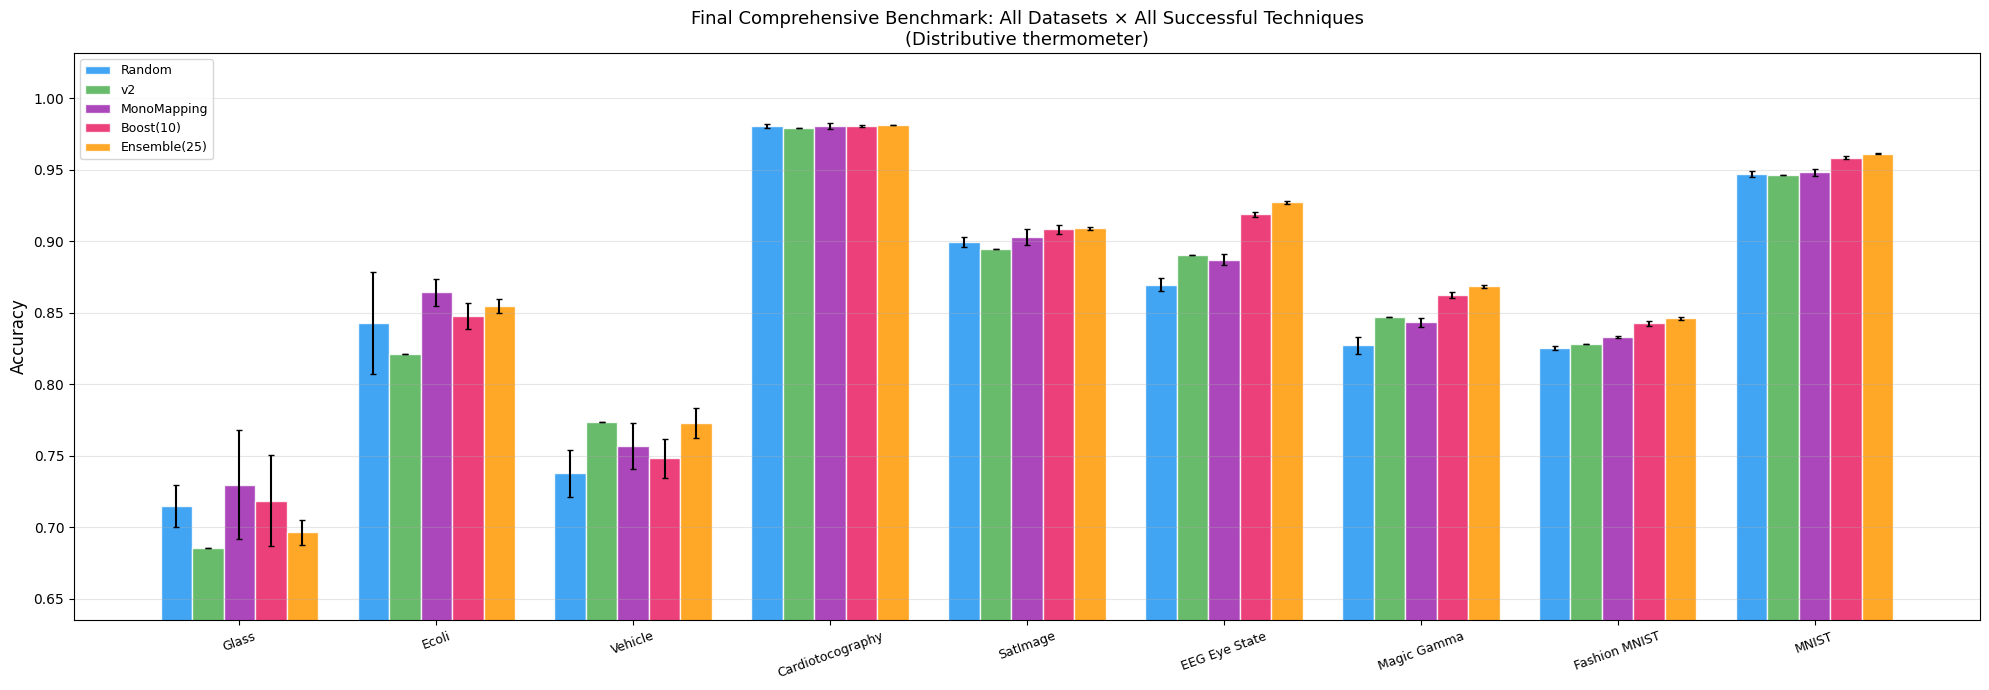

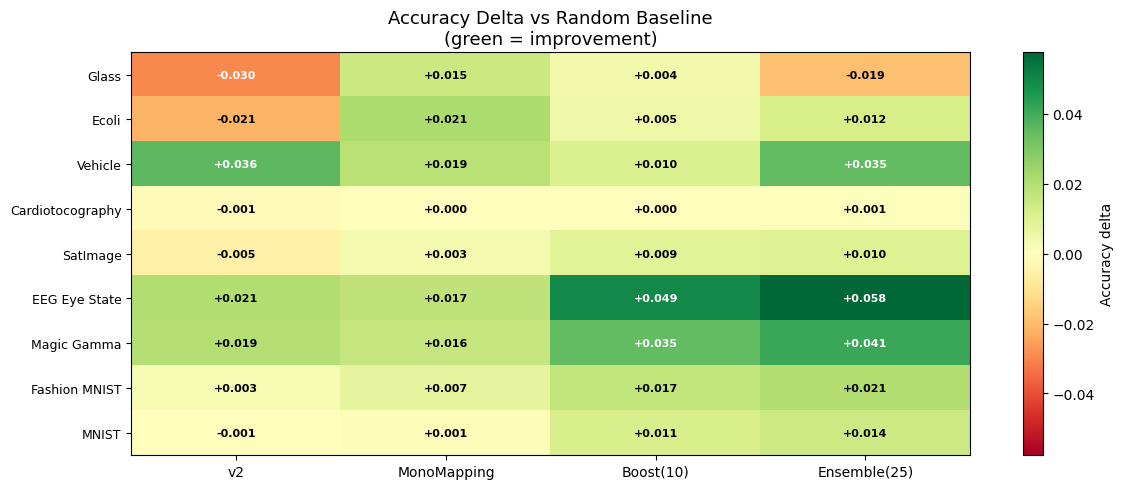


             Dataset  Samples   Feat        Random            v2   MonoMapping     Boost(10)  Ensemble(25)
               Glass      214      9        0.7148        0.6852        0.7296        0.7185        0.6963
               Ecoli      336      7        0.8429        0.8214        0.8643        0.8476        0.8548
             Vehicle      846     18        0.7377        0.7736        0.7566        0.7481        0.7726
    Cardiotocography     2126     35        0.9805        0.9793        0.9805        0.9805        0.9812
            SatImage     6430     36        0.8993        0.8943        0.9026        0.9082        0.9090
       EEG Eye State    14980     14        0.8696        0.8903        0.8871        0.9188        0.9273
         Magic Gamma    19020     10        0.8272        0.8467        0.8432        0.8622        0.8683
       Fashion MNIST    70000    784        0.8255        0.8281        0.8329        0.8425        0.8460
               MNIST    70000    784

In [18]:
# === 26.3 Final results visualization ===
final_ds = list(final_datasets.keys())

# Bar chart
fig, ax = plt.subplots(figsize=(20, 7))
x = np.arange(len(final_ds))
width = 0.16
f_colors = ['#2196F3', '#4CAF50', '#9C27B0', '#E91E63', '#FF9800']

for i, method in enumerate(FINAL_METHODS):
    means = [final_results[(ds, method)][0] for ds in final_ds]
    stds = [final_results[(ds, method)][1] for ds in final_ds]
    ax.bar(x + i * width, means, width, yerr=stds, label=method,
           color=f_colors[i], edgecolor='white', capsize=2, alpha=0.85)

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(final_ds, fontsize=9, rotation=20)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Final Comprehensive Benchmark: All Datasets × All Successful Techniques\n(Distributive thermometer)', fontsize=13)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=max(0, min(final_results[(ds, m)][0] for ds in final_ds for m in FINAL_METHODS) - 0.05))
plt.tight_layout(); plt.show()

# Delta heatmap vs Random
delta_data = np.zeros((len(final_ds), len(FINAL_METHODS) - 1))
for i, ds_name in enumerate(final_ds):
    baseline = final_results[(ds_name, 'Random')][0]
    for j, method in enumerate(FINAL_METHODS[1:]):
        delta_data[i, j] = final_results[(ds_name, method)][0] - baseline

fig, ax = plt.subplots(figsize=(12, max(5, len(final_ds) * 0.5)))
vmax = max(abs(delta_data.min()), abs(delta_data.max()))
if vmax == 0: vmax = 0.01
im = ax.imshow(delta_data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
for i in range(len(final_ds)):
    for j in range(len(FINAL_METHODS) - 1):
        val = delta_data[i, j]
        color = 'white' if abs(val) > vmax * 0.4 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')
ax.set_xticks(range(len(FINAL_METHODS) - 1))
ax.set_xticklabels(FINAL_METHODS[1:], fontsize=10)
ax.set_yticks(range(len(final_ds)))
ax.set_yticklabels(final_ds, fontsize=9)
ax.set_title('Accuracy Delta vs Random Baseline\n(green = improvement)', fontsize=13)
plt.colorbar(im, ax=ax, label='Accuracy delta')
plt.tight_layout(); plt.show()

# Summary table
print(f"\n{'Dataset':>20s}  {'Samples':>7s}  {'Feat':>5s}", end='')
for m in FINAL_METHODS: print(f"  {m:>12s}", end='')
print()
for ds in final_ds:
    n_s, n_f = final_datasets[ds][0].shape
    print(f"{ds:>20s}  {n_s:>7d}  {n_f:>5d}", end='')
    for m in FINAL_METHODS:
        print(f"  {final_results[(ds, m)][0]:>12.4f}", end='')
    print()